In [1]:
# ==============================================================================
# CELL 1: PROJECT BOOTSTRAP - CODESPACE READY
# ==============================================================================
# Project: Pienza
# Logic: Zero-Configuration Environment Detection
# ==============================================================================

import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

# 1. PROTOCOLO DE HIGIENE VISUAL
# ------------------------------------------------------------------------------
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
pd.options.mode.chained_assignment = None  # Evita ruido en manipulaciones de DataFrames

print("✅ Visual Hygiene Protocol Active: Warnings Silenced.")

# 2. CONFIGURACIÓN DE RUTAS (SNAKE_CASE CANON)
# ------------------------------------------------------------------------------
# Detectamos si el entorno es Codespaces o Colab
if 'CODESPACES' in os.environ:
    BASE_PATH = "/workspaces/pienza"
    DB_PATH = os.path.join(BASE_PATH, "data/pienza.db")
    ENV_LABEL = "🌐 GitHub Codespaces"
else:
    # Fallback para compatibilidad con Google Drive/Colab
    print("⏳ Mounting Google Drive for Colab fallback...")
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        DB_PATH = '/content/drive/MyDrive/_Pienza/Assets/Database/pienza.db'
        ENV_LABEL = "☁️ Google Colab"
    except ImportError:
        DB_PATH = "data/pienza.db" # Local fallback
        ENV_LABEL = "💻 Local Environment"

# 3. ESTABLECER CONEXIÓN A LA BASE DE DATOS
# ------------------------------------------------------------------------------
if not os.path.exists(DB_PATH):
    print(f"🔴 CRITICAL ERROR: Database file not found at {DB_PATH}")
    print("   Check if the file 'pienza.db' is inside /workspaces/pienza/data/")
else:
    try:
        db_engine = create_engine(f'sqlite:///{DB_PATH}')
        print(f"✅ Connection Established: {DB_PATH}")
    except Exception as e:
        print(f"🔴 ERROR: Failed to create database engine. {e}")

# 4. FINALIZACIÓN
# ------------------------------------------------------------------------------
print(f"🚀 Environment: {ENV_LABEL}")
print("--- Analytical environment is LIVE. Ready for Phase 3 EDA. ---")

✅ Visual Hygiene Protocol Active: Warnings Silenced.
✅ Connection Established: /workspaces/pienza/data/pienza.db
🚀 Environment: 🌐 GitHub Codespaces
--- Analytical environment is LIVE. Ready for Phase 3 EDA. ---


In [3]:
# ==============================================================================
# CELL 2: LOAD CORE DATA & NUMERICAL RECONNAISSANCE
# ==============================================================================
# Author v2: _Pienza, ex_machina
# Purpose: This cell loads the main 'offers' fact table from opus.db and
#          performs the initial high-level statistical summary of all
#          numerical features to identify scale, skew, and potential anomalies.
# ==============================================================================

# ------------------------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------------------------
print("⏳ Loading 'offers' table into pandas DataFrame...")
try:
    # Use the db_engine created in CELL 1 to execute a SQL query
    offers_df = pd.read_sql('SELECT * FROM offers', db_engine)
    print(f"✅ Successfully loaded {len(offers_df)} records from the 'offers' table.")
    print(f"   DataFrame shape: {offers_df.shape}")
except Exception as e:
    print(f"🔴 ERROR: Failed to load data from the 'offers' table. Details: {e}")
    raise

# ------------------------------------------------------------------------------
# 2. GENERATE GLOBAL STATISTICAL SUMMARY
# ------------------------------------------------------------------------------
print("\n--- Generating High-Dimensional Statistical Summary ---")
# Using .T to transpose the output for better readability
numerical_summary = offers_df.describe().T

# Display the full summary
# Using a display() call for better formatting in Colab
display(numerical_summary)

# ------------------------------------------------------------------------------
# 3. INITIAL ARCHITECT'S ANALYSIS (GUIDED INSIGHTS)
# ------------------------------------------------------------------------------
print("\n--- Initial Analysis & Sanity Checks ---")
# We will use the generated summary to perform some initial checks.

# Check for missing values (count < total rows)
missing_values_check = numerical_summary[numerical_summary['count'] < len(offers_df)]
if not missing_values_check.empty:
    print("⚠️ WARNING: Missing values detected in the following numerical columns:")
    display(missing_values_check[['count']])
else:
    print("✅ No missing values detected in numerical columns.")

# Sanity check on key metrics
# Example: Check if any core financial or time metrics have nonsensical minimums (e.g., negative)
min_fare = numerical_summary.loc['upfront_fare', 'min']
min_time = numerical_summary.loc['est_trip_time_sec', 'min']

print(f"\nSanity Check (Minimums):")
print(f"  - Minimum upfront_fare: {min_fare}")
print(f"  - Minimum est_trip_time_sec: {min_time}")

if min_fare < 0 or min_time < 0:
    print("🔴 URGENT: Negative values detected in key metrics. Investigation required.")
else:
    print("✅ Minimum values appear sane.")

⏳ Loading 'offers' table into pandas DataFrame...
✅ Successfully loaded 4765 records from the 'offers' table.
   DataFrame shape: (4765, 50)

--- Generating High-Dimensional Statistical Summary ---


,count,mean,std,min,25%,50%,75%,max
upfront_fare,4765.0,131.162246,78.901284,27.460000,74.820000,117.270000,167.400000,1499.340000
time_to_pickup_sec,4750.0,561.107368,315.169430,0.000000,360.000000,480.000000,720.000000,1800.000000
dist_to_pickup_km,4747.0,2.994944,2.306044,0.000000,1.400000,2.400000,3.900000,18.000000
est_trip_time_sec,4749.0,1738.736576,1118.956859,60.000000,900.000000,1500.000000,2340.000000,13980.000000
est_trip_dist_km,4745.0,10.580295,9.480231,0.000000,4.200000,8.200000,14.500000,230.000000
pickup_lat,4762.0,19.408617,0.033219,19.199459,19.385071,19.415066,19.431873,19.688118
pickup_lon,4762.0,-99.219700,0.042770,-99.479912,-99.259387,-99.213444,-99.180883,-98.887147
dropoff_lat,4760.0,19.414349,0.064775,19.129192,19.377374,19.415461,19.436076,20.674675
dropoff_lon,4760.0,-99.204306,0.066762,-100.454759,-99.253711,-99.204832,-99.172486,-98.719171
is_surge,4765.0,0.316684,0.465232,0.000000,0.000000,0.000000,1.000000,1.000000



--- Initial Analysis & Sanity Checks ---
⚠️ WARNING: Missing values detected in the following numerical columns:


,count
time_to_pickup_sec,4750.0
dist_to_pickup_km,4747.0
est_trip_time_sec,4749.0
est_trip_dist_km,4745.0
pickup_lat,4762.0
pickup_lon,4762.0
dropoff_lat,4760.0
dropoff_lon,4760.0
surge_amount,1509.0
turbo_plus_amount,1336.0



Sanity Check (Minimums):
  - Minimum upfront_fare: 27.46
  - Minimum est_trip_time_sec: 60.0
✅ Minimum values appear sane.


In [4]:
# ==============================================================================
# CELL 3: FORENSIC ANALYSIS - The "Missing Zeroes" Investigation
# ==============================================================================
# Author v2: _Pienza, ex_machina
# Purpose: To perform a deep-dive investigation into the 'time_to_pickup_sec'
#          column to validate the Architect's hypothesis that zero-values
#          may have been incorrectly converted to nulls.
# ==============================================================================

print("--- Forensic Analysis of 'time_to_pickup_sec' ---")

# Isolate the series for cleaner analysis
ttp_series = offers_df['time_to_pickup_sec']

# ------------------------------------------------------------------------------
# 1. NULL VALUE COUNT
# ------------------------------------------------------------------------------
# Let's count the number of nulls directly.
null_count = ttp_series.isnull().sum()
print(f"Direct count of NULL values: {null_count}")

# ------------------------------------------------------------------------------
# 2. VALUE DISTRIBUTION (INCLUDING POTENTIAL ZEROES)
# ------------------------------------------------------------------------------
# Use value_counts() which can show us if zeroes exist.
# We'll look at the smallest values in the dataset.
print("\nSmallest unique values in 'time_to_pickup_sec':")
# dropna=False is critical to see NaN counts if they exist
smallest_values = ttp_series.value_counts(dropna=False).sort_index().head(10)
display(smallest_values)

# ------------------------------------------------------------------------------
# 3. THE SMOKING GUN TEST
# ------------------------------------------------------------------------------
# Let's explicitly query for offers where the TTP is exactly zero or null.
zero_ttp_count = len(offers_df[offers_df['time_to_pickup_sec'] == 0])
less_than_one_ttp_count = len(offers_df[offers_df['time_to_pickup_sec'] < 1])

print(f"\n--- The Smoking Gun ---")
print(f"Number of offers with TTP == 0: {zero_ttp_count}")
print(f"Number of offers with TTP < 1: {less_than_one_ttp_count}")


# ------------------------------------------------------------------------------
# 4. ARCHITECT'S VERDICT
# ------------------------------------------------------------------------------
if null_count > 0 and zero_ttp_count == 0:
    print("\n🔴 VERDICT: HYPOTHESIS CONFIRMED. Zeroes were likely lost during ETL.")
    print("   The presence of NULLs and the complete absence of 0s is highly suspicious.")
elif null_count == 0 and zero_ttp_count > 0:
    print("\n✅ VERDICT: HYPOTHESIS REFUTED. Zeroes are present and accounted for.")
    print("   The data appears to be intact.")
elif null_count > 0 and zero_ttp_count > 0:
    print("\n⚠️ VERDICT: DATA IS MIXED. Both Zeroes and NULLs are present.")
    print("   This may be correct, but warrants a review of the source data.")
else: # null_count == 0 and zero_ttp_count == 0
    print("\n✅ VERDICT: HYPOTHESIS REFUTED. No NULLs and no Zeroes found.")
    print("   This implies that there were no 'instant' pickups in the dataset.")

--- Forensic Analysis of 'time_to_pickup_sec' ---
Direct count of NULL values: 15

Smallest unique values in 'time_to_pickup_sec':


time_to_pickup_sec
0.0       28
60.0      48
120.0    170
180.0    236
240.0    297
300.0    376
360.0    453
420.0    457
480.0    382
540.0    330
Name: count, dtype: int64


--- The Smoking Gun ---
Number of offers with TTP == 0: 28
Number of offers with TTP < 1: 28

⚠️ VERDICT: DATA IS MIXED. Both Zeroes and NULLs are present.
   This may be correct, but warrants a review of the source data.


In [5]:
# ==============================================================================
# CELL 1.1: ARCHITECTING THE ANALYTICAL LENSES
# ==============================================================================
# Author v2: _Pienza, ex_machina
# Purpose: Implements the "Doctrine of Dual Fidelity" by creating two distinct
#          DataFrames for analysis: one for decision-making (complete offers)
#          and one for mission outcomes (all completed trips).
# ==============================================================================

# ------------------------------------------------------------------------------
# 1. LOAD THE "GROUND TRUTH" ASSETS
# ------------------------------------------------------------------------------
# Load the full, unfiltered offers table (our "source of all truth")
offers_df = pd.read_sql('SELECT * FROM offers', db_engine)
print(f"Loaded {len(offers_df)} total records from 'offers' table.")

# Load the mission outcomes view, which already contains the 17 completed ghosts
mission_dossier_df = pd.read_sql('SELECT * FROM v_mission_dossier', db_engine)
print(f"Loaded {len(mission_dossier_df)} completed missions from 'v_mission_dossier'.")
print("-" * 50)


# ------------------------------------------------------------------------------
# 2. FORGE THE "DECISION-MAKING" LENS
# ------------------------------------------------------------------------------
# This lens is for analyzing the 'why' of a decision. We filter out the
# imputed offers because they lack the necessary predictive features.

offers_for_decision_analysis_df = offers_df[offers_df['is_imputed'] == False].copy()

print("Forged 'Decision-Making' Lens:")
print(f"  -> Contains {len(offers_for_decision_analysis_df)} records (complete offers only).")
print(f"  -> Shape: {offers_for_decision_analysis_df.shape}")


# ------------------------------------------------------------------------------
# 3. CONFIRM THE "MISSION OUTCOME" LENS
# ------------------------------------------------------------------------------
# This lens is for analyzing the results of what happened. It is our v_mission_dossier.
# We will rename it for clarity and consistency.

missions_for_outcome_analysis_df = mission_dossier_df.copy()

print("\nConfirmed 'Mission Outcome' Lens:")
print(f"  -> Contains {len(missions_for_outcome_analysis_df)} records (all completed missions).")
print(f"  -> Shape: {missions_for_outcome_analysis_df.shape}")

print("\n--- Analytical lenses are ready. Proceed with EDA. ---")

Loaded 4765 total records from 'offers' table.
Loaded 259 completed missions from 'v_mission_dossier'.
--------------------------------------------------
Forged 'Decision-Making' Lens:
  -> Contains 4746 records (complete offers only).
  -> Shape: (4746, 50)

Confirmed 'Mission Outcome' Lens:
  -> Contains 259 records (all completed missions).
  -> Shape: (259, 12)

--- Analytical lenses are ready. Proceed with EDA. ---


In [7]:
# ==============================================================================
# CELL 3: CATEGORICAL FEATURE ANALYSIS (THE CENSUS)
# ==============================================================================
# Author v2: _Pienza, ex_machina
# Purpose: To load the human-readable dimension tables, join them to the
#          pure offers_df, and analyze the frequency distribution of key
#          categorical variables (Target, Product, Reason).
# ==============================================================================

print("--- Initiating Categorical Census ---")

# 1. LOAD DIMENSION TABLES & CREATE "MVV" (Minimum Viable View)
# ------------------------------------------------------------------------------
# We need the text descriptions, not just the IDs.
try:
    reason_df = pd.read_sql('SELECT * FROM reason_primary', db_engine)
    action_df = pd.read_sql('SELECT * FROM offer_action', db_engine)
    product_df = pd.read_sql('SELECT * FROM product_category', db_engine)

    # Merge into our clean offers_df
    mvv_df = offers_df.merge(reason_df, left_on='reason_primary_fk', right_on='reason_primary_id', how='left')
    mvv_df = mvv_df.merge(action_df, left_on='offer_action_fk', right_on='offer_action_id', how='left')
    mvv_df = mvv_df.merge(product_df, left_on='product_category_fk', right_on='product_category_id', how='left')

    print("✅ Minimum Viable View (MVV) constructed in memory.")
except Exception as e:
    print(f"🔴 ERROR joining dimension tables: {e}")
    raise

# 2. THE CENSUS: FREQUENCY DISTRIBUTIONS
# ------------------------------------------------------------------------------
categorical_targets = [
    'offer_action_description',   # The Target (Accept/Reject)
    'category_name',              # The Product (UberX, Comfort...)
    'reason_primary_description'  # The "Why" (For rejections)
]

for col in categorical_targets:
    print(f"\n📊 DISTRIBUTION: {col}")
    # Get counts and percentages
    counts = mvv_df[col].value_counts(dropna=False)
    percents = mvv_df[col].value_counts(normalize=True, dropna=False) * 100

    # Combine into a readable dataframe
    census = pd.DataFrame({'Count': counts, 'Percent (%)': percents})
    display(census)

print("\n--- CENSUS COMPLETE ---")

--- Initiating Categorical Census ---
✅ Minimum Viable View (MVV) constructed in memory.

📊 DISTRIBUTION: offer_action_description


,Count,Percent (%)
offer_action_description,,
reject,4419,92.73872
accepted,346,7.26128



📊 DISTRIBUTION: category_name


,Count,Percent (%)
category_name,,
uberx,3618,75.928646
comfort,818,17.166842
business_comfort,176,3.693599
envíos_uber,71,1.490031
black,39,0.818468
uber_planet,38,0.797482
uber_pet,5,0.104932



📊 DISTRIBUTION: reason_primary_description


,Count,Percent (%)
reason_primary_description,,
dropoff_non_operational,2366,49.653725
low_profitability,838,17.586569
long_pickup_time,366,7.681007
NaN,346,7.261280
expected_value_gamble,330,6.925498
dropoff_strategic_mismatch,275,5.771249
dropoff_proxy,239,5.015740
system_logic_failure,5,0.104932



--- CENSUS COMPLETE ---


⏳ Loading and processing data...


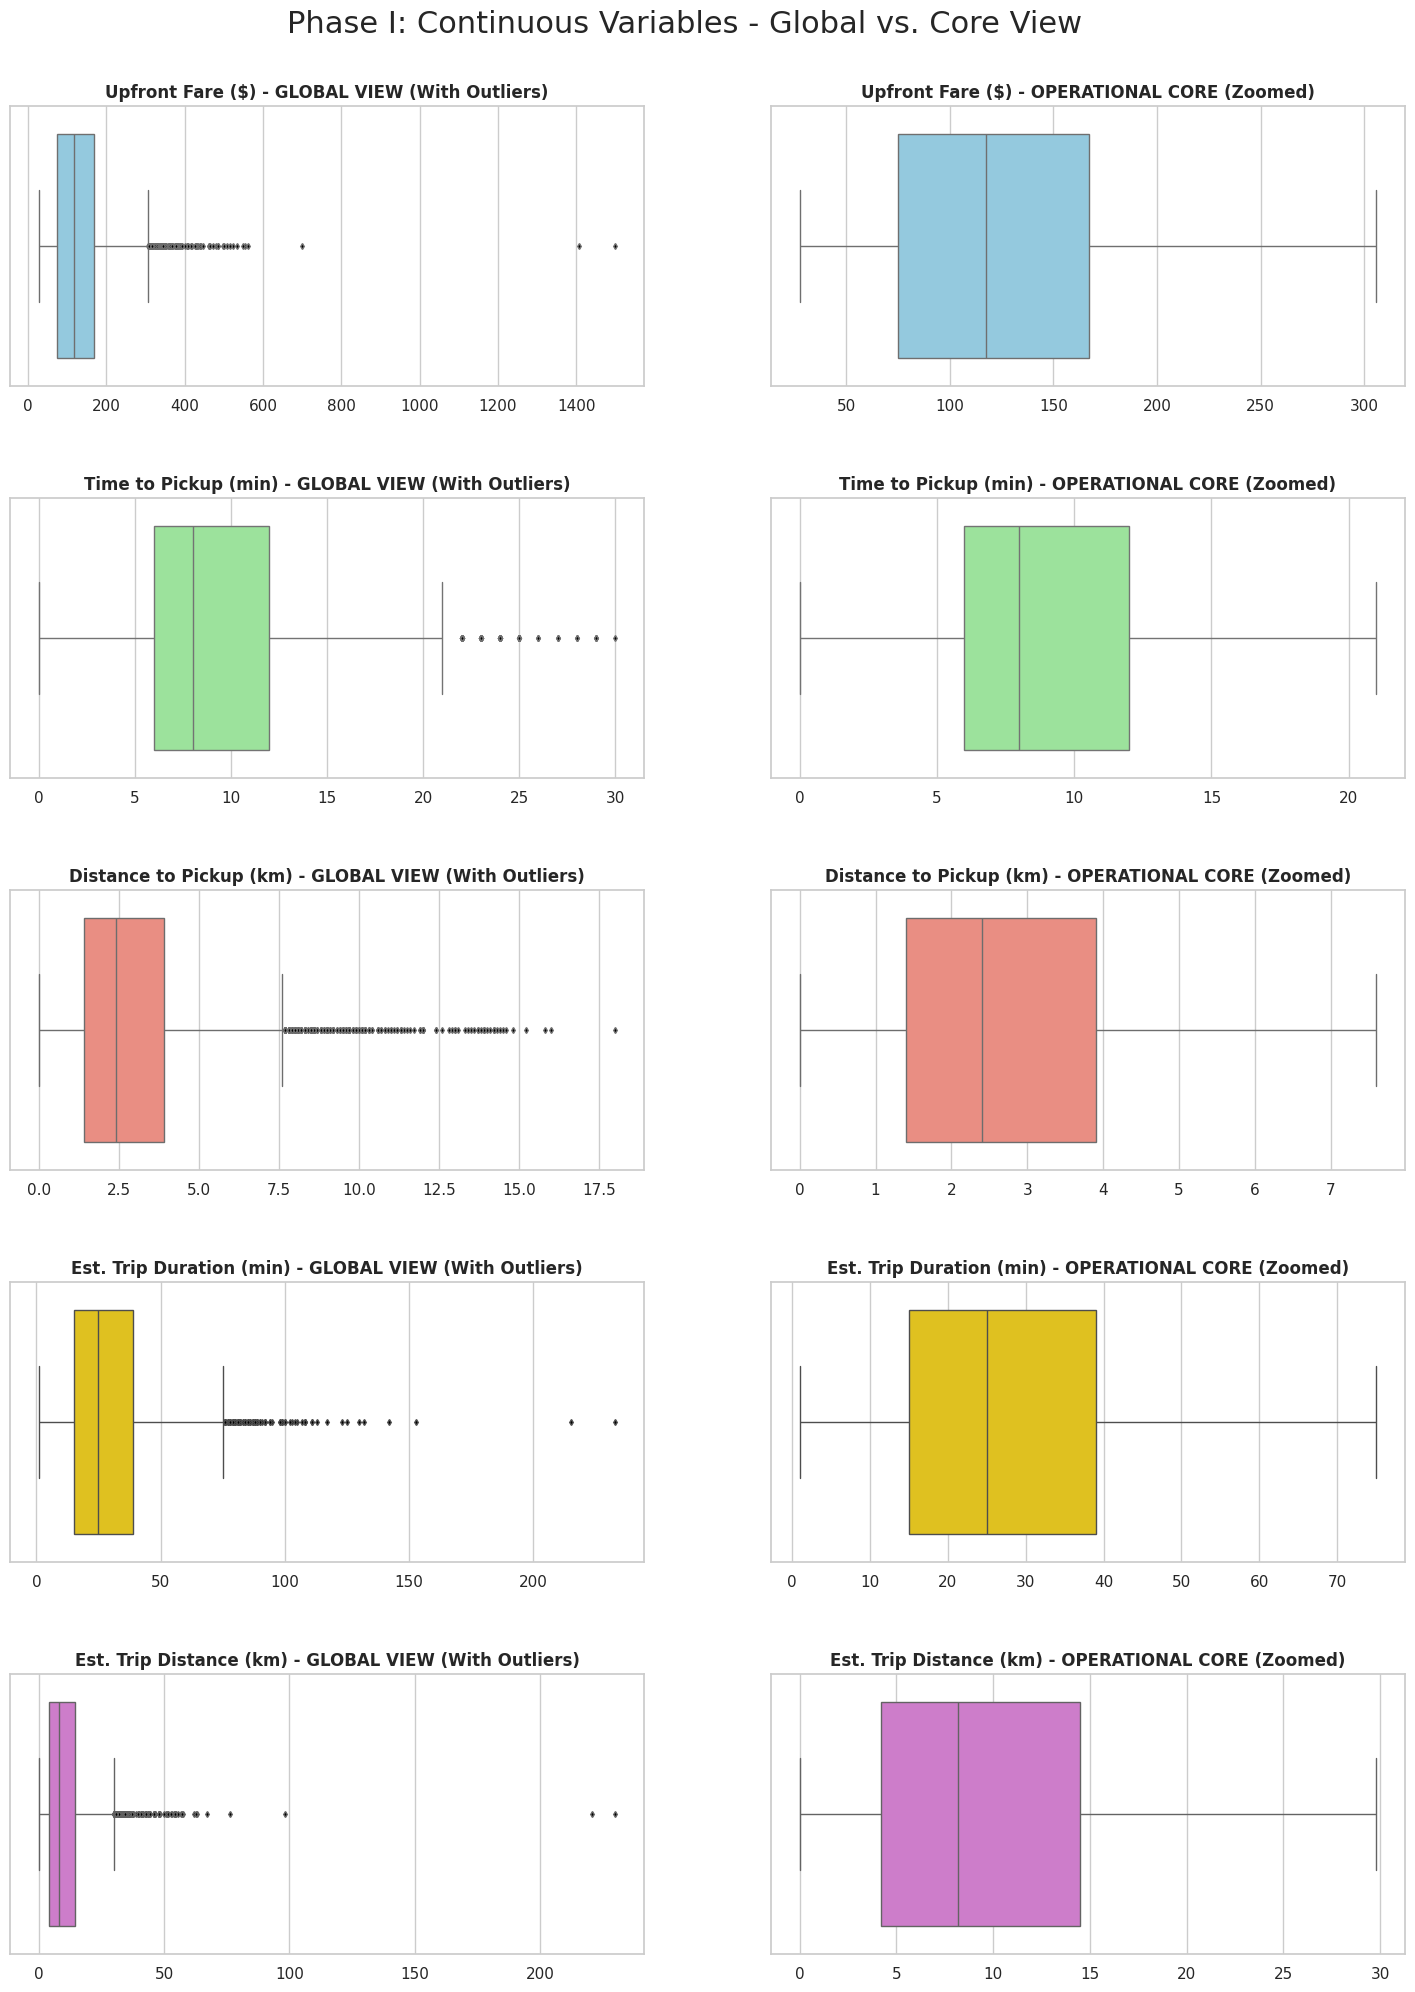


--- 📊 STATISTICAL PRECISION TABLE (THE QUARTILES) ---

--- 📊 STATISTICAL PRECISION TABLE (THE QUARTILES) ---


,Count,Min,Q1 (25%),Median (Q2),Q3 (75%),Max,IQR,Mean,Std Dev
upfront_fare,4765.0,27.46,74.82,117.27,167.4,1499.34,92.58,131.162246,78.901284
time_to_pickup_min,4750.0,0.00,6.00,8.00,12.0,30.00,6.00,9.351789,5.252824
dist_to_pickup_km,4747.0,0.00,1.40,2.40,3.9,18.00,2.50,2.994944,2.306044
est_trip_time_min,4749.0,1.00,15.00,25.00,39.0,233.00,24.00,28.978943,18.649281
est_trip_dist_km,4745.0,0.00,4.20,8.20,14.5,230.00,10.30,10.580295,9.480231


In [9]:
# ==============================================================================
# CELL 2 (REVISED v2): CONTINUOUS VARIABLE DEEP DIVE (SIDE-BY-SIDE)
# ==============================================================================
# Purpose: Comparative analysis of continuous variables.
#          Left: Full Distribution (with Outliers).
#          Right: Core Distribution (Zoomed, No Outliers).
#          Bottom: Precision Statistical Table.
# ==============================================================================

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. LOAD DATA & CONVERT UNITS
print("⏳ Loading and processing data...")
query = """
SELECT
    upfront_fare,
    time_to_pickup_sec,
    dist_to_pickup_km,
    est_trip_time_sec,
    est_trip_dist_km
FROM v_offers_human
"""
df_eda = pd.read_sql(query, db_engine)

# Convert Seconds to Minutes for Cognitive Ease
df_eda['time_to_pickup_min'] = df_eda['time_to_pickup_sec'] / 60
df_eda['est_trip_time_min'] = df_eda['est_trip_time_sec'] / 60

# Define the exact columns to analyze
target_cols = [
    ('upfront_fare', 'Upfront Fare ($)', 'skyblue'),
    ('time_to_pickup_min', 'Time to Pickup (min)', 'lightgreen'),
    ('dist_to_pickup_km', 'Distance to Pickup (km)', 'salmon'),
    ('est_trip_time_min', 'Est. Trip Duration (min)', 'gold'),
    ('est_trip_dist_km', 'Est. Trip Distance (km)', 'orchid')
]

# 2. GENERATE PLOTS (5 Rows x 2 Cols)
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(len(target_cols), 2, figsize=(18, 24))
plt.subplots_adjust(hspace=0.4, wspace=0.2)
fig.suptitle('Phase I: Continuous Variables - Global vs. Core View', fontsize=22, y=0.92)

for i, (col, title, color) in enumerate(target_cols):
    # --- LEFT PLOT: GLOBAL VIEW (With Outliers) ---
    ax_left = axes[i, 0]
    sns.boxplot(x=df_eda[col], ax=ax_left, color=color,
                flierprops={"marker": "d", "markerfacecolor": "black", "markersize": 3})
    ax_left.set_title(f"{title} - GLOBAL VIEW (With Outliers)", fontweight='bold')
    ax_left.set_xlabel('')

    # --- RIGHT PLOT: CORE VIEW (No Outliers / Zoomed) ---
    ax_right = axes[i, 1]
    sns.boxplot(x=df_eda[col], ax=ax_right, color=color, showfliers=False)
    ax_right.set_title(f"{title} - OPERATIONAL CORE (Zoomed)", fontweight='bold')
    ax_right.set_xlabel('')

plt.show()

# 3. GENERATE PRECISION STATISTICS TABLE
print("\n--- 📊 STATISTICAL PRECISION TABLE (THE QUARTILES) ---")

# Calculate basic describe stats
stats = df_eda[[col for col, _, _ in target_cols]].describe(percentiles=[0.25, 0.5, 0.75]).T

# Calculate IQR (Interquartile Range)
stats['IQR'] = stats['75%'] - stats['25%']

# Format for readability
columns_order = ['count', 'min', '25%', '50%', '75%', 'max', 'IQR', 'mean', 'std']
final_table = stats[columns_order]
final_table.columns = ['Count', 'Min', 'Q1 (25%)', 'Median (Q2)', 'Q3 (75%)', 'Max', 'IQR', 'Mean', 'Std Dev']

# 3. GENERATE PRECISION STATISTICS TABLE
print("\n--- 📊 STATISTICAL PRECISION TABLE (THE QUARTILES) ---")

# Calcular estadísticas base
stats = df_eda[[col for col, _, _ in target_cols]].describe(percentiles=[0.25, 0.5, 0.75]).T

# Calcular IQR (Interquartile Range)
stats['IQR'] = stats['75%'] - stats['25%']

# Formatear para legibilidad
columns_order = ['count', 'min', '25%', '50%', '75%', 'max', 'IQR', 'mean', 'std']
final_table = stats[columns_order]
final_table.columns = ['Count', 'Min', 'Q1 (25%)', 'Median (Q2)', 'Q3 (75%)', 'Max', 'IQR', 'Mean', 'Std Dev']

# --- CODESPACE OPTIMIZED DISPLAY ---
# En VS Code, simplemente llamar al DataFrame o usar display() 
# habilita automáticamente el visor interactivo.
display(final_table)

⏳ Reloading timestamps...


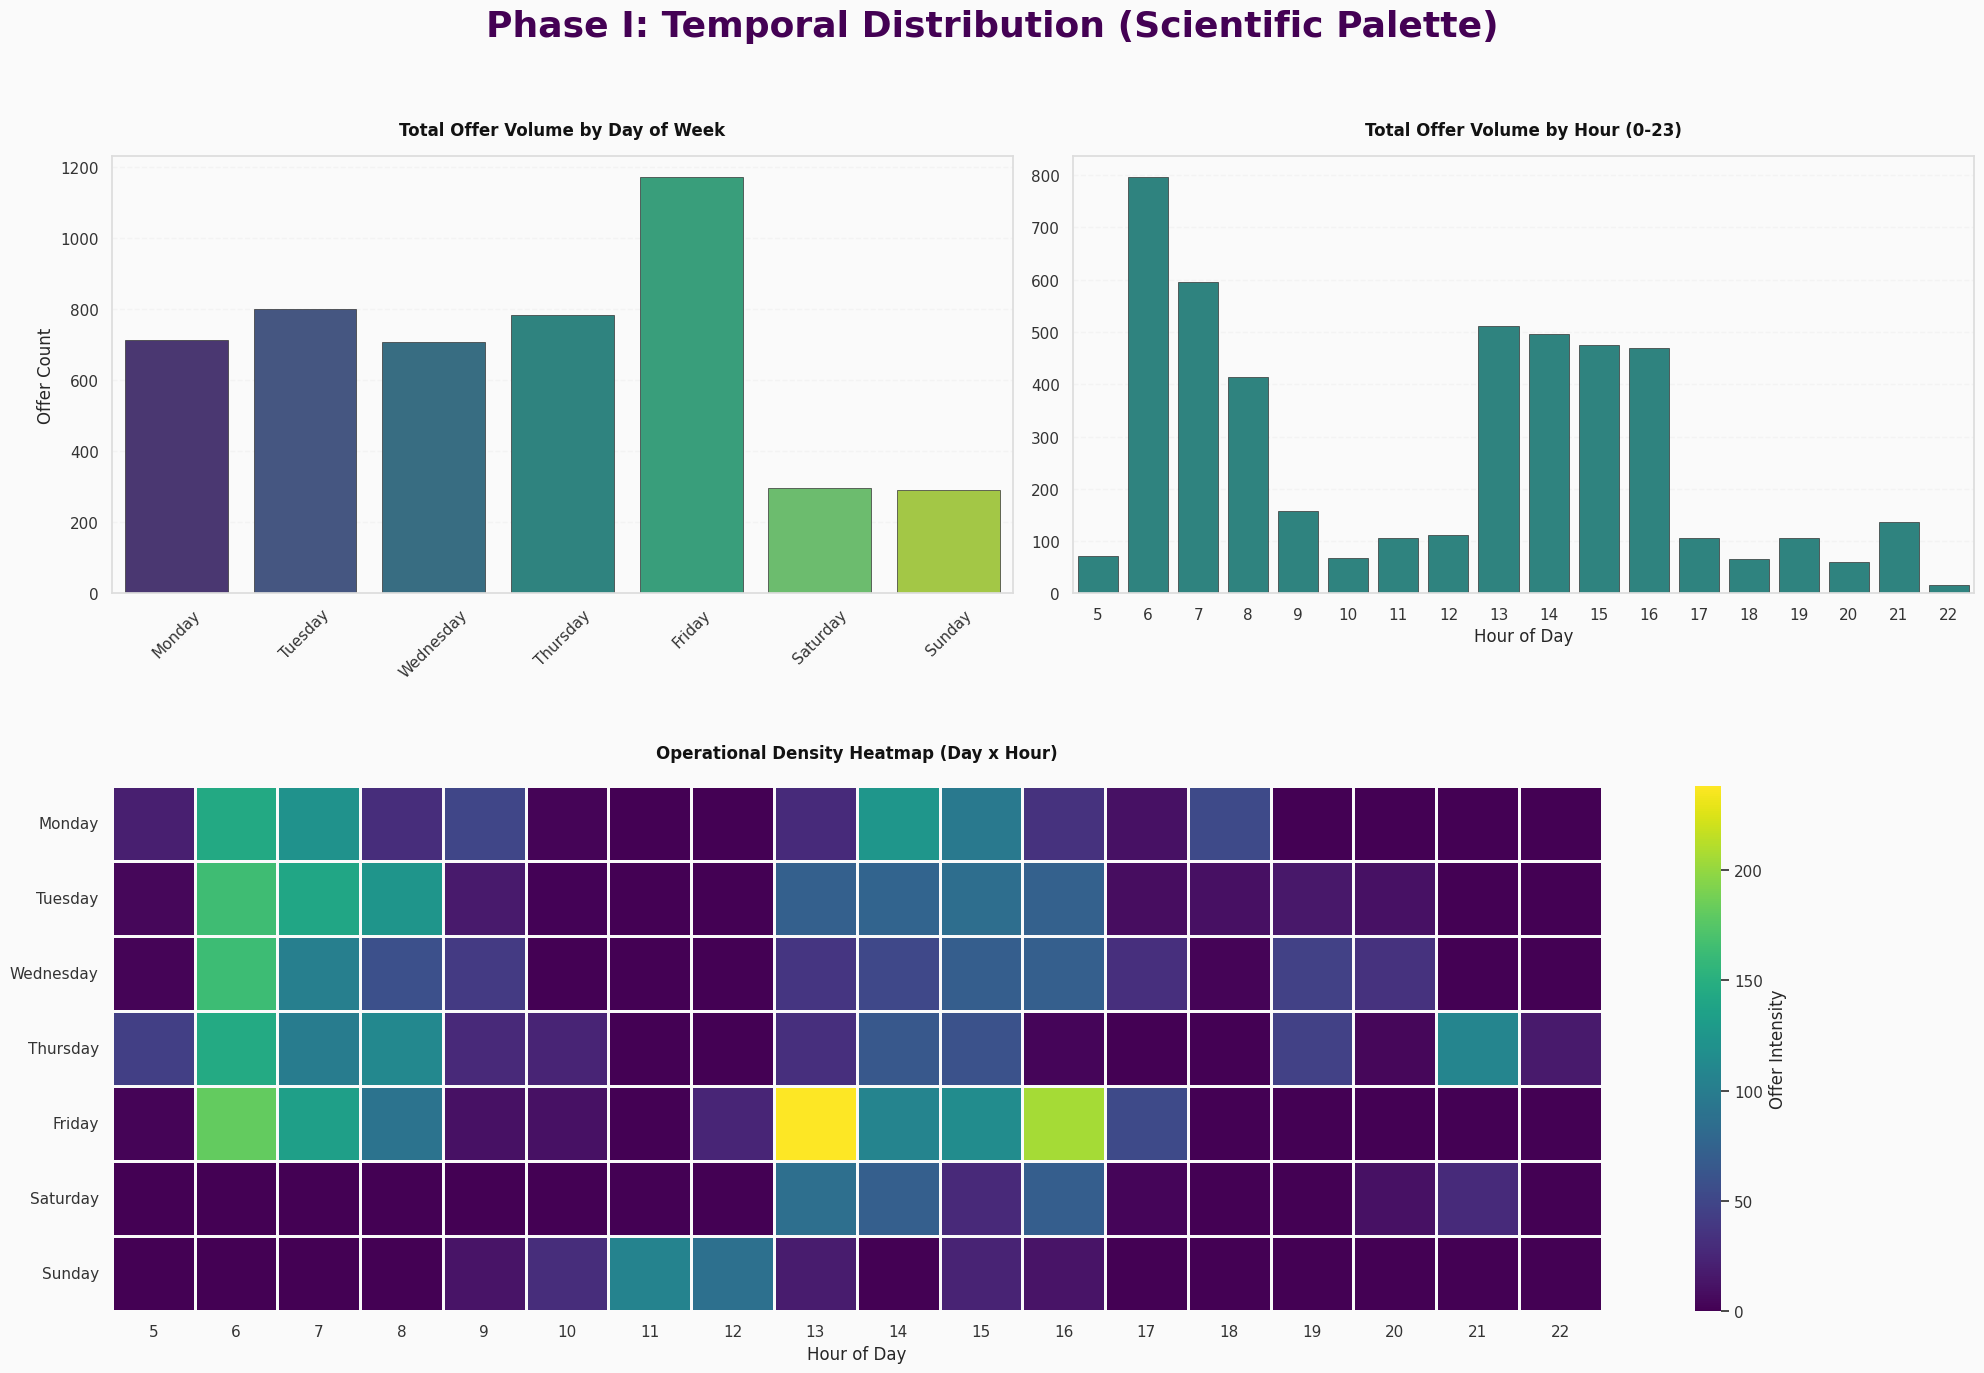

In [10]:
# ==============================================================================
# CELL 3 (REVISED v3): TEMPORAL ANALYSIS // "VIRIDIS" (GREEN-PURPLE)
# ==============================================================================
# Purpose: Temporal distribution analysis using the "Viridis" scientific palette.
#          Removes DiDi association. Aligns with Money (Green) & Tech (Purple).
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. APPLY "OPUS LAB" THEME (Light Mode)
sns.set_theme(style="white")
opus_light_params = {
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor': '#FAFAFA',
    'text.color': '#121212',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.edgecolor': '#DDDDDD',
    'grid.color': '#EEEEEE',
    'font.family': 'sans-serif'
}
plt.rcParams.update(opus_light_params)

# 2. LOAD DATA (If not already loaded in memory)
if 'df_time' not in locals():
    print("⏳ Reloading timestamps...")
    query = "SELECT offer_timestamp FROM v_offers_human"
    df_time = pd.read_sql(query, db_engine)
    df_time['offer_timestamp'] = pd.to_datetime(df_time['offer_timestamp'])
    df_time['day_name'] = df_time['offer_timestamp'].dt.day_name()
    df_time['hour'] = df_time['offer_timestamp'].dt.hour
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    df_time['day_name'] = pd.Categorical(df_time['day_name'], categories=day_order, ordered=True)

# 3. PLOTTING CONFIGURATION
fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.2])

# MASTER TITLE (Deep Purple for Tech Elegance)
fig.suptitle('Phase I: Temporal Distribution (Scientific Palette)', fontsize=26, color='#440154', weight='bold', y=0.98)

# --- PLOT A: WEEKLY VOLUME (Top Left) ---
ax1 = fig.add_subplot(gs[0, 0])
# viridis: Purple -> Blue -> Green -> Yellow
sns.countplot(x='day_name', data=df_time, palette="viridis", ax=ax1, edgecolor='#333333', linewidth=0.5)
ax1.set_title("Total Offer Volume by Day of Week", fontweight='bold', pad=15)
ax1.set_xlabel('')
ax1.set_ylabel('Offer Count')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# --- PLOT B: HOURLY VOLUME (Top Right) ---
ax2 = fig.add_subplot(gs[0, 1])
# Use a solid "Teal" from the middle of the spectrum for clarity
sns.countplot(x='hour', data=df_time, color="#21918c", ax=ax2, edgecolor='#333333', linewidth=0.5)
ax2.set_title("Total Offer Volume by Hour (0-23)", fontweight='bold', pad=15)
ax2.set_xlabel('Hour of Day')
ax2.set_ylabel('')
ax2.grid(axis='y', linestyle='--', alpha=0.5)

# --- PLOT C: THE HEATMAP (Bottom) ---
heatmap_data = df_time.groupby(['day_name', 'hour'], observed=False).size().unstack(fill_value=0)

ax3 = fig.add_subplot(gs[1, :])
# cmap="viridis": The darker the purple, the lower the volume. The brighter the yellow, the higher.
sns.heatmap(heatmap_data, cmap="viridis", linewidths=1, linecolor='#FAFAFA', ax=ax3,
            cbar_kws={'label': 'Offer Intensity'})

ax3.set_title("Operational Density Heatmap (Day x Hour)", fontweight='bold', pad=20)
ax3.set_xlabel('Hour of Day', fontsize=12)
ax3.set_ylabel('')
ax3.tick_params(axis='y', rotation=0)

# 4. LAYOUT CORRECTION
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.subplots_adjust(hspace=0.4)

plt.show()

⏳ Loading product data...
✅ Loaded 4765 categorical records.


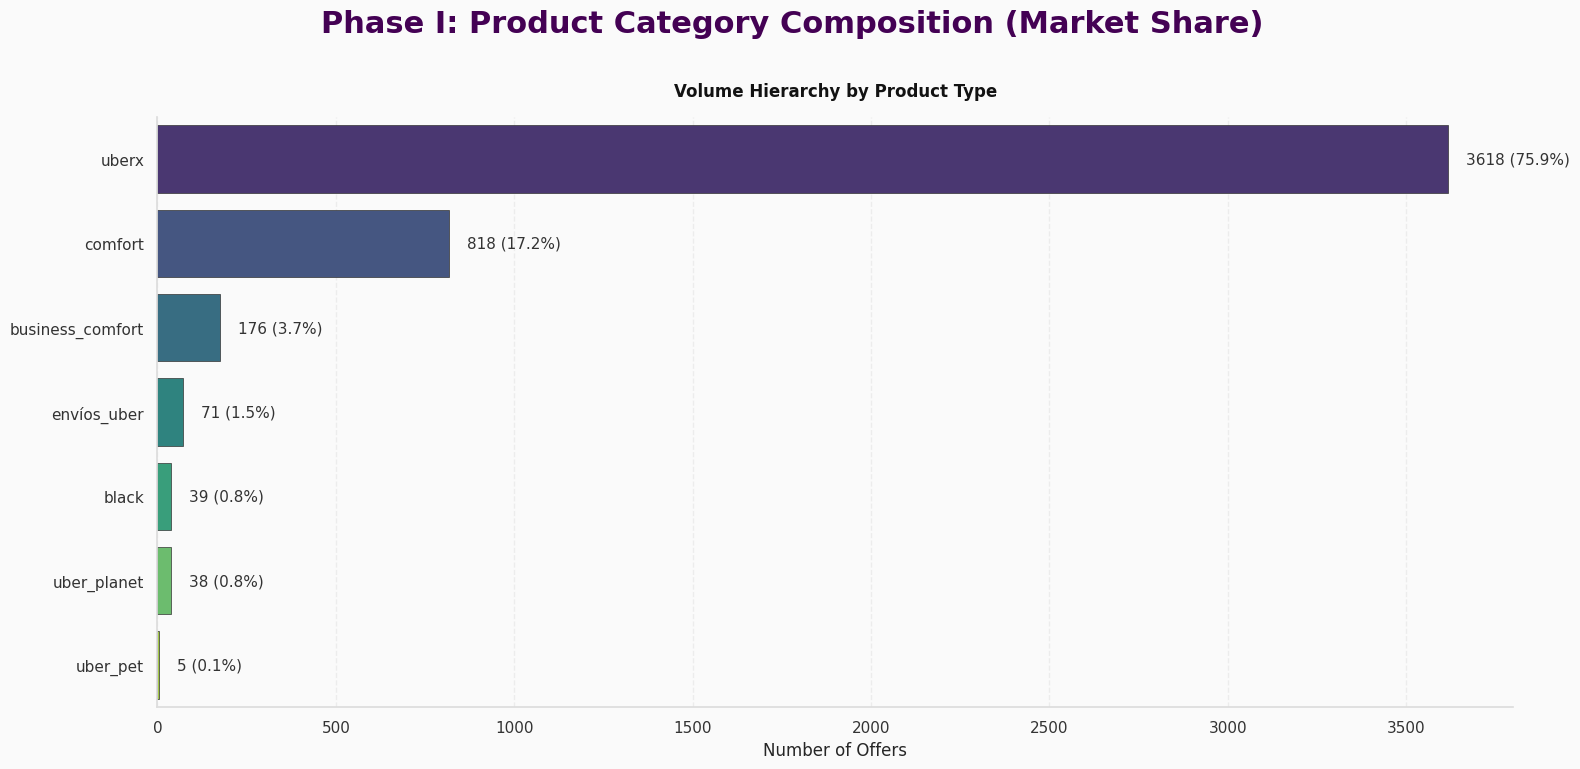

In [11]:
# ==============================================================================
# CELL 4 (REVISED): PRODUCT CATEGORY UNIVARIATE (PURE MARKET SHARE)
# ==============================================================================
# Purpose: Strict univariate analysis of Product Categories.
#          Focus: Frequency, Market Share %, and Operational Hierarchy.
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. APPLY "OPUS LAB" THEME
sns.set_theme(style="white")
opus_light_params = {
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor': '#FAFAFA',
    'text.color': '#121212',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.edgecolor': '#DDDDDD',
    'grid.color': '#E0E0E0',
    'font.family': 'sans-serif'
}
plt.rcParams.update(opus_light_params)

# 2. LOAD DATA
print("⏳ Loading product data...")
query = "SELECT str_product FROM v_offers_human WHERE str_product IS NOT NULL"
df_prod = pd.read_sql(query, db_engine)

# 3. CALCULATE METRICS
# We need Count and Percentage
prod_counts = df_prod['str_product'].value_counts().reset_index()
prod_counts.columns = ['str_product', 'count']
prod_counts['percent'] = (prod_counts['count'] / prod_counts['count'].sum()) * 100

print(f"✅ Loaded {len(df_prod)} categorical records.")

# 4. PLOTTING
fig, ax = plt.subplots(figsize=(16, 8))
fig.suptitle('Phase I: Product Category Composition (Market Share)', fontsize=22, color='#440154', weight='bold', y=0.96)

# Horizontal Bar Plot using Viridis (representing Volume intensity)
sns.barplot(x='count', y='str_product', data=prod_counts, palette="viridis", ax=ax, edgecolor='#333333', linewidth=0.5)

# Annotations (The Data)
for i, row in prod_counts.iterrows():
    # Format: "3612 (76.1%)"
    label = f"{row['count']} ({row['percent']:.1f}%)"
    ax.text(row['count'] + 50, i, label, va='center', fontsize=11, fontweight='medium', color='#333333')

ax.set_title("Volume Hierarchy by Product Type", fontweight='bold', pad=15)
ax.set_xlabel('Number of Offers')
ax.set_ylabel('')
ax.grid(axis='x', linestyle='--', alpha=0.5)

# Remove top and right spines for clean look
sns.despine()

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

⏳ Installing Geospatial Engine (Geopandas + Contextily)...


✅ Geospatial Engine Installed.
✅ Mapped 4674 points to Web Mercator projection.
⏳ Downloading Map Tiles...


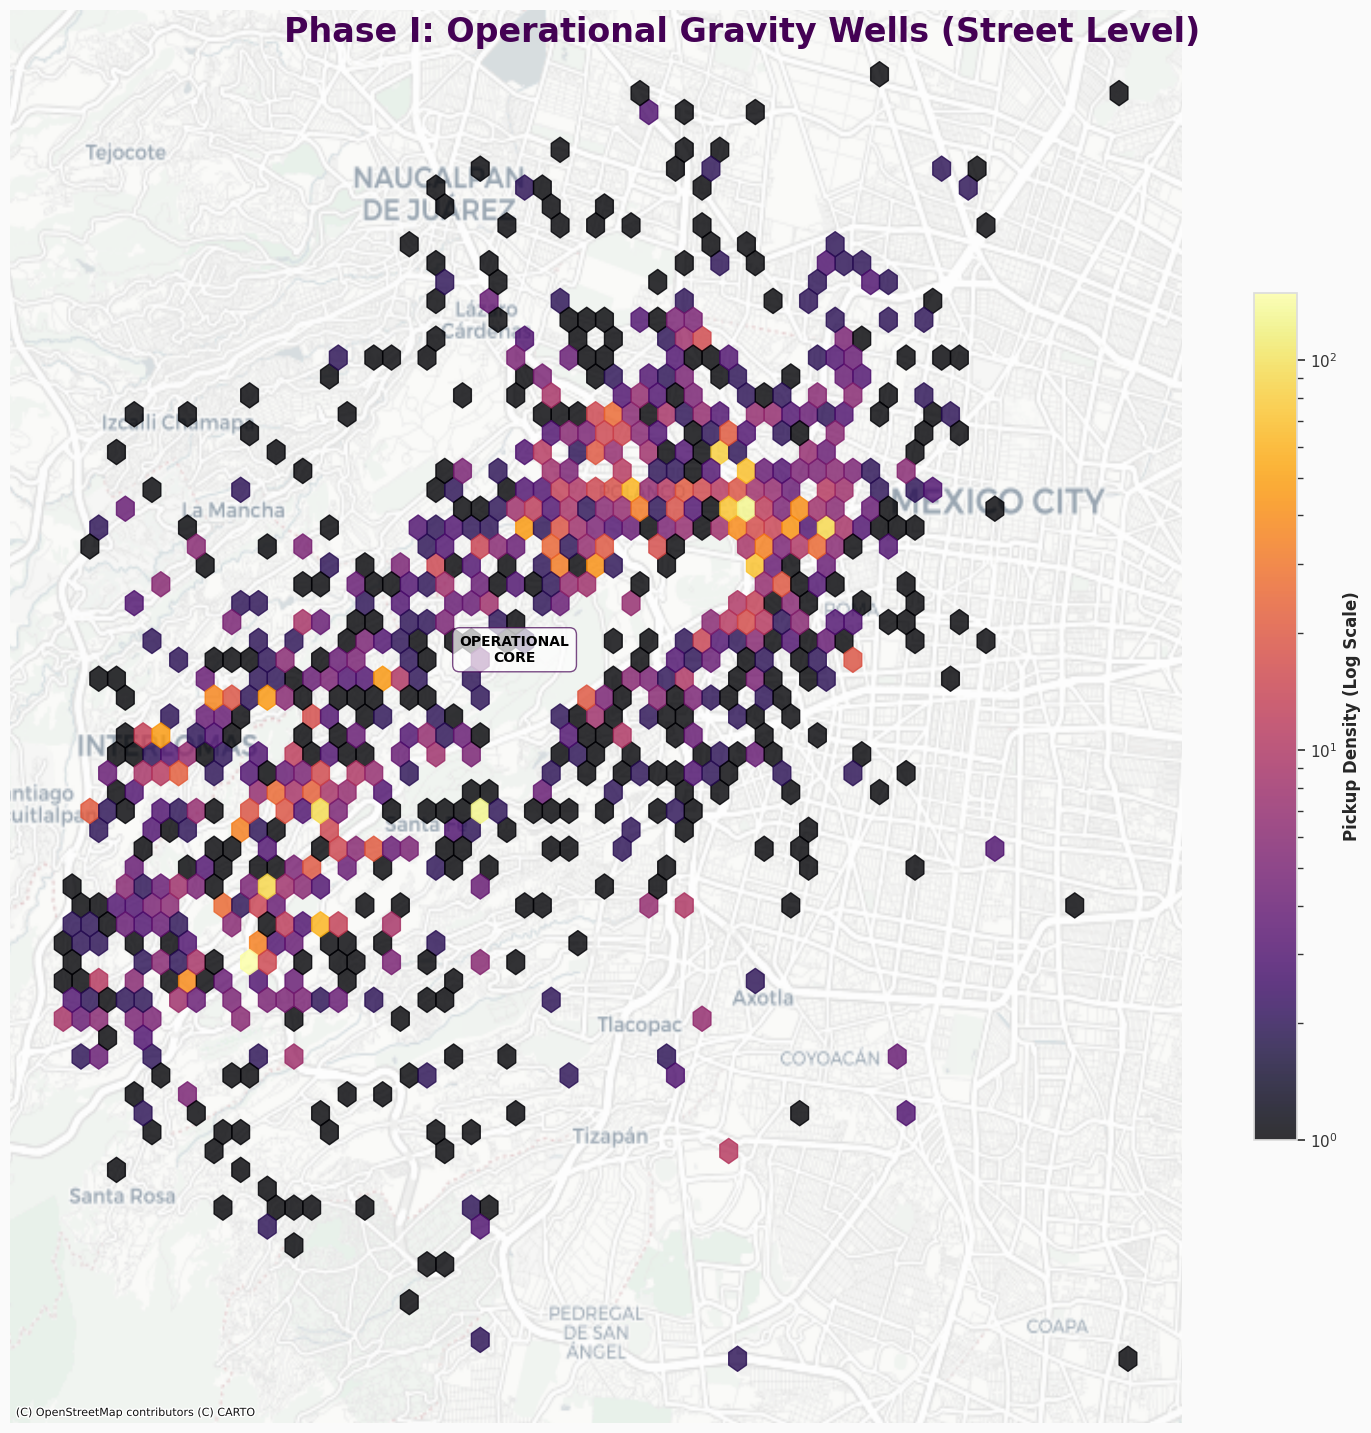

In [12]:
# ==============================================================================
# CELL 5 (REVISED v3): GEOSPATIAL MAP WITH STREET CONTEXT
# ==============================================================================
# Purpose: Uses Geopandas and Contextily to overlay data on a REAL street map.
#          Reveals the geographical reality (Polanco, Reforma, Insurgentes).
# ==============================================================================

# 1. INSTALL GEOSPATIAL LIBRARIES (Silent Install)
print("⏳ Installing Geospatial Engine (Geopandas + Contextily)...")
!pip install geopandas contextily -q
print("✅ Geospatial Engine Installed.")

import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt
import pandas as pd

# 2. LOAD DATA
query = """
SELECT pickup_lat, pickup_lon
FROM v_offers_human
WHERE pickup_lat IS NOT NULL AND pickup_lon IS NOT NULL
"""
df_geo = pd.read_sql(query, db_engine)

# Filter for Core CDMX (Remove extreme outliers for better zoom)
df_geo = df_geo[
    (df_geo['pickup_lat'].between(19.28, 19.50)) &
    (df_geo['pickup_lon'].between(-99.30, -99.10))
]

# 3. CONVERT TO GEODATAFRAME
# We tell Python: "These columns are coordinates (EPSG:4326 - GPS Standard)"
gdf = gpd.GeoDataFrame(
    df_geo, geometry=gpd.points_from_xy(df_geo.pickup_lon, df_geo.pickup_lat), crs="EPSG:4326"
)

# 4. REPROJECT TO WEB MERCATOR (EPSG:3857)
# This is mandatory to match the background map tiles (Google/Carto style)
gdf = gdf.to_crs(epsg=3857)

print(f"✅ Mapped {len(gdf)} points to Web Mercator projection.")

# 5. PLOTTING CONFIGURATION
fig, ax = plt.subplots(figsize=(15, 15))
fig.suptitle('Phase I: Operational Gravity Wells (Street Level)', fontsize=24, color='#440154', weight='bold', y=0.95)

# --- LAYER 1: THE HEXBIN DENSITY (DATA) ---
# We use matplotlib's native hexbin because it handles coordinates better than seaborn here.
# cmap='inferno': High contrast against the light map. Yellow/Orange = HOT.
hb = ax.hexbin(gdf.geometry.x, gdf.geometry.y, gridsize=60, cmap='inferno', bins='log', mincnt=1, alpha=0.8)

# --- LAYER 2: THE BASEMAP (CONTEXT) ---
# source=ctx.providers.CartoDB.Positron: A clean, greyscale street map that doesn't distract.
print("⏳ Downloading Map Tiles...")
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, alpha=0.9)

# 6. AESTHETICS
ax.set_axis_off() # Hide X/Y numbers (Lat/Lon), we have streets now.
cb = plt.colorbar(hb, ax=ax, shrink=0.6)
cb.set_label('Pickup Density (Log Scale)', fontsize=12, weight='bold')

# Add Annotation for Context
# Note: Coordinates must now be in Web Mercator, not Lat/Lon.
# We pick a point near the center of data
x_mean = gdf.geometry.x.mean()
y_mean = gdf.geometry.y.mean()
ax.text(x_mean, y_mean, 'OPERATIONAL\nCORE', color='black', fontsize=10, fontweight='bold', ha='center',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='#440154', boxstyle='round,pad=0.5'))

plt.tight_layout()
plt.show()

⏳ Loading Dropoff Geospatial Data...
✅ Mapped 4653 dropoff points.


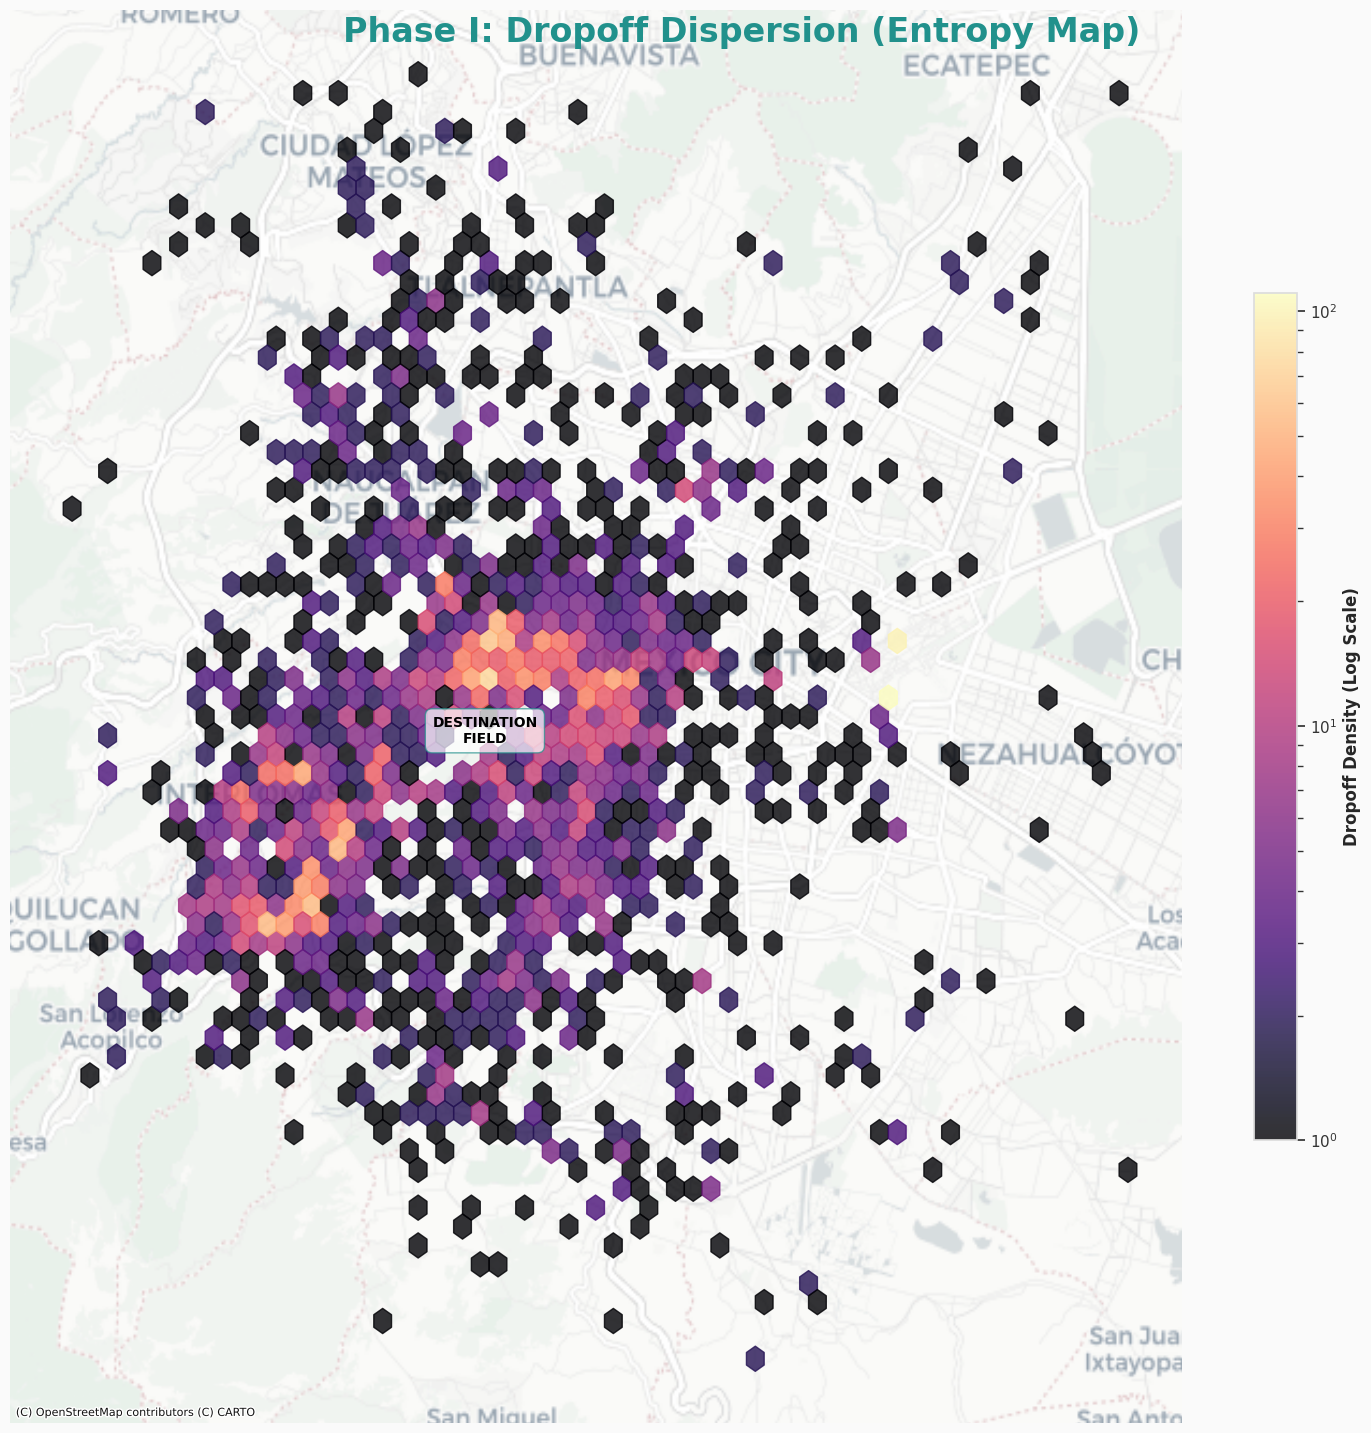

In [13]:
# ==============================================================================
# CELL 6: GEOSPATIAL DROPOFFS (THE ENTROPY MAP)
# ==============================================================================
# Purpose: Visualizing Dropoff dispersion. Contrast this with the Pickup map.
#          Pickups are chosen (Strategy). Dropoffs are imposed (Entropy).
# ==============================================================================

import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt
import pandas as pd

# 1. LOAD DATA (DROPOFFS)
print("⏳ Loading Dropoff Geospatial Data...")
query = """
SELECT dropoff_lat, dropoff_lon
FROM v_offers_human
WHERE dropoff_lat IS NOT NULL AND dropoff_lon IS NOT NULL
"""
df_drop = pd.read_sql(query, db_engine)

# 2. FILTERING (Wider Lens)
# We widen the filter slightly compared to Pickups, because Dropoffs naturally go further out.
# Covering roughly from Satélite (North) to Coapa (South) and Santa Fe (West)
df_drop = df_drop[
    (df_drop['dropoff_lat'].between(19.20, 19.60)) &
    (df_drop['dropoff_lon'].between(-99.35, -99.00))
]

# 3. CONVERT TO GEODATAFRAME & REPROJECT
gdf_drop = gpd.GeoDataFrame(
    df_drop, geometry=gpd.points_from_xy(df_drop.dropoff_lon, df_drop.dropoff_lat), crs="EPSG:4326"
)
gdf_drop = gdf_drop.to_crs(epsg=3857)

print(f"✅ Mapped {len(gdf_drop)} dropoff points.")

# 4. PLOTTING
fig, ax = plt.subplots(figsize=(15, 15))
fig.suptitle('Phase I: Dropoff Dispersion (Entropy Map)', fontsize=24, color='#21918c', weight='bold', y=0.95)

# --- LAYER 1: DENSITY (Magma Palette) ---
# Using 'magma' (Purple->Red->Yellow) to distinguish visually from Pickups (Inferno)
# It looks slightly more "expansive".
hb = ax.hexbin(gdf_drop.geometry.x, gdf_drop.geometry.y, gridsize=60, cmap='magma', bins='log', mincnt=1, alpha=0.8)

# --- LAYER 2: BASEMAP ---
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, alpha=0.9)

# 5. AESTHETICS
ax.set_axis_off()
cb = plt.colorbar(hb, ax=ax, shrink=0.6)
cb.set_label('Dropoff Density (Log Scale)', fontsize=12, weight='bold')

# Annotation
x_mean = gdf_drop.geometry.x.mean()
y_mean = gdf_drop.geometry.y.mean()
ax.text(x_mean, y_mean, 'DESTINATION\nFIELD', color='black', fontsize=10, fontweight='bold', ha='center',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='#21918c', boxstyle='round,pad=0.5'))

plt.tight_layout()
plt.show()

⏳ Loading incentive data from 'offers' table...

--- 📊 INCENTIVE STATISTICS (ACTIVE CASES ONLY) ---


,Count (N),Prevalence (%),Min,Median ($),Max ($),Mean ($)
Incentive,,,,,,
Dynamic Surge ⚡,1509,31.668416,4.00,8.00,124.00,13.916952
Turbo+ Bonus 🚀,1336,28.037775,4.31,25.41,118.03,28.579918
Reservation 📅,158,3.315845,0.85,53.10,171.86,58.130380
Priority Pickup ⭐,173,3.630640,18.81,18.81,27.67,18.901965


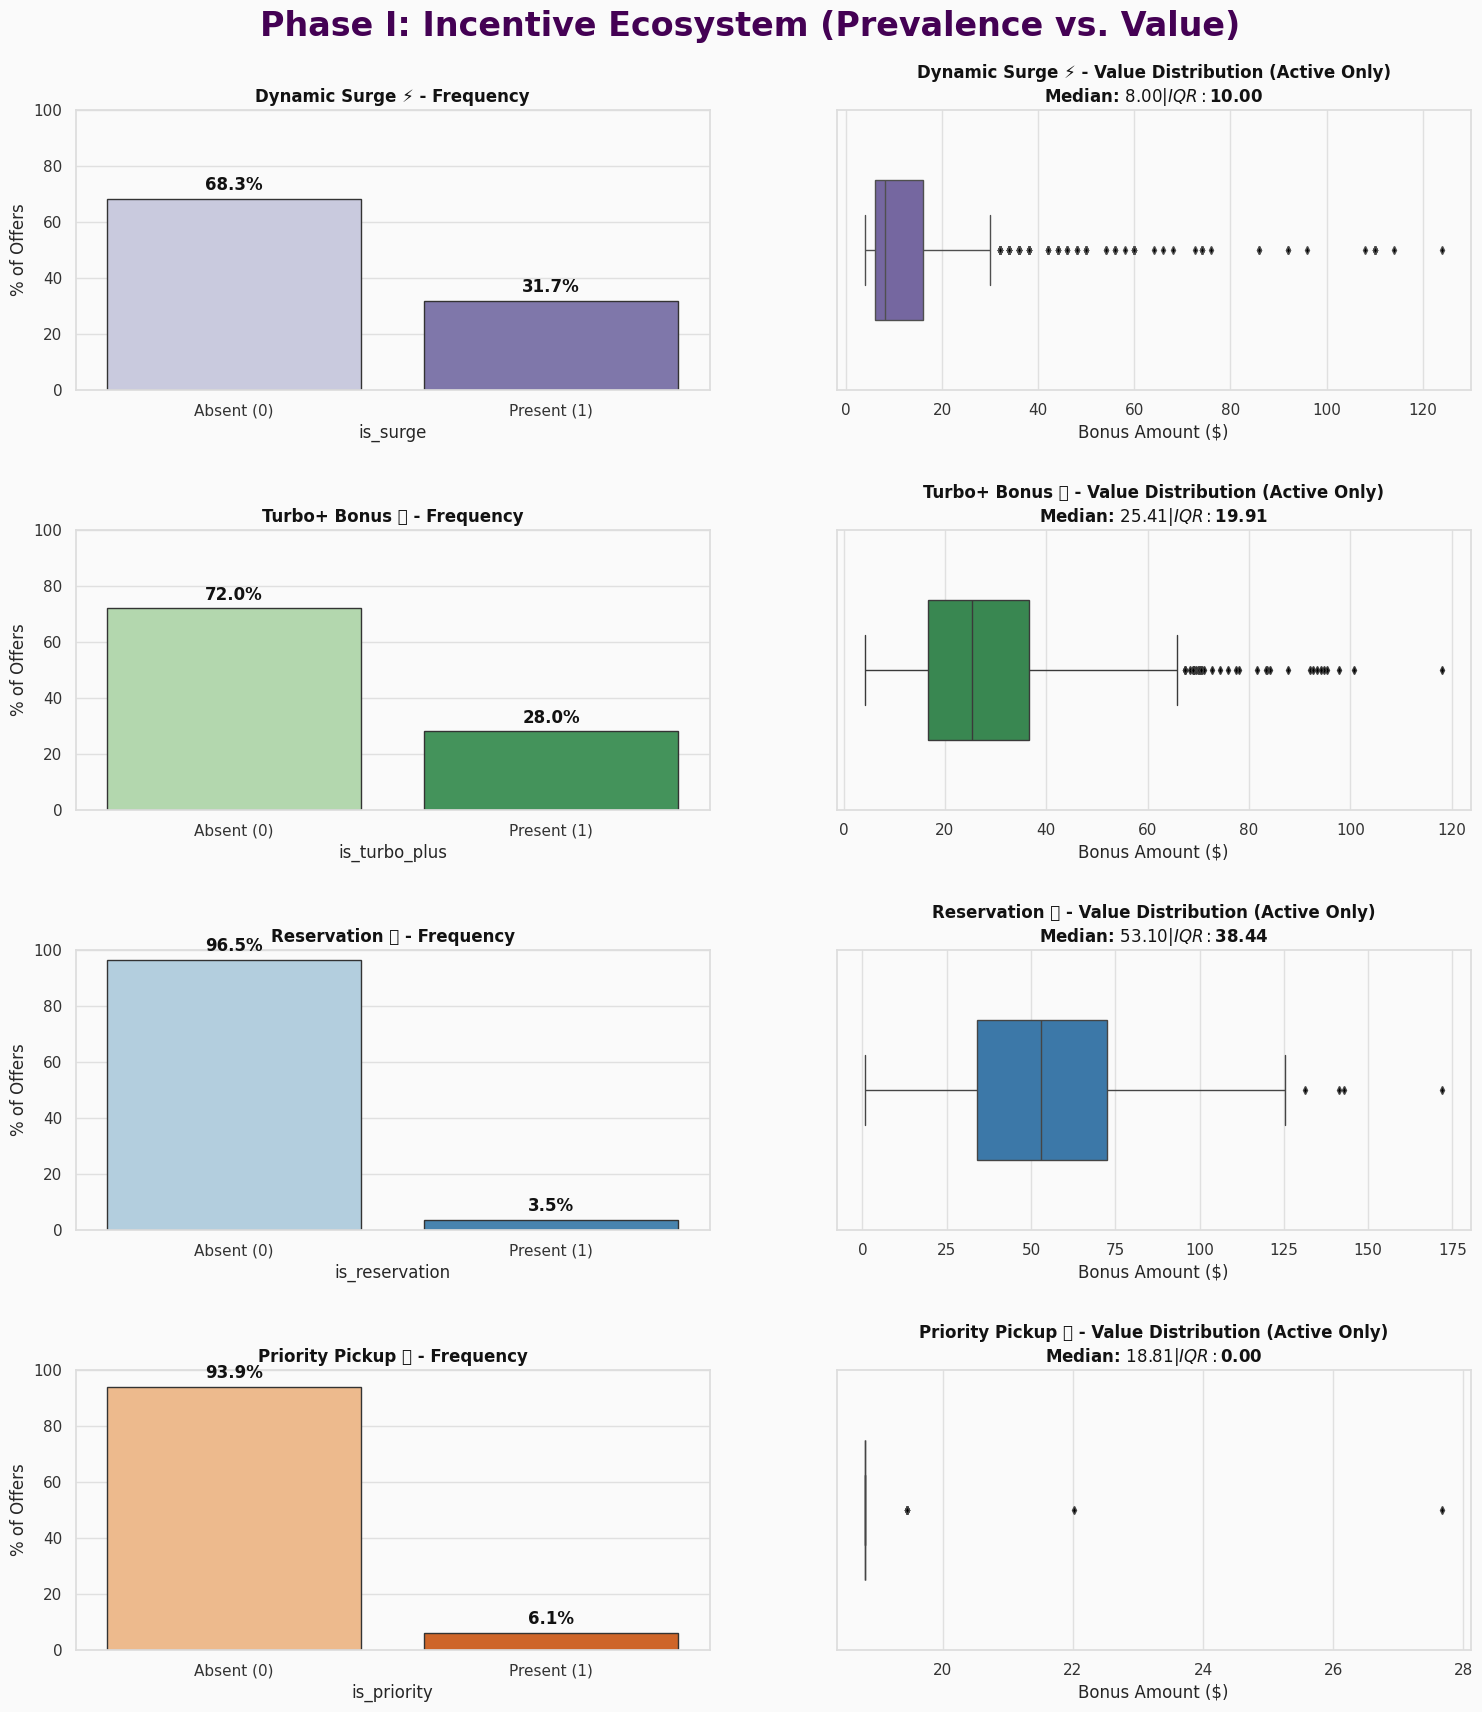

In [19]:
# ==============================================================================
# CELL 7 (REVISED v2): INCENTIVE STRUCTURE (SOURCE: RAW TABLE)
# ==============================================================================
# Purpose: Analyzes incentives. Switches source to 'offers' table to bypass
#          missing columns in the 'v_offers_human' view.
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. APPLY "OPUS LAB" THEME
sns.set_theme(style="whitegrid")
opus_light_params = {
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor': '#FAFAFA',
    'text.color': '#121212',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.edgecolor': '#DDDDDD',
    'grid.color': '#E0E0E0',
    'font.family': 'sans-serif'
}
plt.rcParams.update(opus_light_params)

# 2. LOAD DATA (DIRECT FROM SOURCE TABLE)
print("⏳ Loading incentive data from 'offers' table...")
query = """
SELECT
    is_surge, surge_amount,
    is_turbo_plus, turbo_plus_amount,
    is_reservation, reservation_amount,
    is_priority, priority_amount
FROM offers
"""
df_inc = pd.read_sql(query, db_engine)

# 3. PLOTTING CONFIGURATION
fig, axes = plt.subplots(4, 2, figsize=(18, 20))
plt.subplots_adjust(hspace=0.5, wspace=0.2)
fig.suptitle('Phase I: Incentive Ecosystem (Prevalence vs. Value)', fontsize=24, color='#440154', weight='bold', y=0.93)

incentives = [
    ('is_surge', 'surge_amount', 'Dynamic Surge ⚡', 'Purples'),
    ('is_turbo_plus', 'turbo_plus_amount', 'Turbo+ Bonus 🚀', 'Greens'),
    ('is_reservation', 'reservation_amount', 'Reservation 📅', 'Blues'),
    ('is_priority', 'priority_amount', 'Priority Pickup ⭐', 'Oranges')
]

# 4. GENERATE LOOPS
for i, (flag_col, amt_col, title, palette) in enumerate(incentives):

    # --- LEFT PLOT: PREVALENCE ---
    ax_freq = axes[i, 0]

    # Handle cases where column might be missing entirely (Safety check)
    if flag_col in df_inc.columns:
        counts = df_inc[flag_col].value_counts(normalize=True).sort_index() * 100
        sns.barplot(x=counts.index, y=counts.values, ax=ax_freq, palette=palette, edgecolor='#333333')

        ax_freq.set_title(f"{title} - Frequency", fontweight='bold')
        ax_freq.set_ylabel('% of Offers')
        ax_freq.set_xticklabels(['Absent (0)', 'Present (1)'])
        ax_freq.set_ylim(0, 100)

        for p in ax_freq.patches:
            ax_freq.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                             ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points', fontweight='bold')
    else:
        ax_freq.text(0.5, 0.5, "Column Missing", ha='center')

    # --- RIGHT PLOT: MAGNITUDE ---
    ax_mag = axes[i, 1]
    if amt_col in df_inc.columns:
        # Filter for active incentives
        df_active = df_inc[df_inc[amt_col] > 0]

        if not df_active.empty:
            sns.boxplot(x=df_active[amt_col], ax=ax_mag, color=sns.color_palette(palette)[-2],
                        width=0.5, flierprops={"marker": "d", "markerfacecolor": "black", "markersize": 4})

            med = df_active[amt_col].median()
            iqr = df_active[amt_col].quantile(0.75) - df_active[amt_col].quantile(0.25)
            ax_mag.set_title(f"{title} - Value Distribution (Active Only)\nMedian: ${med:.2f} | IQR: ${iqr:.2f}", fontweight='bold')
            ax_mag.set_xlabel('Bonus Amount ($)')
        else:
            ax_mag.text(0.5, 0.5, "No Active Data", ha='center', va='center')
    else:
        ax_mag.text(0.5, 0.5, "Column Missing", ha='center')

# 5. GENERATE STATS TABLE
print("\n--- 📊 INCENTIVE STATISTICS (ACTIVE CASES ONLY) ---")
stats_list = []
for flag, amt, name, _ in incentives:
    if amt in df_inc.columns:
        data = df_inc[df_inc[amt] > 0][amt]
        if not data.empty:
            desc = data.describe(percentiles=[0.25, 0.5, 0.75])
            stats_list.append({
                'Incentive': name,
                'Count (N)': int(desc['count']),
                'Prevalence (%)': (desc['count'] / len(df_inc) * 100),
                'Min': desc['min'],
                'Median ($)': desc['50%'],
                'Max ($)': desc['max'],
                'Mean ($)': desc['mean']
            })

if stats_list:
    df_stats = pd.DataFrame(stats_list).set_index('Incentive')
    # CODESPACE READY: Simplemente usamos display()
    # VS Code renderizará la tabla interactiva automáticamente
    display(df_stats)

plt.show()

⏳ Loading boolean flags...


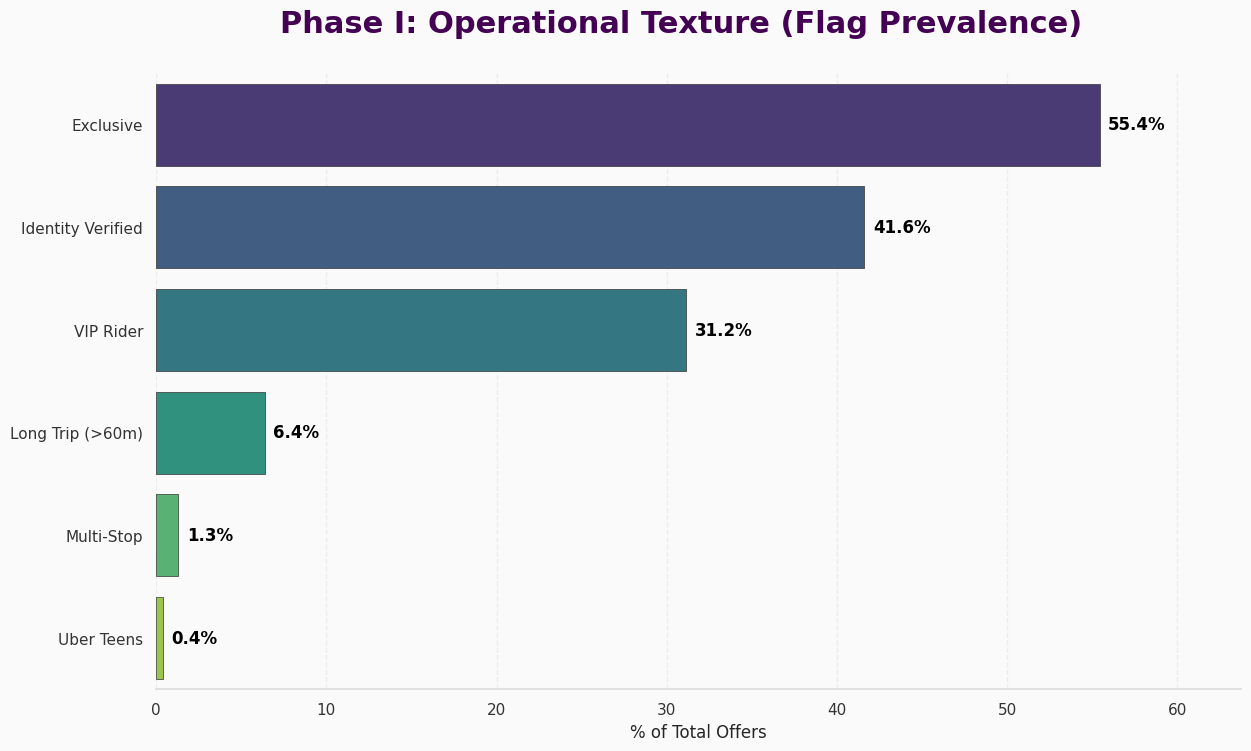

In [21]:
# ==============================================================================
# CELL 8: OPERATIONAL FLAGS PREVALENCE (BOOLEAN ANALYSIS)
# ==============================================================================
# Purpose: To visualize the frequency of non-monetary operational flags.
#          Reveals the "texture" of the rides (Risk, Status, Complexity).
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. APPLY "OPUS LAB" THEME
sns.set_theme(style="white")
opus_light_params = {
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor': '#FAFAFA',
    'text.color': '#121212',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.edgecolor': '#DDDDDD',
    'grid.color': '#E0E0E0',
    'font.family': 'sans-serif'
}
plt.rcParams.update(opus_light_params)

# 2. LOAD DATA
print("⏳ Loading boolean flags...")
query = """
SELECT
    is_exclusive,
    is_identity_verified,
    is_vip,
    is_long_trip,
    is_multiple_destinations,
    is_teens
FROM offers
"""
df_bool = pd.read_sql(query, db_engine)

# 3. CALCULATE PREVALENCE
# Mean of a boolean (0/1) is the percentage of True values
prevalence = df_bool.mean() * 100
prevalence = prevalence.sort_values(ascending=False)

# Create a clean dataframe for plotting
df_plot = prevalence.reset_index()
df_plot.columns = ['Flag', 'Percent']

# Dictionary to map DB columns to Human Readable Labels
label_map = {
    'is_exclusive': 'Exclusive',
    'is_identity_verified': 'Identity Verified',
    'is_vip': 'VIP Rider',
    'is_long_trip': 'Long Trip (>60m)',
    'is_multiple_destinations': 'Multi-Stop',
    'is_teens': 'Uber Teens'
}
df_plot['Label'] = df_plot['Flag'].map(label_map)

# 4. PLOTTING
fig, ax = plt.subplots(figsize=(14, 8))
fig.suptitle('Phase I: Operational Texture (Flag Prevalence)', fontsize=22, color='#440154', weight='bold', y=0.96)

# Horizontal Bar Plot
sns.barplot(x='Percent', y='Label', data=df_plot, palette="viridis", ax=ax, edgecolor='#333333', linewidth=0.5)

# Aesthetics
ax.set_xlabel('% of Total Offers')
ax.set_ylabel('')
ax.set_xlim(0, max(df_plot['Percent']) * 1.15) # Add breathing room for labels
ax.grid(axis='x', linestyle='--', alpha=0.5)

# Annotations
for i, v in enumerate(df_plot['Percent']):
    ax.text(v + 0.5, i, f"{v:.1f}%", color='black', fontweight='bold', va='center')

# Remove spines
sns.despine(left=True, bottom=False)

plt.show()

⏳ Loading rider profile data...
✅ Analyzed 4716 rider profiles.


/usr/local/python/3.12.1/lib/python3.12/site-packages/pandas/core/nanops.py:1027: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)



--- 📊 RIDER STATISTICS ---


,count,min,5%,25%,50%,75%,95%,max,mean,std
rider_star_rating,4716.0,3.62,4.58,4.72,4.79,4.85,4.92,5.0,4.775937,0.111090
rider_trip_count,4716.0,0.00,47.00,274.00,631.00,1297.00,3033.25,83296.0,1000.760602,1845.121653


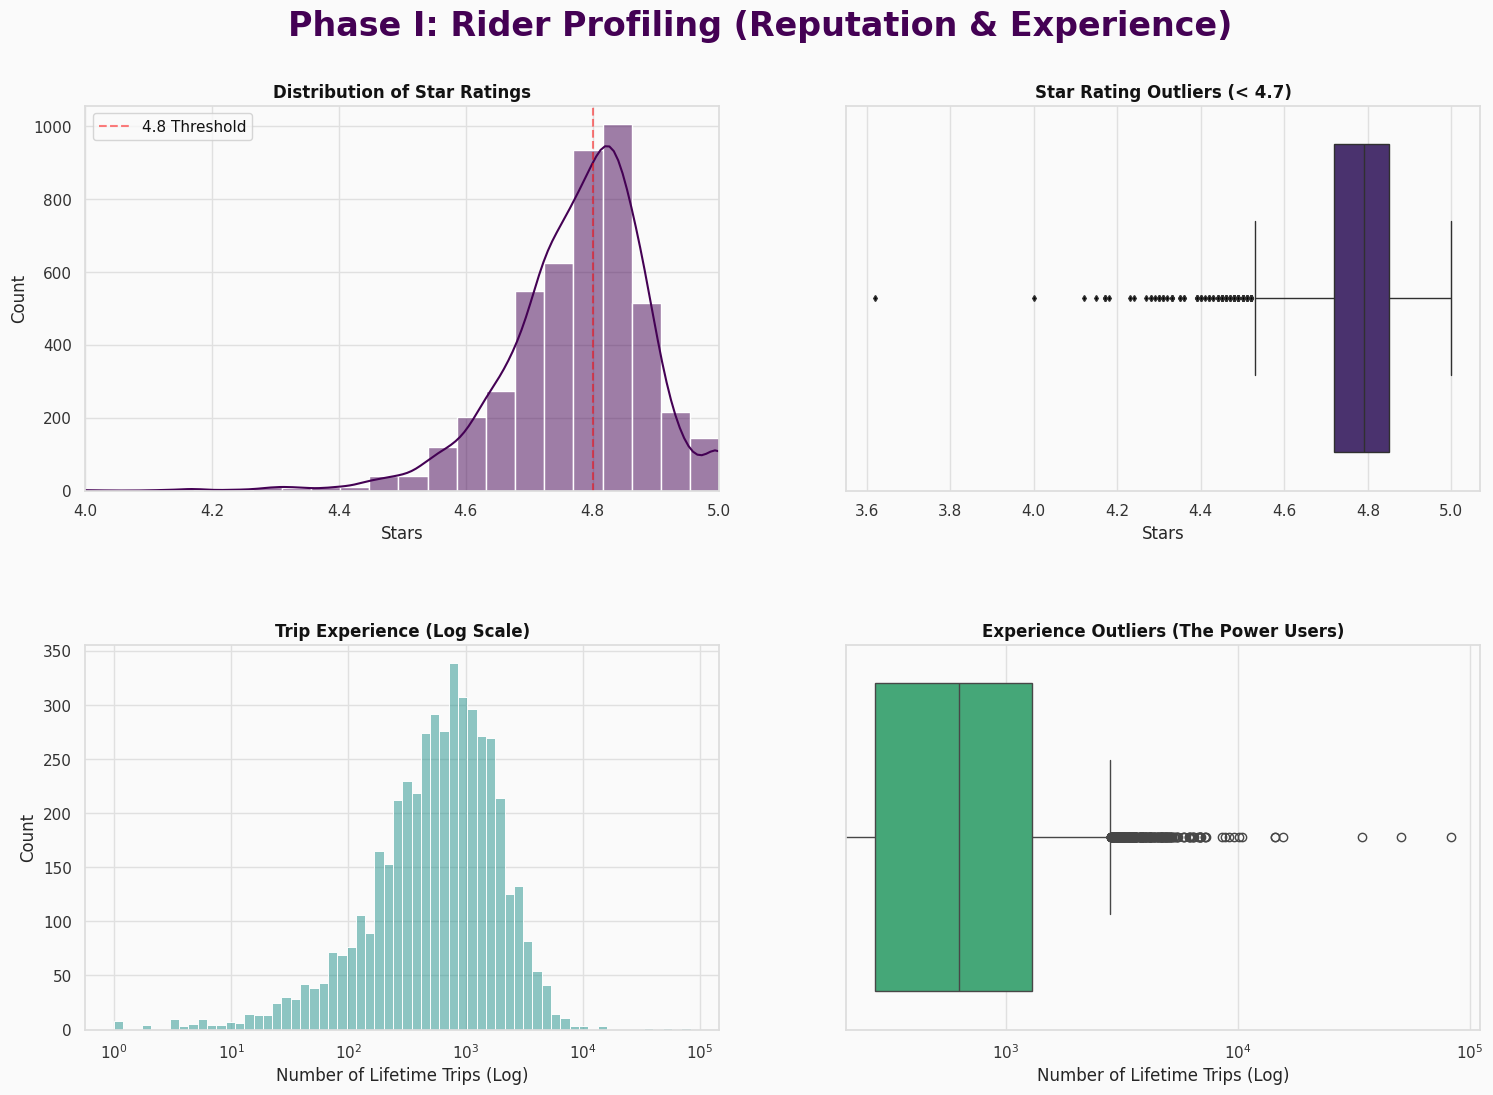

In [22]:
# ==============================================================================
# CELL 9: RIDER PROFILING (RATING & EXPERIENCE)
# ==============================================================================
# Purpose: To analyze the distribution of Rider Quality (Stars) and Experience (Trips).
#          Uses Log Scale for Trip Count to handle the Power Law distribution.
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. APPLY "OPUS LAB" THEME
sns.set_theme(style="whitegrid")
opus_light_params = {
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor': '#FAFAFA',
    'text.color': '#121212',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.edgecolor': '#DDDDDD',
    'grid.color': '#E0E0E0',
    'font.family': 'sans-serif'
}
plt.rcParams.update(opus_light_params)

# 2. LOAD DATA
print("⏳ Loading rider profile data...")
# Filter out NULLs (Ghost offers)
query = """
SELECT
    rider_star_rating,
    rider_trip_count
FROM offers
WHERE rider_star_rating IS NOT NULL AND rider_trip_count IS NOT NULL
"""
df_rider = pd.read_sql(query, db_engine)
print(f"✅ Analyzed {len(df_rider)} rider profiles.")

# 3. PLOTTING CONFIGURATION
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.2)
fig.suptitle('Phase I: Rider Profiling (Reputation & Experience)', fontsize=24, color='#440154', weight='bold', y=0.96)

# --- ROW 1: STAR RATING (Focus on the < 4.8 Danger Zone) ---
# Plot A: Histogram (Distribution)
sns.histplot(data=df_rider, x="rider_star_rating", kde=True, color="#440154", bins=30, ax=axes[0, 0])
axes[0, 0].set_title("Distribution of Star Ratings", fontweight='bold')
axes[0, 0].set_xlabel("Stars")
axes[0, 0].set_xlim(4.0, 5.0) # Zoom in on relevant range (Nobody accepts < 4.0 usually)
# Add "Psychological Threshold" line
axes[0, 0].axvline(4.8, color='red', linestyle='--', alpha=0.5, label='4.8 Threshold')
axes[0, 0].legend()

# Plot B: Boxplot (Outliers)
sns.boxplot(x=df_rider["rider_star_rating"], ax=axes[0, 1], color="#482878",
            flierprops={"marker": "d", "markerfacecolor": "black", "markersize": 3})
axes[0, 1].set_title("Star Rating Outliers (< 4.7)", fontweight='bold')
axes[0, 1].set_xlabel("Stars")


# --- ROW 2: TRIP COUNT (Power Law - LOG SCALE) ---
# Plot C: Histogram (Log Scale)
sns.histplot(data=df_rider, x="rider_trip_count", kde=True, color="#21918c", log_scale=True, ax=axes[1, 0])
axes[1, 0].set_title("Trip Experience (Log Scale)", fontweight='bold')
axes[1, 0].set_xlabel("Number of Lifetime Trips (Log)")

# Plot D: Boxplot (Log Scale)
sns.boxplot(x=df_rider["rider_trip_count"], ax=axes[1, 1], color="#35b779")
axes[1, 1].set_xscale("log") # Crucial for visibility
axes[1, 1].set_title("Experience Outliers (The Power Users)", fontweight='bold')
axes[1, 1].set_xlabel("Number of Lifetime Trips (Log)")


# 4. GENERATE STATISTICS TABLE
print("\n--- 📊 RIDER STATISTICS ---")
desc = df_rider.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T
# Add IQR
desc['IQR'] = desc['75%'] - desc['25%']
# Select columns
final_table = desc[['count', 'min', '5%', '25%', '50%', '75%', '95%', 'max', 'mean', 'std']]

# CODESPACE READY:
# Adiós al 'google.colab.data_table'. 
# VS Code detecta el DataFrame y te da herramientas de filtrado y sorting 
# superiores a las de Colab de forma nativa.
display(final_table)

plt.show()

⏳ Loading rider profile data...
✅ Analyzed 4683 rider profiles (filtered >= 4.4).


/usr/local/python/3.12.1/lib/python3.12/site-packages/pandas/core/nanops.py:1027: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)



--- 📊 RIDER STATISTICS (>= 4.4 Stars Only) ---


,count,min,5%,25%,50%,75%,95%,max,mean,std
rider_star_rating,4683.0,4.4,4.59,4.72,4.79,4.85,4.929,5.0,4.779564,0.101989
rider_trip_count,4683.0,0.0,50.00,275.50,632.00,1296.50,3009.400,83296.0,998.368567,1843.015825


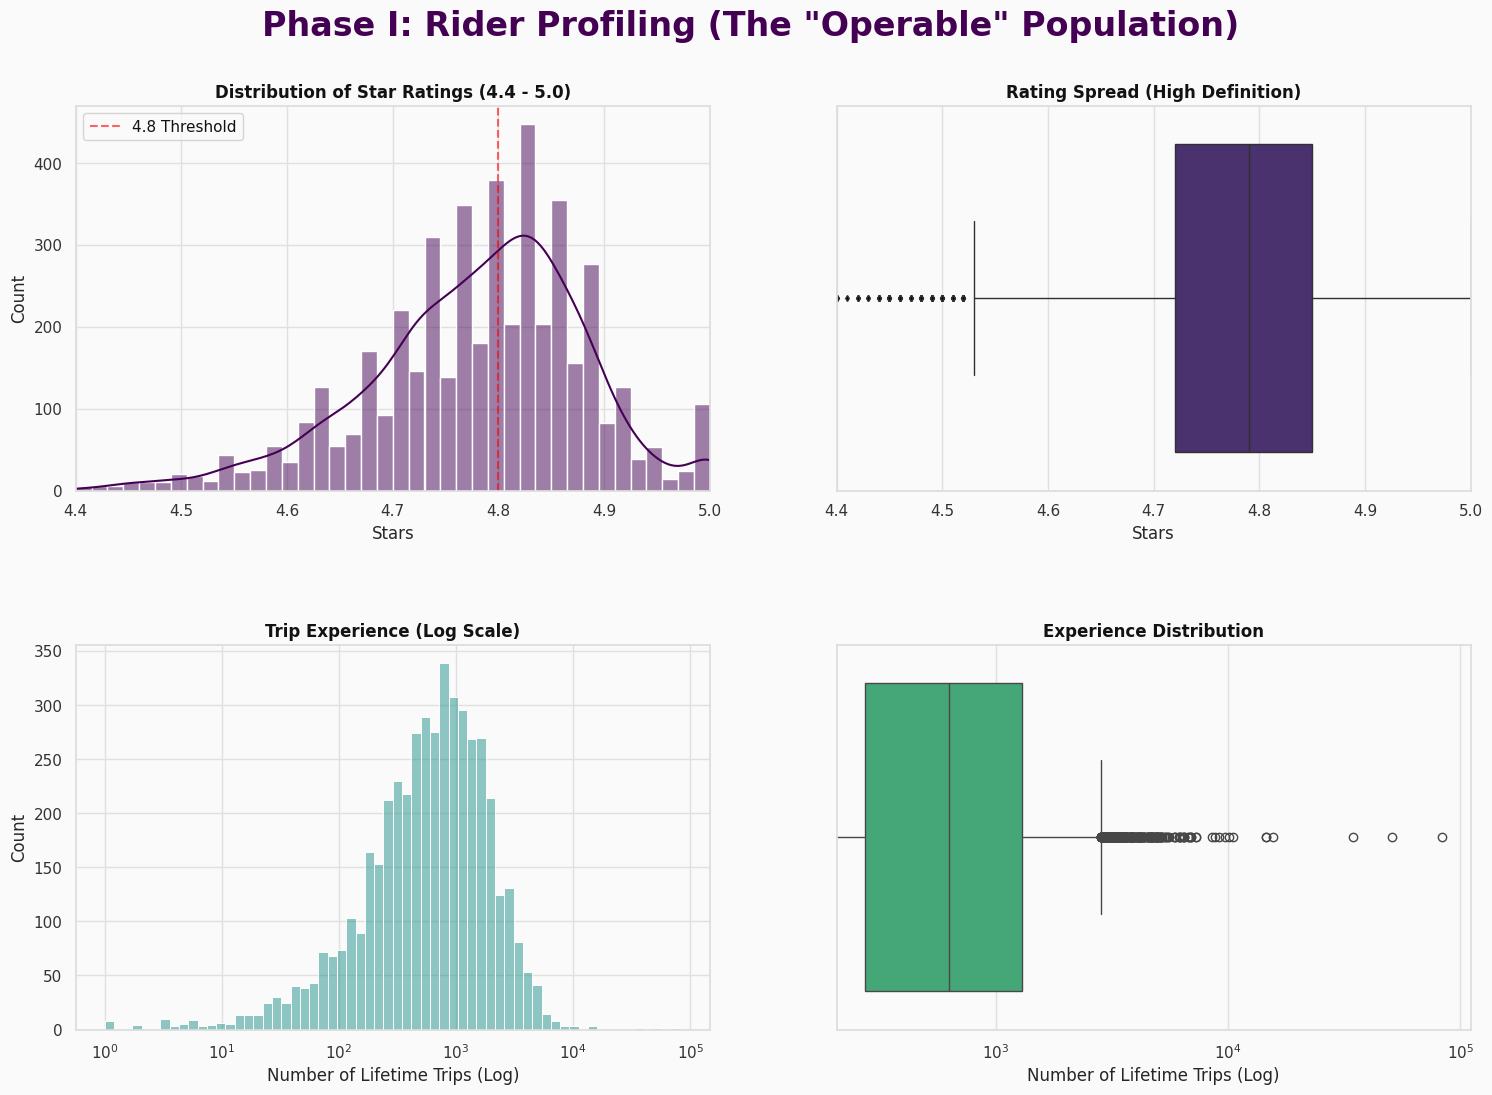

In [24]:
# ==============================================================================
# CELL 9 (REVISED v2): RIDER PROFILING (ZOOMED & CLEANED) - CODESPACE VERSION
# ==============================================================================
# Purpose: Rider analysis with a focus on the "Operable Range" (> 4.4 Stars).
#          Log scale retained for Trips to visualize the full spectrum of experience.
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. APPLY "OPUS LAB" THEME
sns.set_theme(style="whitegrid")
opus_light_params = {
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor': '#FAFAFA',
    'text.color': '#121212',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.edgecolor': '#DDDDDD',
    'grid.color': '#E0E0E0',
    'font.family': 'sans-serif'
}
plt.rcParams.update(opus_light_params)

# 2. LOAD DATA
print("⏳ Loading rider profile data...")
query = """
SELECT
    rider_star_rating,
    rider_trip_count
FROM offers
WHERE rider_star_rating IS NOT NULL AND rider_trip_count IS NOT NULL
"""
df_rider = pd.read_sql(query, db_engine)

# --- THE FILTER: REMOVING THE NOISE (< 4.4) ---
# Nos enfocamos en la población que realmente genera decisiones operativas.
df_rider = df_rider[df_rider['rider_star_rating'] >= 4.4]

print(f"✅ Analyzed {len(df_rider)} rider profiles (filtered >= 4.4).")

# 3. PLOTTING CONFIGURATION
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.2)
fig.suptitle('Phase I: Rider Profiling (The "Operable" Population)', fontsize=24, color='#440154', weight='bold', y=0.96)

# --- ROW 1: STAR RATING (ZOOMED IN) ---
sns.histplot(data=df_rider, x="rider_star_rating", kde=True, color="#440154", bins=40, ax=axes[0, 0])
axes[0, 0].set_title("Distribution of Star Ratings (4.4 - 5.0)", fontweight='bold')
axes[0, 0].set_xlabel("Stars")
axes[0, 0].set_xlim(4.4, 5.0) 
axes[0, 0].axvline(4.8, color='red', linestyle='--', alpha=0.6, label='4.8 Threshold')
axes[0, 0].legend(loc='upper left')

sns.boxplot(x=df_rider["rider_star_rating"], ax=axes[0, 1], color="#482878",
            flierprops={"marker": "d", "markerfacecolor": "black", "markersize": 3})
axes[0, 1].set_title("Rating Spread (High Definition)", fontweight='bold')
axes[0, 1].set_xlabel("Stars")
axes[0, 1].set_xlim(4.4, 5.0) 

# --- ROW 2: TRIP COUNT (Log Scale) ---
sns.histplot(data=df_rider, x="rider_trip_count", kde=True, color="#21918c", log_scale=True, ax=axes[1, 0])
axes[1, 0].set_title("Trip Experience (Log Scale)", fontweight='bold')
axes[1, 0].set_xlabel("Number of Lifetime Trips (Log)")

sns.boxplot(x=df_rider["rider_trip_count"], ax=axes[1, 1], color="#35b779")
axes[1, 1].set_xscale("log")
axes[1, 1].set_title("Experience Distribution", fontweight='bold')
axes[1, 1].set_xlabel("Number of Lifetime Trips (Log)")

# 4. STATISTICS TABLE
print("\n--- 📊 RIDER STATISTICS (>= 4.4 Stars Only) ---")
desc = df_rider.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T
final_table = desc[['count', 'min', '5%', '25%', '50%', '75%', '95%', 'max', 'mean', 'std']]

# CODESPACE READY: Eliminamos la dependencia de google.colab
display(final_table)

plt.show()

⏳ Calculating session durations...
✅ Analyzed 63 unique sessions.

--- 📊 SESSION STATISTICS (HH:MM:SS) ---


,Metric,Value (HH:MM:SS)
0,Count,63
1,Min,00:05:20
2,Q1 (25%),01:47:23
3,Median (50%),02:33:32
4,Mean,02:31:48
5,Q3 (75%),03:14:06
6,Max,04:47:30


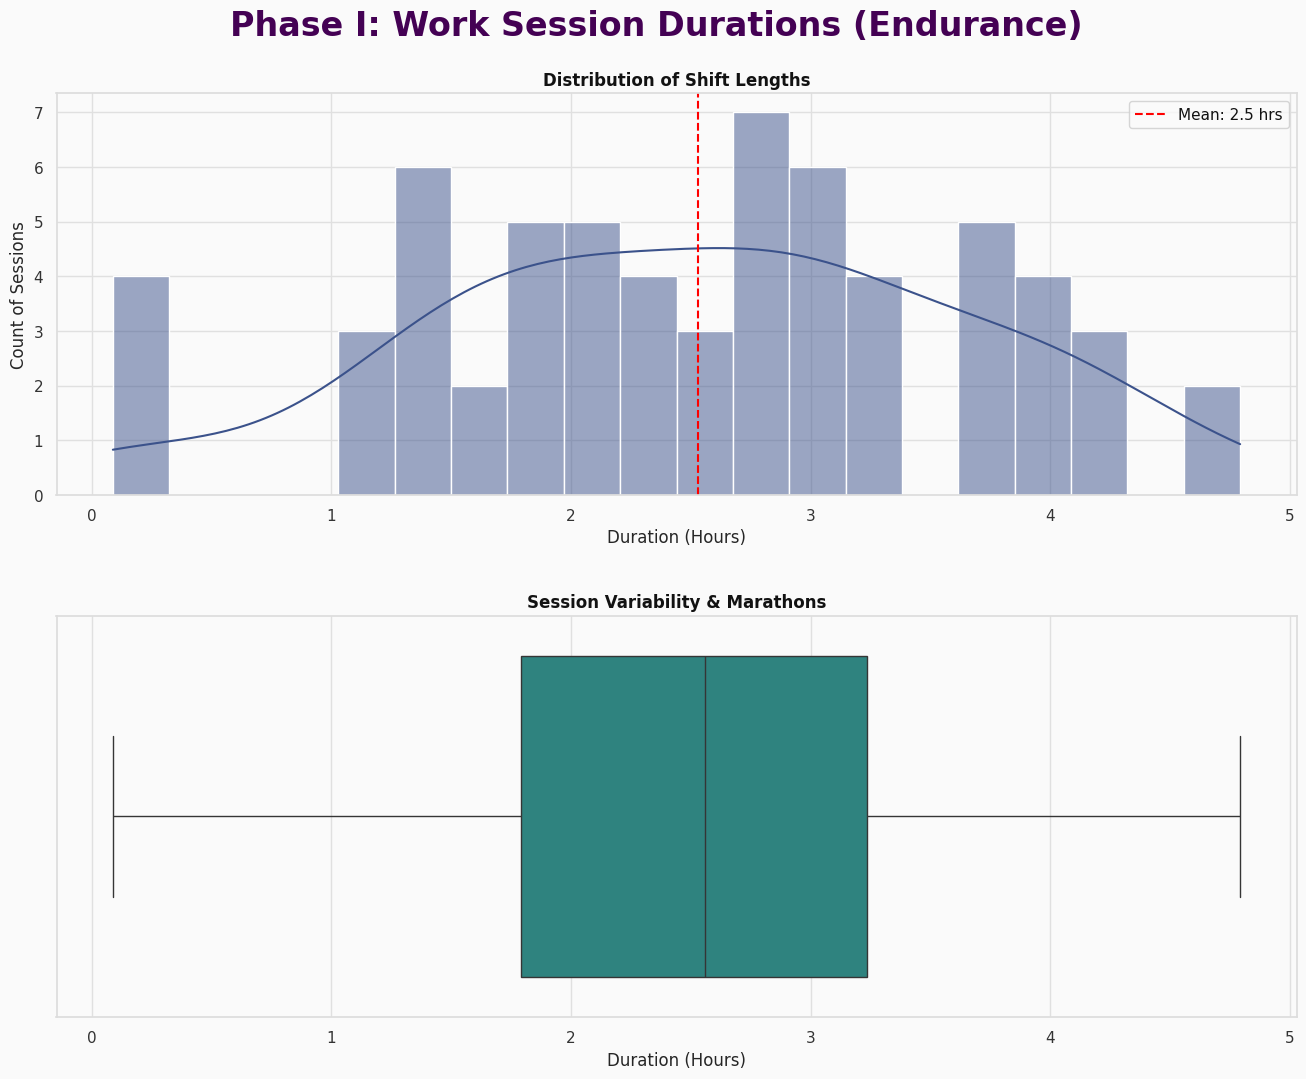

In [26]:
# ==============================================================================
# CELL 10: SESSION DURATION ANALYSIS (ENDURANCE) - CODESPACE VERSION
# ==============================================================================
# Purpose: To analyze the length of work sessions.
#          Aggregates offers by Session ID to find the total duration of each shift.
#          Displays stats in human-readable HH:MM:SS format.
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

# 1. APPLY "OPUS LAB" THEME
sns.set_theme(style="whitegrid")
opus_light_params = {
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor': '#FAFAFA',
    'text.color': '#121212',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.edgecolor': '#DDDDDD',
    'grid.color': '#E0E0E0',
    'font.family': 'sans-serif'
}
plt.rcParams.update(opus_light_params)

# 2. LOAD & AGGREGATE DATA
print("⏳ Calculating session durations...")
query = """
SELECT
    session_fk,
    MAX(time_in_session_sec) as duration_seconds
FROM offers
GROUP BY session_fk
"""
df_sessions = pd.read_sql(query, db_engine)

# Convert to Hours for Plotting
df_sessions['duration_hours'] = df_sessions['duration_seconds'] / 3600

print(f"✅ Analyzed {len(df_sessions)} unique sessions.")

# 3. HELPER FUNCTION: SECONDS -> HH:MM:SS
def seconds_to_hms(seconds):
    return time.strftime('%H:%M:%S', time.gmtime(seconds))

# 4. PLOTTING CONFIGURATION
fig, axes = plt.subplots(2, 1, figsize=(16, 12))
plt.subplots_adjust(hspace=0.3)
fig.suptitle('Phase I: Work Session Durations (Endurance)', fontsize=24, color='#440154', weight='bold', y=0.95)

# --- PLOT A: HISTOGRAM (DISTRIBUTION) ---
sns.histplot(data=df_sessions, x="duration_hours", kde=True, color="#3b528b", bins=20, ax=axes[0])
axes[0].set_title("Distribution of Shift Lengths", fontweight='bold')
axes[0].set_xlabel("Duration (Hours)")
axes[0].set_ylabel("Count of Sessions")
mean_val = df_sessions['duration_hours'].mean()
axes[0].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.1f} hrs')
axes[0].legend()

# --- PLOT B: BOXPLOT (RANGE & OUTLIERS) ---
sns.boxplot(x=df_sessions["duration_hours"], ax=axes[1], color="#21918c",
            flierprops={"marker": "d", "markerfacecolor": "black", "markersize": 5})
axes[1].set_title("Session Variability & Marathons", fontweight='bold')
axes[1].set_xlabel("Duration (Hours)")

# 5. GENERATE HUMAN-READABLE STATISTICS
print("\n--- 📊 SESSION STATISTICS (HH:MM:SS) ---")
desc = df_sessions['duration_seconds'].describe(percentiles=[0.25, 0.5, 0.75])

stats_data = {
    'Metric': ['Count', 'Min', 'Q1 (25%)', 'Median (50%)', 'Mean', 'Q3 (75%)', 'Max'],
    'Value (HH:MM:SS)': [
        int(desc['count']),
        seconds_to_hms(desc['min']),
        seconds_to_hms(desc['25%']),
        seconds_to_hms(desc['50%']),
        seconds_to_hms(desc['mean']),
        seconds_to_hms(desc['75%']),
        seconds_to_hms(desc['max'])
    ]
}

df_stats_human = pd.DataFrame(stats_data)

# CODESPACE READY:
# Se eliminó la dependencia de 'google.colab.data_table'
display(df_stats_human)

plt.show()

⏳ Loading rejection reasons...
✅ Analyzed 4419 rejection decisions.


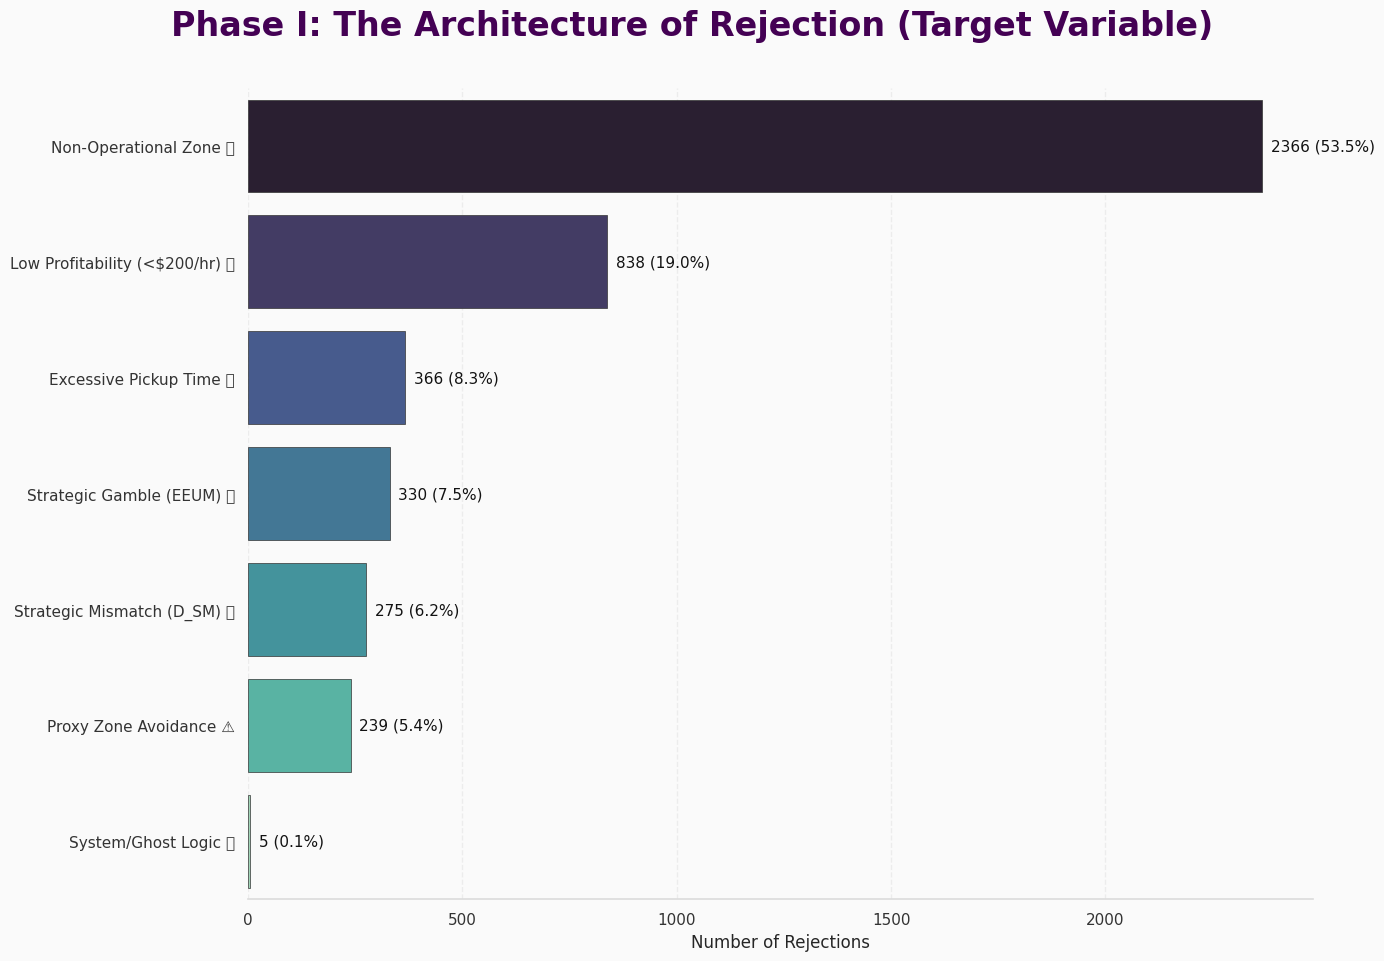

In [27]:
# ==============================================================================
# CELL 11: THE TARGET VARIABLE (REASON PRIMARY DISTRIBUTION)
# ==============================================================================
# Purpose: To visualize the "Why". This defines the Class Imbalance problem
#          we will face in Machine Learning.
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. APPLY "OPUS LAB" THEME
sns.set_theme(style="white")
opus_light_params = {
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor': '#FAFAFA',
    'text.color': '#121212',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.edgecolor': '#DDDDDD',
    'grid.color': '#E0E0E0',
    'font.family': 'sans-serif'
}
plt.rcParams.update(opus_light_params)

# 2. LOAD DATA
print("⏳ Loading rejection reasons...")
query = """
SELECT str_reason
FROM v_offers_human
WHERE str_reason IS NOT NULL -- Focus on Rejections
"""
df_reason = pd.read_sql(query, db_engine)

# 3. CALCULATE PERCENTAGES
reason_counts = df_reason['str_reason'].value_counts().reset_index()
reason_counts.columns = ['Reason', 'Count']
reason_counts['Percent'] = (reason_counts['Count'] / reason_counts['Count'].sum()) * 100

# 4. MAPPING FOR READABILITY (SNAKE_CASE -> HUMAN)
# We make it look professional for the report
label_map = {
    'dropoff_non_operational': 'Non-Operational Zone 🚫',
    'low_profitability': 'Low Profitability (<$200/hr) 📉',
    'long_pickup_time': 'Excessive Pickup Time ⏳',
    'expected_value_gamble': 'Strategic Gamble (EEUM) 🎲',
    'dropoff_strategic_mismatch': 'Strategic Mismatch (D_SM) ❌',
    'dropoff_proxy': 'Proxy Zone Avoidance ⚠️',
    'system_logic_failure': 'System/Ghost Logic 👻'
}
reason_counts['Label'] = reason_counts['Reason'].map(label_map).fillna(reason_counts['Reason'])

print(f"✅ Analyzed {len(df_reason)} rejection decisions.")

# 5. PLOTTING
fig, ax = plt.subplots(figsize=(14, 10))
fig.suptitle('Phase I: The Architecture of Rejection (Target Variable)', fontsize=24, color='#440154', weight='bold', y=0.96)

# Horizontal Bar Plot
# Using "mako" palette (Blue/Purple) to distinguish from Offers/Products
sns.barplot(x='Count', y='Label', data=reason_counts, palette="mako", ax=ax, edgecolor='#333333', linewidth=0.5)

# Aesthetics
ax.set_xlabel('Number of Rejections')
ax.set_ylabel('')
ax.grid(axis='x', linestyle='--', alpha=0.5)

# Annotate with Count AND Percentage
for i, row in reason_counts.iterrows():
    label = f"{row['Count']} ({row['Percent']:.1f}%)"
    ax.text(row['Count'] + 20, i, label, va='center', fontsize=11, fontweight='medium', color='#121212')

sns.despine(left=True, bottom=False)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

⏳ Loading categorical decision data...


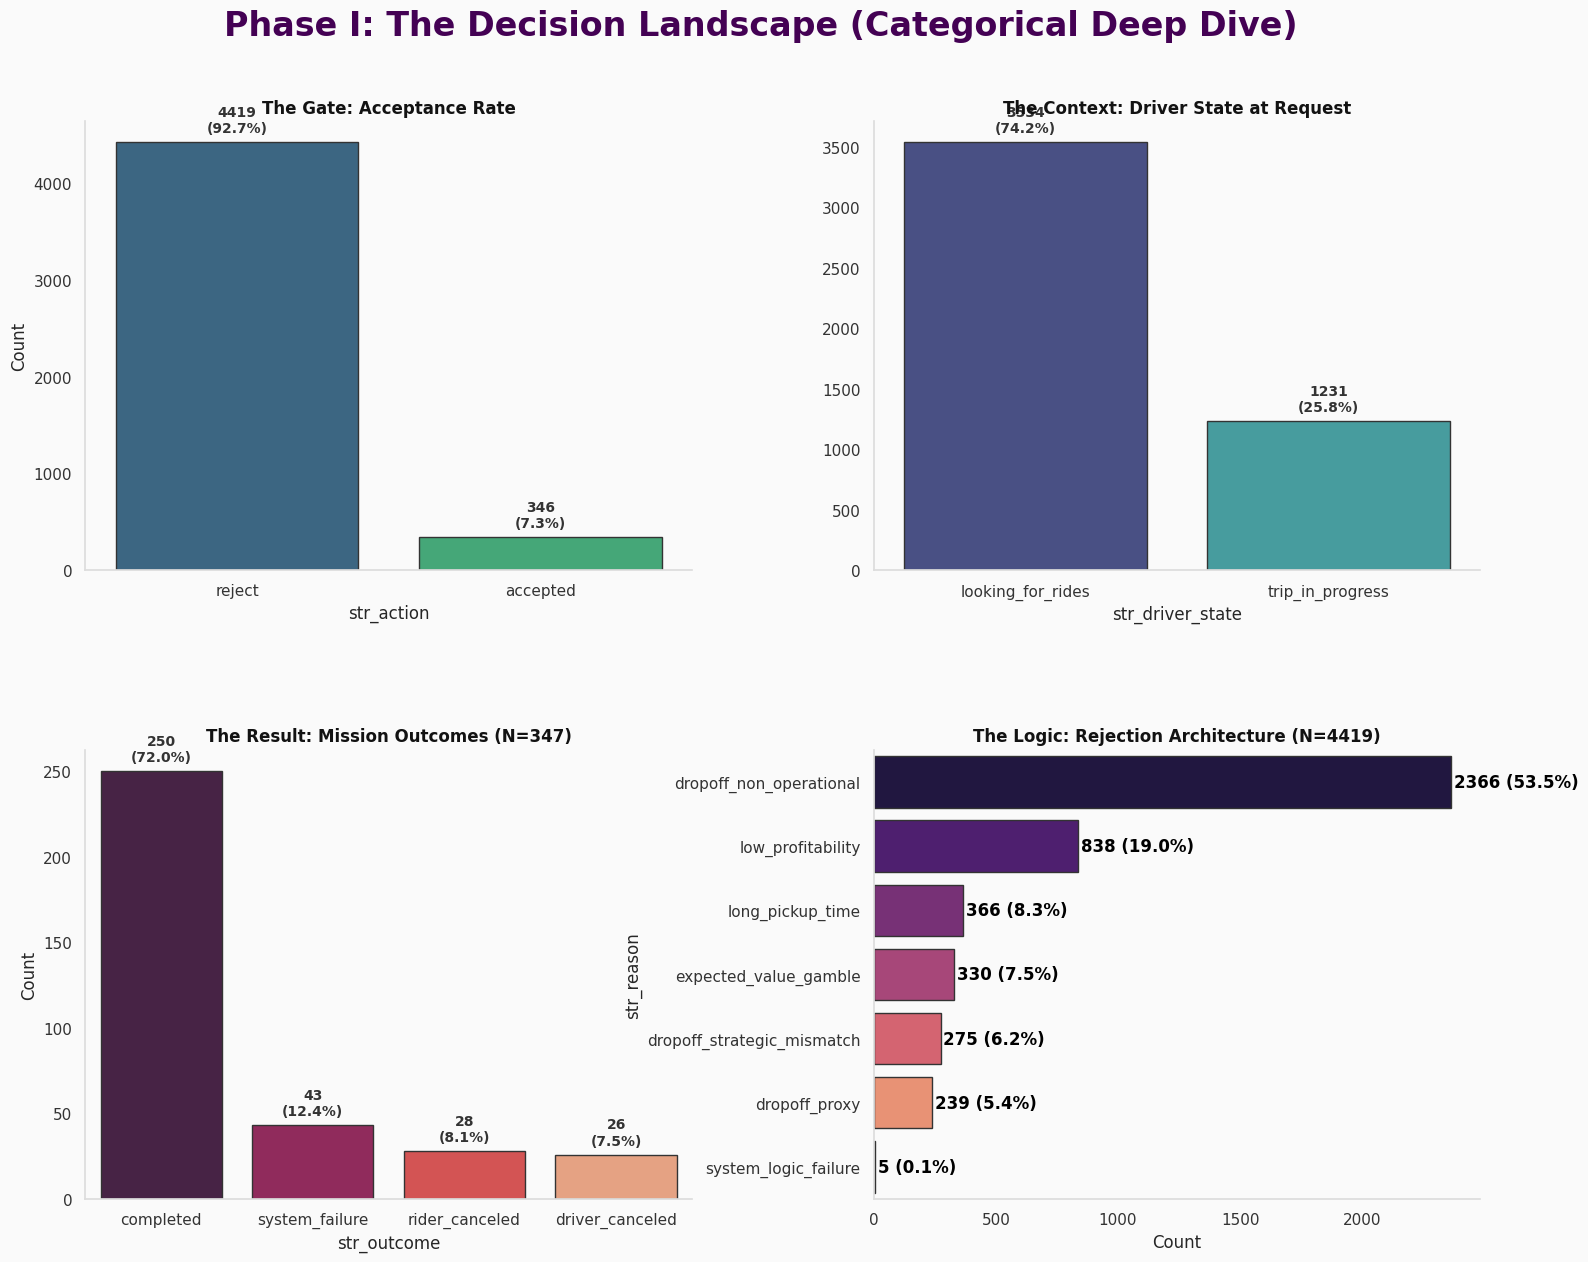

In [28]:
# ==============================================================================
# CELL 11 (FINAL): CATEGORICAL DECISION LANDSCAPE
# ==============================================================================
# Purpose: A comprehensive view of the decision pipeline.
#          1. Action (Accept/Reject)
#          2. State (Looking/On Trip)
#          3. Outcome (Completed/Canceled - Filtered for non-nulls)
#          4. Reason (The Rejection Architecture)
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. APPLY "OPUS LAB" THEME
sns.set_theme(style="white")
opus_light_params = {
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor': '#FAFAFA',
    'text.color': '#121212',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.edgecolor': '#DDDDDD',
    'grid.color': '#E0E0E0',
    'font.family': 'sans-serif'
}
plt.rcParams.update(opus_light_params)

# 2. LOAD DATA
print("⏳ Loading categorical decision data...")
query = """
SELECT
    str_action,
    str_driver_state,
    str_outcome,
    str_reason
FROM v_offers_human
"""
df_cat = pd.read_sql(query, db_engine)

# 3. PLOTTING CONFIGURATION
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
plt.subplots_adjust(hspace=0.4, wspace=0.3)
fig.suptitle('Phase I: The Decision Landscape (Categorical Deep Dive)', fontsize=24, color='#440154', weight='bold', y=0.96)

# --- HELPER FUNCTION FOR ANNOTATION ---
def annotate_bars(ax, total_count):
    for p in ax.patches:
        percentage = '{:.1f}%'.format(100 * p.get_height() / total_count)
        count = int(p.get_height())
        # Determine text color based on bar height (optional, stick to black for readability on light theme)
        ax.annotate(f'{count}\n({percentage})', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', xytext=(0, 5), textcoords='offset points',
                    fontsize=10, fontweight='bold', color='#333333')

# --- PLOT 1: THE GATE (ACTION) ---
ax1 = axes[0, 0]
counts_action = df_cat['str_action'].value_counts()
sns.barplot(x=counts_action.index, y=counts_action.values, ax=ax1, palette="viridis", edgecolor='#333333')
ax1.set_title("The Gate: Acceptance Rate", fontweight='bold')
ax1.set_ylabel('Count')
annotate_bars(ax1, len(df_cat))

# --- PLOT 2: THE CONTEXT (DRIVER STATE) ---
ax2 = axes[0, 1]
counts_state = df_cat['str_driver_state'].value_counts()
sns.barplot(x=counts_state.index, y=counts_state.values, ax=ax2, palette="mako", edgecolor='#333333')
ax2.set_title("The Context: Driver State at Request", fontweight='bold')
ax2.set_ylabel('')
annotate_bars(ax2, len(df_cat))

# --- PLOT 3: THE RESULT (OUTCOME - Active Only) ---
ax3 = axes[1, 0]
# Filter out NULL outcomes (Rejections) to see only what happened to Accepted trips
df_outcome_valid = df_cat[df_cat['str_outcome'].notna()]
counts_outcome = df_outcome_valid['str_outcome'].value_counts()

sns.barplot(x=counts_outcome.index, y=counts_outcome.values, ax=ax3, palette="rocket", edgecolor='#333333')
ax3.set_title(f"The Result: Mission Outcomes (N={len(df_outcome_valid)})", fontweight='bold')
ax3.set_ylabel('Count')
annotate_bars(ax3, len(df_outcome_valid))

# --- PLOT 4: THE WHY (REJECTION REASON) ---
ax4 = axes[1, 1]
# Filter for rejections only
df_reason_valid = df_cat[df_cat['str_reason'].notna()]
counts_reason = df_reason_valid['str_reason'].value_counts()

# Use Horizontal bar for readability of long labels
sns.barplot(x=counts_reason.values, y=counts_reason.index, ax=ax4, palette="magma", edgecolor='#333333')
ax4.set_title(f"The Logic: Rejection Architecture (N={len(df_reason_valid)})", fontweight='bold')
ax4.set_xlabel('Count')

# Horizontal annotation
total_rejections = len(df_reason_valid)
for i, v in enumerate(counts_reason.values):
    pct = (v / total_rejections) * 100
    ax4.text(v + 10, i, f"{v} ({pct:.1f}%)", color='black', fontweight='bold', va='center')

sns.despine()
plt.show()

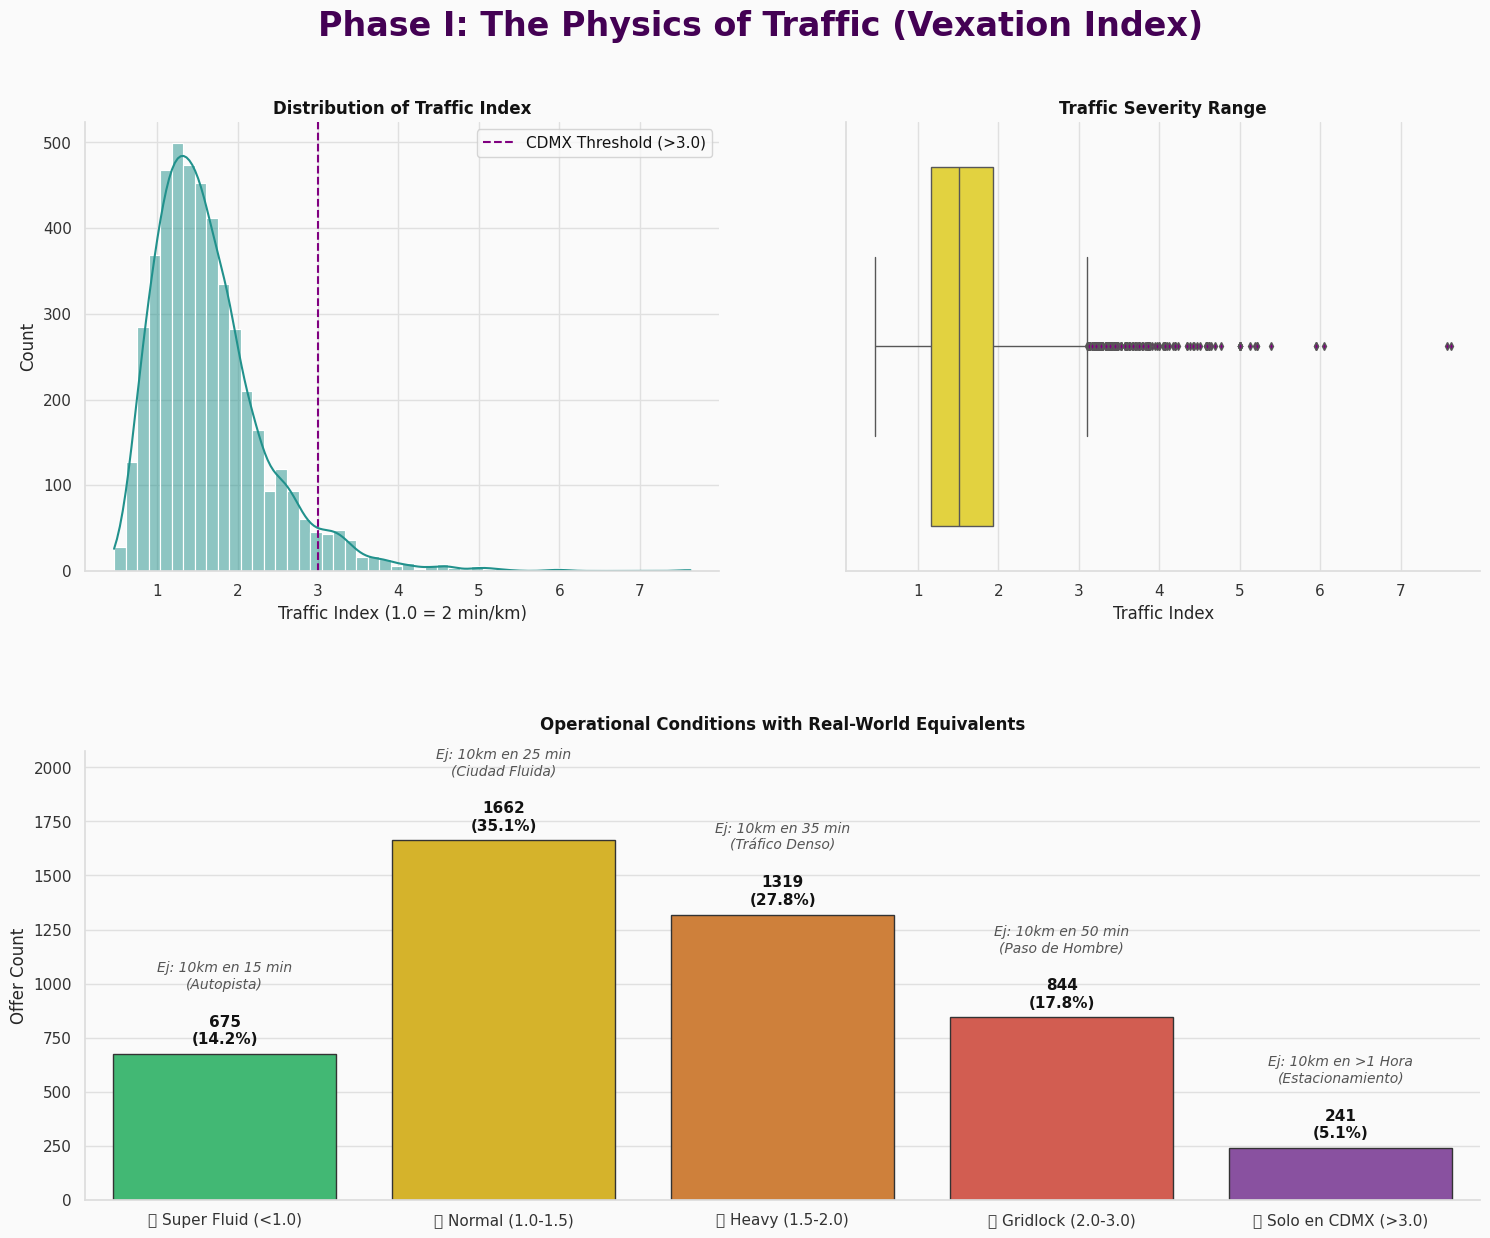

In [29]:
# ==============================================================================
# CELL 13 (FINAL): TRAFFIC VEXATION INDEX (WITH REAL-WORLD CONTEXT)
# ==============================================================================
# Purpose: Univariate analysis of 'traffic_index_base_120'.
#          Adds explicit "Real World Examples" to contextualize the math.
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. APPLY "OPUS LAB" THEME
sns.set_theme(style="whitegrid")
opus_light_params = {
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor': '#FAFAFA',
    'text.color': '#121212',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.edgecolor': '#DDDDDD',
    'grid.color': '#E0E0E0',
    'font.family': 'sans-serif'
}
plt.rcParams.update(opus_light_params)

# 2. LOAD DATA
query = """
SELECT traffic_index_base_120
FROM engineered_features
WHERE traffic_index_base_120 IS NOT NULL
"""
df_traffic = pd.read_sql(query, db_engine)
df_traffic = df_traffic[df_traffic['traffic_index_base_120'] < 10]

# 3. FEATURE ENGINEERING (CLASSES)
conditions = [
    (df_traffic['traffic_index_base_120'] < 1.0),
    (df_traffic['traffic_index_base_120'] >= 1.0) & (df_traffic['traffic_index_base_120'] < 1.5),
    (df_traffic['traffic_index_base_120'] >= 1.5) & (df_traffic['traffic_index_base_120'] < 2.0),
    (df_traffic['traffic_index_base_120'] >= 2.0) & (df_traffic['traffic_index_base_120'] < 3.0),
    (df_traffic['traffic_index_base_120'] >= 3.0)
]
choices = [
    '🟢 Super Fluid (<1.0)',
    '🟡 Normal (1.0-1.5)',
    '🟠 Heavy (1.5-2.0)',
    '🔴 Gridlock (2.0-3.0)',
    '🟣 Solo en CDMX (>3.0)'
]
df_traffic['traffic_class'] = np.select(conditions, choices, default='Unknown')

# 4. PLOTTING CONFIGURATION
fig, axes = plt.subplots(2, 2, figsize=(18, 14)) # Increased height for labels
gs = axes[1, 0].get_gridspec()
for ax in axes[1, :]:
    ax.remove()
ax_big = fig.add_subplot(gs[1, :])

fig.suptitle('Phase I: The Physics of Traffic (Vexation Index)', fontsize=24, color='#440154', weight='bold', y=0.96)

# --- PLOT A: HISTOGRAM ---
sns.histplot(df_traffic['traffic_index_base_120'], kde=True, bins=50, color="#21918c", ax=axes[0, 0])
axes[0, 0].set_title("Distribution of Traffic Index", fontweight='bold')
axes[0, 0].set_xlabel("Traffic Index (1.0 = 2 min/km)")
axes[0, 0].axvline(3.0, color='purple', linestyle='--', label='CDMX Threshold (>3.0)')
axes[0, 0].legend()

# --- PLOT B: BOXPLOT ---
sns.boxplot(x=df_traffic['traffic_index_base_120'], ax=axes[0, 1], color="#fde725",
            flierprops={"marker": "d", "markerfacecolor": "purple", "markersize": 4})
axes[0, 1].set_title("Traffic Severity Range", fontweight='bold')
axes[0, 1].set_xlabel("Traffic Index")

# --- PLOT C: THE SEMAPHOR WITH CONTEXT ---
order = choices
palette = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#8e44ad']

sns.countplot(x='traffic_class', data=df_traffic, order=order, palette=palette, ax=ax_big, edgecolor='#333333')
ax_big.set_title("Operational Conditions with Real-World Equivalents", fontweight='bold', pad=15)
ax_big.set_xlabel('')
ax_big.set_ylabel('Offer Count')

# --- THE "REAL WORLD" ANCHORS ---
# Examples calculated based on a 10km Trip
examples = [
    "Ej: 10km en 15 min\n(Autopista)",       # Fluid
    "Ej: 10km en 25 min\n(Ciudad Fluida)",   # Normal
    "Ej: 10km en 35 min\n(Tráfico Denso)",   # Heavy
    "Ej: 10km en 50 min\n(Paso de Hombre)",  # Gridlock
    "Ej: 10km en >1 Hora\n(Estacionamiento)" # Solo en CDMX
]

# Annotate Bars
total = len(df_traffic)
# Adjust Y-Limit to make room for the floating text
ax_big.set_ylim(0, df_traffic['traffic_class'].value_counts().max() * 1.25)

for i, p in enumerate(ax_big.patches):
    # 1. The Count & Percentage (Inside/On Bar)
    percentage = '{:.1f}%'.format(100 * p.get_height() / total)
    count_text = f'{int(p.get_height())}\n({percentage})'
    ax_big.annotate(count_text, (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', xytext=(0, 5), textcoords='offset points',
                    fontweight='bold', fontsize=11, color='#121212')

    # 2. The Real World Example (Floating Above)
    # Only add if index is within range (safety check)
    if i < len(examples):
        ax_big.annotate(examples[i], (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='bottom', xytext=(0, 45), textcoords='offset points',
                        fontweight='normal', fontsize=10, color='#555555', style='italic')

sns.despine()
plt.subplots_adjust(hspace=0.4)
plt.show()

⏳ Loading market pulse data...
✅ Analyzed 4458 pulse records.


/usr/local/python/3.12.1/lib/python3.12/site-packages/pandas/core/nanops.py:1027: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


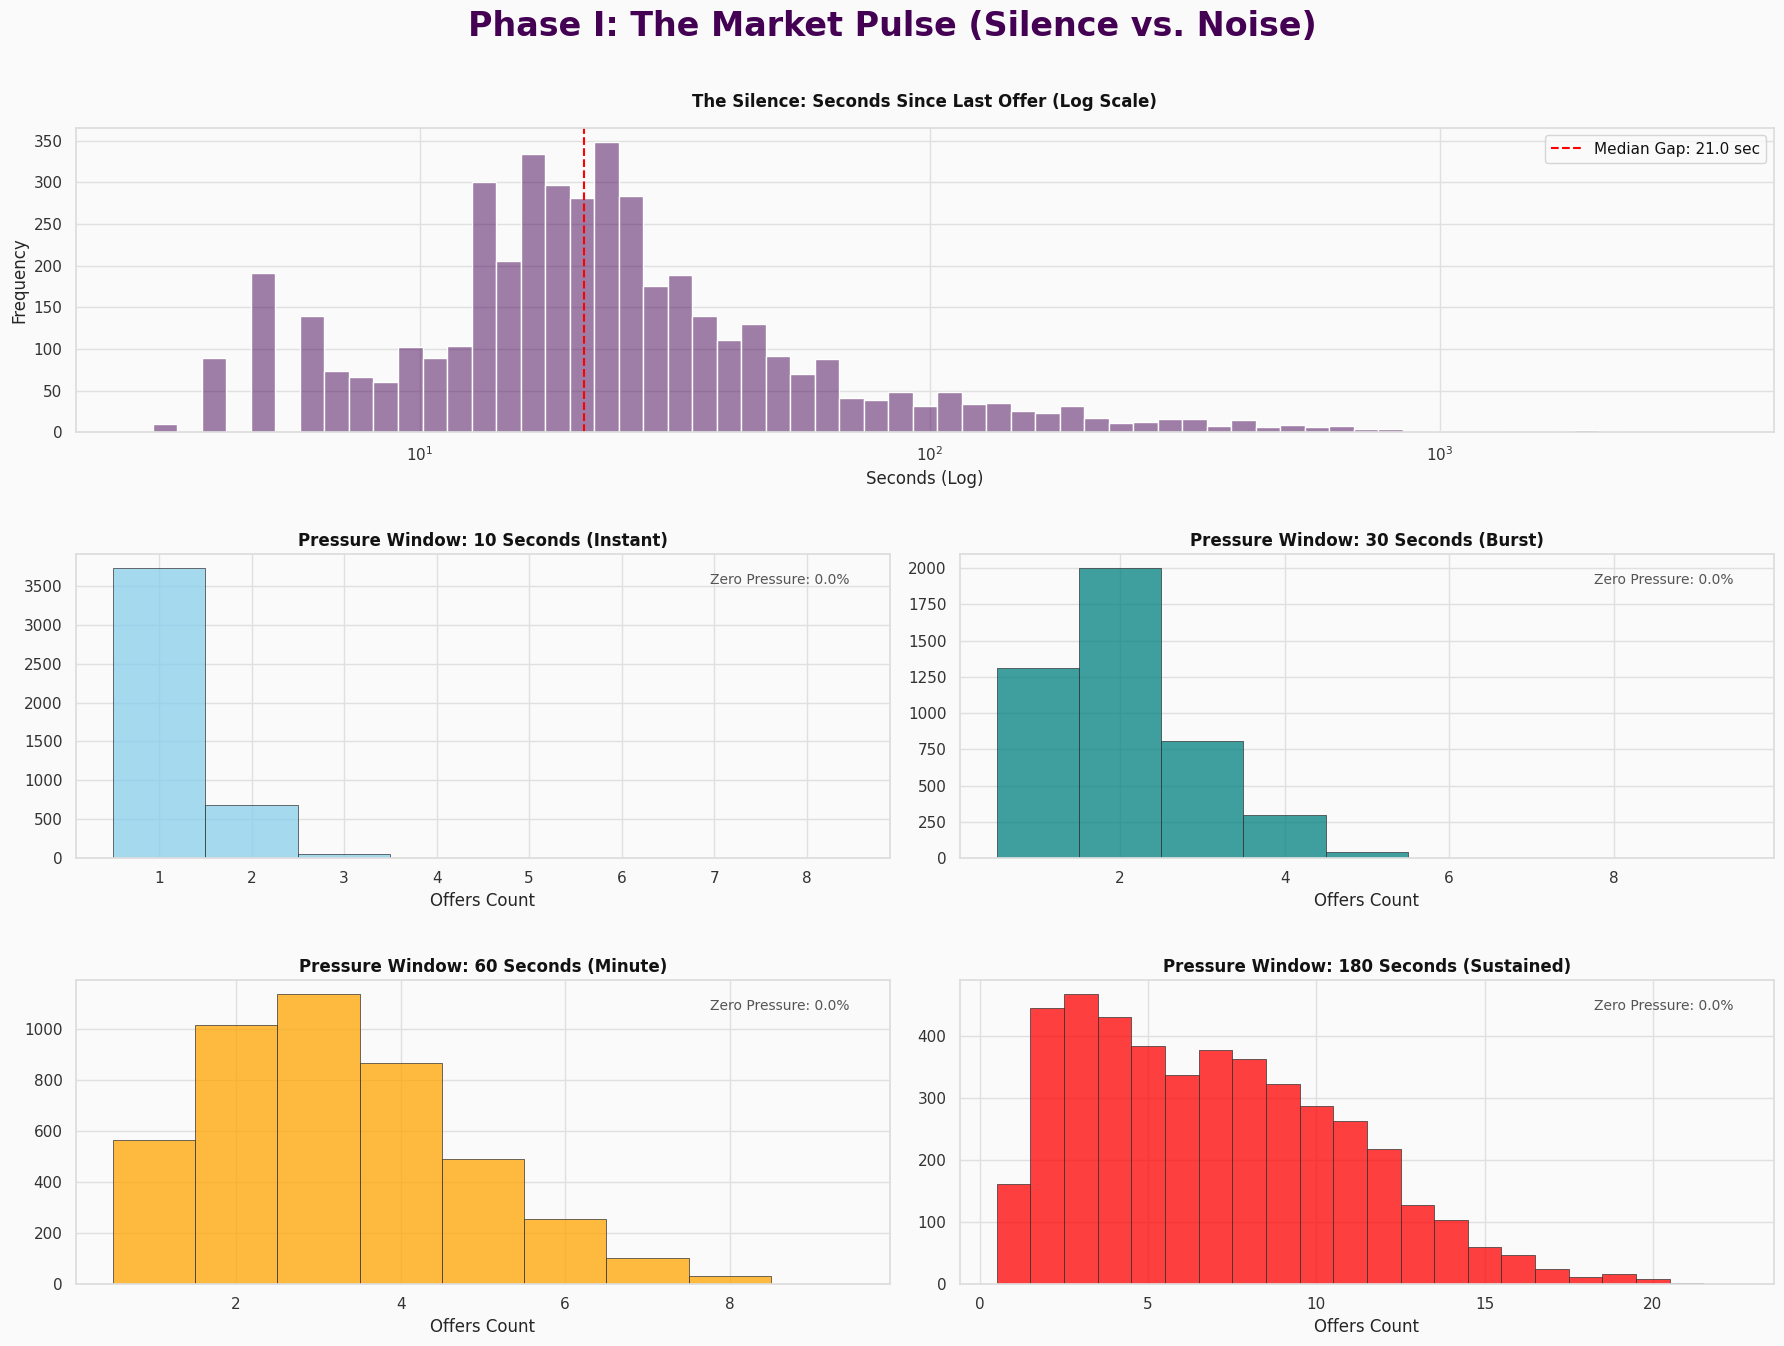

In [30]:
# ==============================================================================
# CELL 14: MARKET PULSE (TIME GAPS & OFFER DENSITY)
# ==============================================================================
# Purpose: To visualize the rhythm of the market.
#          1. Time Since Last Offer (The Silence/Patience).
#          2. Offer Density Windows (The Pressure/Noise).
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. APPLY "OPUS LAB" THEME
sns.set_theme(style="whitegrid")
opus_light_params = {
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor': '#FAFAFA',
    'text.color': '#121212',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.edgecolor': '#DDDDDD',
    'grid.color': '#E0E0E0',
    'font.family': 'sans-serif'
}
plt.rcParams.update(opus_light_params)

# 2. LOAD DATA
print("⏳ Loading market pulse data...")
query = """
SELECT
    time_since_last_offer,
    offer_density_10sec,
    offer_density_30sec,
    offer_density_60sec,
    offer_density_180sec
FROM engineered_features
WHERE time_since_last_offer IS NOT NULL
"""
df_pulse = pd.read_sql(query, db_engine)

# Filter out the first offer of each session (which has huge gaps) for cleaner viz
# Assuming gaps > 1 hour (3600s) are session breaks
df_pulse = df_pulse[df_pulse['time_since_last_offer'] < 3600]

print(f"✅ Analyzed {len(df_pulse)} pulse records.")

# 3. PLOTTING CONFIGURATION
fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(3, 2) # 3 Rows
fig.suptitle('Phase I: The Market Pulse (Silence vs. Noise)', fontsize=24, color='#440154', weight='bold', y=0.96)

# --- ROW 1: THE SILENCE (Time Since Last Offer) ---
ax1 = fig.add_subplot(gs[0, :]) # Span full width
sns.histplot(df_pulse['time_since_last_offer'], kde=True, color="#440154", log_scale=True, ax=ax1)
ax1.set_title("The Silence: Seconds Since Last Offer (Log Scale)", fontweight='bold', pad=15)
ax1.set_xlabel("Seconds (Log)")
ax1.set_ylabel("Frequency")
# Add median line
med_gap = df_pulse['time_since_last_offer'].median()
ax1.axvline(med_gap, color='red', linestyle='--', label=f'Median Gap: {med_gap:.1f} sec')
ax1.legend()

# --- ROWS 2 & 3: THE NOISE (Density Windows) ---
# We plot 4 densities to see the "Pressure Cooker" effect
densities = [
    (1, 0, 'offer_density_10sec', '10 Seconds (Instant)', 'skyblue'),
    (1, 1, 'offer_density_30sec', '30 Seconds (Burst)', 'teal'),
    (2, 0, 'offer_density_60sec', '60 Seconds (Minute)', 'orange'),
    (2, 1, 'offer_density_180sec', '180 Seconds (Sustained)', 'red')
]

for r, c, col, title, color in densities:
    ax = fig.add_subplot(gs[r, c])
    # Discrete histograms for counts
    max_val = df_pulse[col].max()
    bins = range(0, int(max_val) + 2) # Discrete bins
    sns.histplot(df_pulse[col], bins=bins, color=color, ax=ax, edgecolor='#333333', linewidth=0.5, discrete=True)

    ax.set_title(f"Pressure Window: {title}", fontweight='bold')
    ax.set_xlabel("Offers Count")
    ax.set_ylabel("")

    # Annotate Zero-Pressure vs High-Pressure
    zero_pct = (df_pulse[col] == 0).mean() * 100
    ax.text(0.95, 0.9, f"Zero Pressure: {zero_pct:.1f}%", transform=ax.transAxes, ha='right', fontsize=10, color='#555555')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.subplots_adjust(hspace=0.4)
plt.show()

⏳ Building Universes via Direct Join...
✅ Universes Created. Fast: 138. Slow: 4322.


/usr/local/python/3.12.1/lib/python3.12/site-packages/pandas/core/nanops.py:1027: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


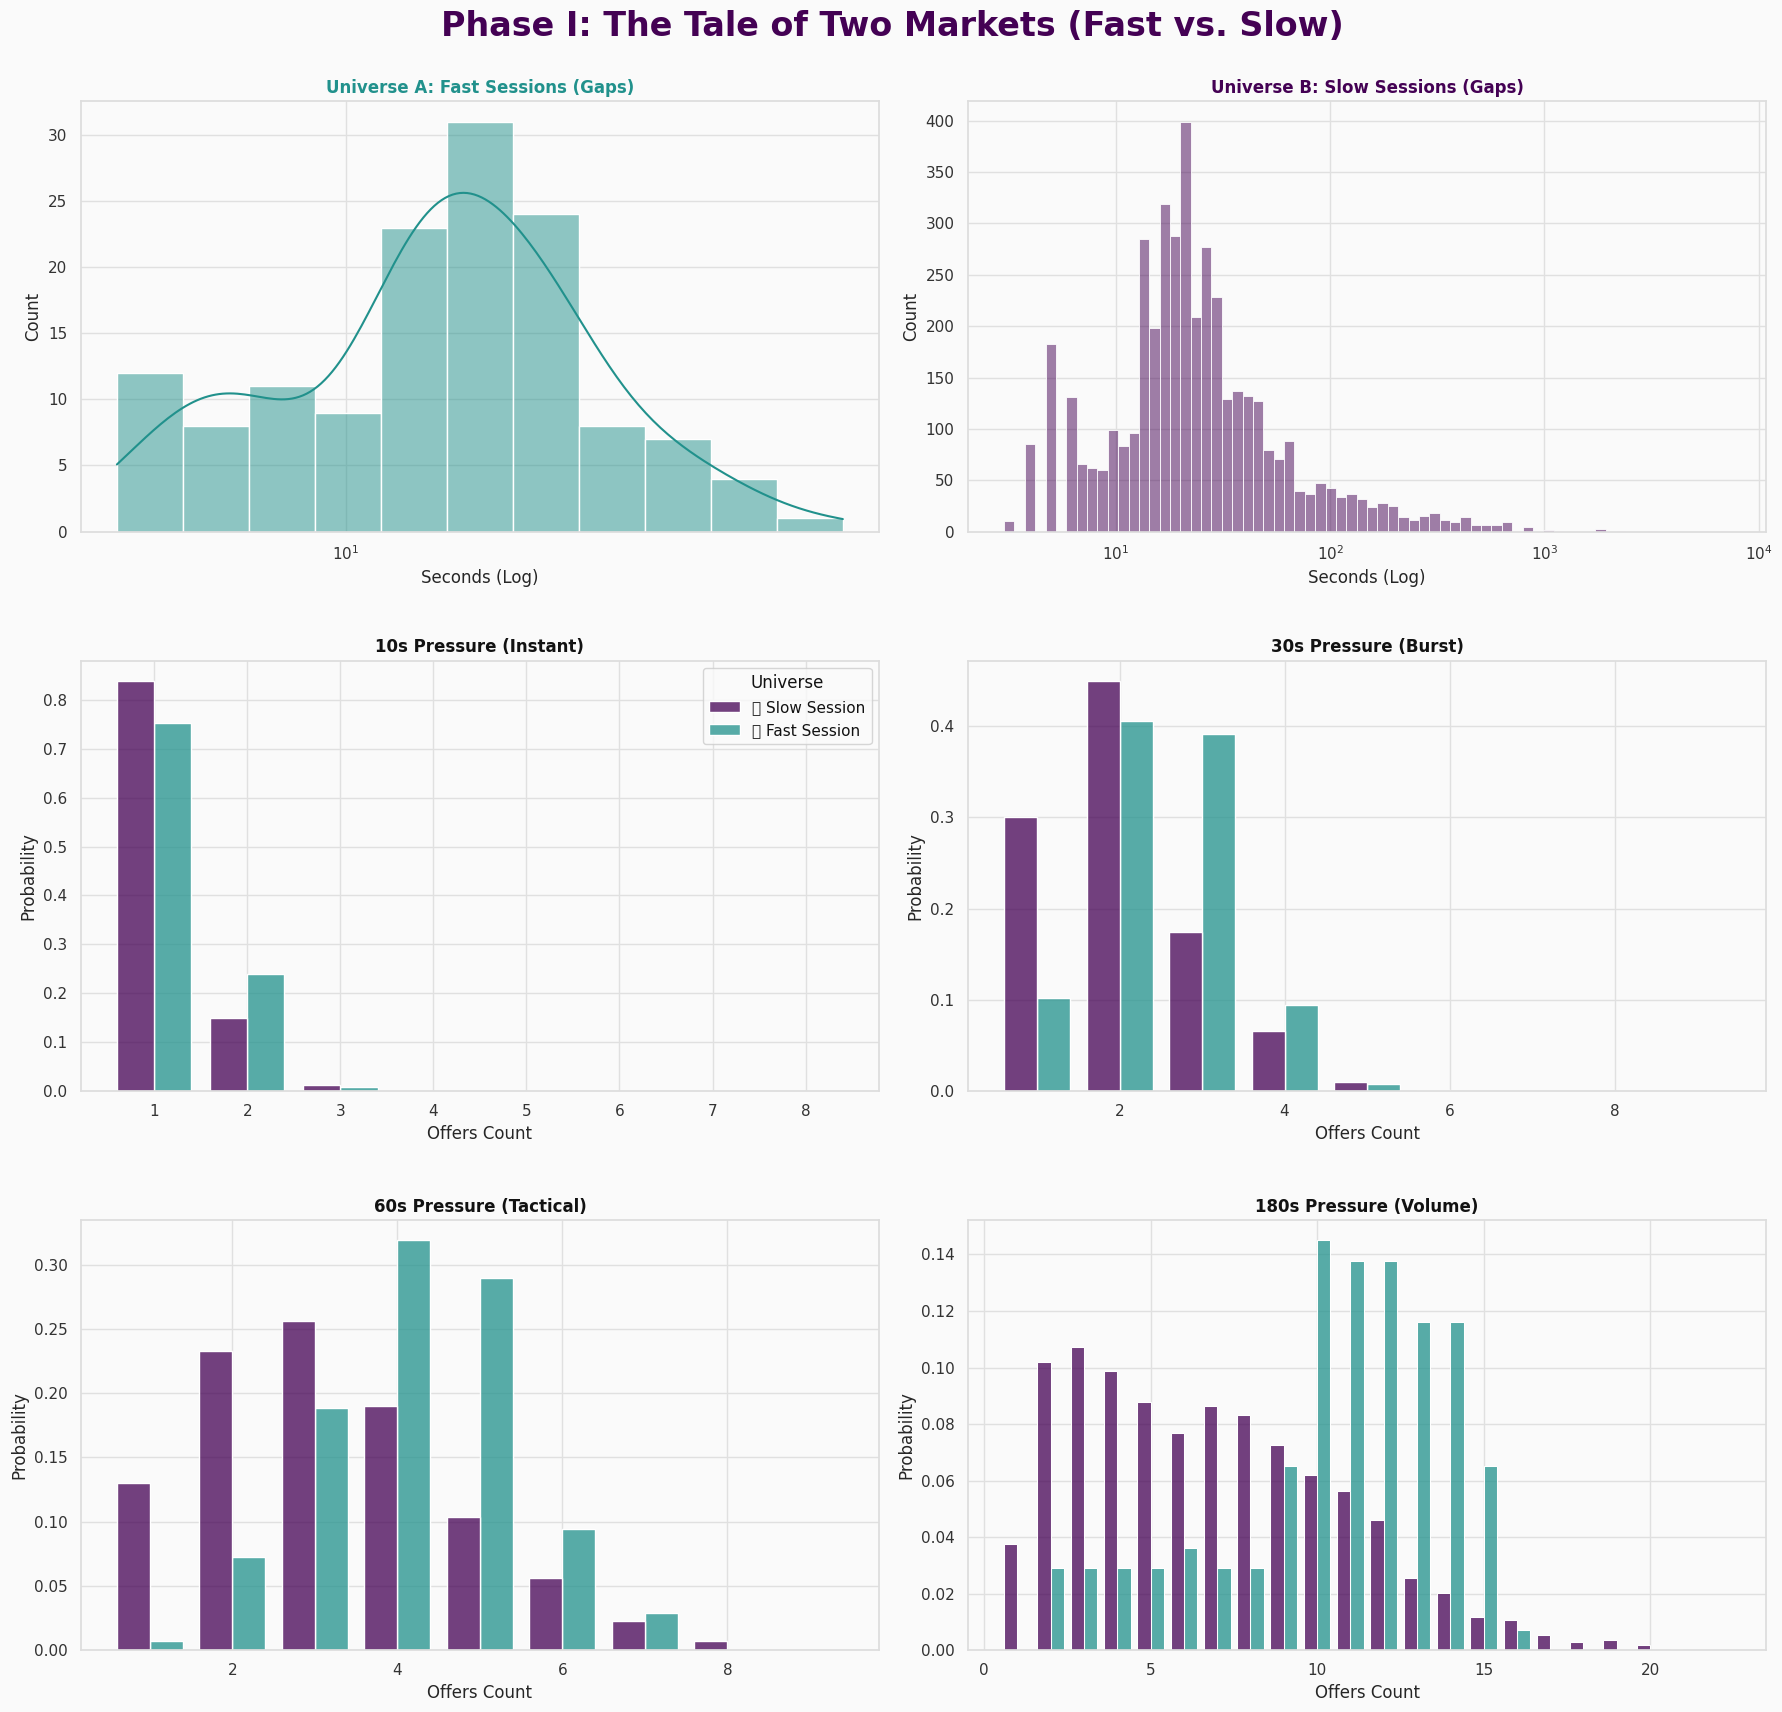

In [32]:
# ==============================================================================
# CELL 15 (REVISED v4): THE DUAL UNIVERSE (FIXED VIA DIRECT JOIN)
# ==============================================================================
# Purpose: Comprehensive comparison of High vs. Low Velocity sessions.
#          Bypasses 'v_offers_human' view to access all density columns directly.
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. APPLY "OPUS LAB" THEME
sns.set_theme(style="whitegrid")
opus_light_params = {
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor': '#FAFAFA',
    'text.color': '#121212',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.edgecolor': '#DDDDDD',  # <--- Corregido: sin el espacio
    'grid.color': '#E0E0E0',
    'font.family': 'sans-serif'
}
plt.rcParams.update(opus_light_params)

# 2. DATA ENGINEERING (DIRECT TABLE JOIN)
print("⏳ Building Universes via Direct Join...")

# We join 'offers' (for session_fk) with 'engineered_features' (for all densities)
query = """
SELECT
    o.session_fk,
    ef.time_since_last_offer,
    ef.offer_density_10sec,
    ef.offer_density_30sec,
    ef.offer_density_60sec,
    ef.offer_density_180sec
FROM offers o
LEFT JOIN engineered_features ef ON o.offer_id = ef.offer_id_fk
WHERE ef.time_since_last_offer IS NOT NULL
"""
df_pulse = pd.read_sql(query, db_engine)

# Calculate Session Velocity
session_stats = df_pulse.groupby('session_fk')['time_since_last_offer'].mean().reset_index()
THRESHOLD = 21.0

# Create the 'Universe' Label
fast_ids = session_stats[session_stats['avg_session_gap'] <= THRESHOLD]['session_fk'] if 'avg_session_gap' in session_stats.columns else session_stats[session_stats.iloc[:,1] <= THRESHOLD]['session_fk'] # Safely access mean column

df_pulse['Universe'] = df_pulse['session_fk'].apply(lambda x: '🚀 Fast Session' if x in fast_ids.values else '🐢 Slow Session')

print(f"✅ Universes Created. Fast: {len(df_pulse[df_pulse['Universe'].str.contains('Fast')])}. Slow: {len(df_pulse[df_pulse['Universe'].str.contains('Slow')])}.")

# 3. PLOTTING CONFIGURATION
fig = plt.figure(figsize=(18, 18))
gs = fig.add_gridspec(3, 2)
fig.suptitle('Phase I: The Tale of Two Markets (Fast vs. Slow)', fontsize=24, color='#440154', weight='bold', y=0.95)

# --- ROW 1: THE SILENCE (TIME GAPS) ---
ax1 = fig.add_subplot(gs[0, 0])
sns.histplot(data=df_pulse[df_pulse['Universe'].str.contains('Fast')], x='time_since_last_offer',
             kde=True, color="#21918c", log_scale=True, ax=ax1)
ax1.set_title("Universe A: Fast Sessions (Gaps)", fontweight='bold', color='#21918c')
ax1.set_xlabel("Seconds (Log)")

ax2 = fig.add_subplot(gs[0, 1])
sns.histplot(data=df_pulse[df_pulse['Universe'].str.contains('Slow')], x='time_since_last_offer',
             kde=True, color="#440154", log_scale=True, ax=ax2)
ax2.set_title("Universe B: Slow Sessions (Gaps)", fontweight='bold', color='#440154')
ax2.set_xlabel("Seconds (Log)")

# --- ROWS 2 & 3: THE PRESSURE (DENSITIES) ---
densities = [
    (1, 0, 'offer_density_10sec', '10s Pressure (Instant)'),
    (1, 1, 'offer_density_30sec', '30s Pressure (Burst)'),
    (2, 0, 'offer_density_60sec', '60s Pressure (Tactical)'),
    (2, 1, 'offer_density_180sec', '180s Pressure (Volume)')
]

for r, c, col, title in densities:
    ax = fig.add_subplot(gs[r, c])

    # Check if column exists to avoid errors if DB schema varies
    if col in df_pulse.columns:
        sns.histplot(data=df_pulse, x=col, hue='Universe',
                     palette={'🚀 Fast Session': '#21918c', '🐢 Slow Session': '#440154'},
                     multiple="dodge", shrink=0.8, discrete=True, stat='probability', common_norm=False, ax=ax)

        ax.set_title(title, fontweight='bold')
        ax.set_xlabel("Offers Count")
        ax.set_ylabel("Probability")

        if (r, c) == (1, 0):
            sns.move_legend(ax, "upper right")
        else:
            ax.get_legend().remove()
    else:
        ax.text(0.5, 0.5, f"Column {col} Missing", ha='center')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.subplots_adjust(hspace=0.3)
plt.show()

--- 🧪 THE ACID TEST (Kolmogorov-Smirnov) ---
KS Statistic: 0.4771
P-Value:      0.000000000000000000000000000193

✅ RESULT: STATISTICALLY SIGNIFICANT DIFFERENCE.
   The 'Fast' and 'Slow' markets are governed by different probability distributions.
   Strategic implication: A single policy cannot fit both.

--- 📊 SHAPE METRICS (180s Volume) ---
🚀 FAST Universe | Mean Vol: 10.49 | Max Vol: 16.0
🐢 SLOW Universe | Mean Vol: 6.81 | Max Vol: 22.0


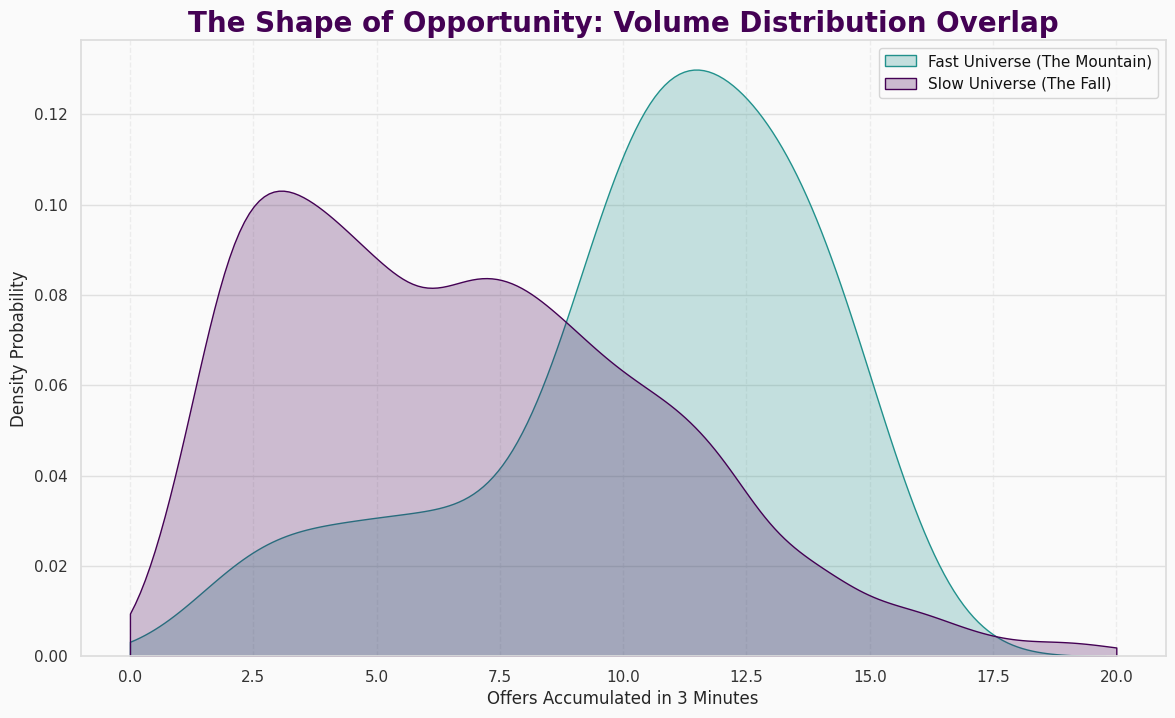

In [33]:
# ==============================================================================
# CELL 16: STATISTICAL VALIDATION (THE ACID TEST)
# ==============================================================================
# Purpose: To rigorously prove that "Fast" and "Slow" sessions are statistically
#          distinct populations, justifying different strategic policies.
#          Method: Kolmogorov-Smirnov (KS) Test on Offer Density (180s).
# ==============================================================================

from scipy import stats
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. RE-CREATE UNIVERSES (Data Consistency)
query = """
SELECT
    o.session_fk,
    ef.time_since_last_offer,
    ef.offer_density_180sec
FROM offers o
LEFT JOIN engineered_features ef ON o.offer_id = ef.offer_id_fk
WHERE ef.time_since_last_offer IS NOT NULL
"""
df_pulse = pd.read_sql(query, db_engine)

# Logic: Session Avg Gap
session_stats = df_pulse.groupby('session_fk')['time_since_last_offer'].mean().reset_index()
THRESHOLD = 21.0
fast_ids = session_stats[session_stats.iloc[:,1] <= THRESHOLD]['session_fk'] # Safe col access

# Split Populations based on VOLUME (180s Density)
# We want to compare the "Accumulation Power" of both universes
pop_fast = df_pulse[df_pulse['session_fk'].isin(fast_ids)]['offer_density_180sec']
pop_slow = df_pulse[~df_pulse['session_fk'].isin(fast_ids)]['offer_density_180sec']

# 2. THE STATISTICAL TEST (KS-TEST)
# Null Hypothesis: The two distributions are identical.
ks_stat, p_value = stats.ks_2samp(pop_fast, pop_slow)

# Descriptive Stats for context
desc_fast = pop_fast.describe()
desc_slow = pop_slow.describe()

print(f"--- 🧪 THE ACID TEST (Kolmogorov-Smirnov) ---")
print(f"KS Statistic: {ks_stat:.4f}")
print(f"P-Value:      {p_value:.30f}") # Force full decimal display

if p_value < 0.05:
    print("\n✅ RESULT: STATISTICALLY SIGNIFICANT DIFFERENCE.")
    print("   The 'Fast' and 'Slow' markets are governed by different probability distributions.")
    print("   Strategic implication: A single policy cannot fit both.")
else:
    print("\n❌ RESULT: NO SIGNIFICANT DIFFERENCE.")

print(f"\n--- 📊 SHAPE METRICS (180s Volume) ---")
print(f"🚀 FAST Universe | Mean Vol: {desc_fast['mean']:.2f} | Max Vol: {desc_fast['max']}")
print(f"🐢 SLOW Universe | Mean Vol: {desc_slow['mean']:.2f} | Max Vol: {desc_slow['max']}")

# 3. VISUAL PROOF (KDE OVERLAY)
# Shows the "Mountain" vs the "Fall" clearly overlapping
plt.figure(figsize=(14, 8))
sns.kdeplot(pop_fast, fill=True, color="#21918c", label="Fast Universe (The Mountain)", clip=(0, 20))
sns.kdeplot(pop_slow, fill=True, color="#440154", label="Slow Universe (The Fall)", clip=(0, 20))

plt.title("The Shape of Opportunity: Volume Distribution Overlap", fontsize=20, fontweight='bold', color='#440154')
plt.xlabel("Offers Accumulated in 3 Minutes")
plt.ylabel("Density Probability")
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

⏳ Loading cycle data...
✅ Analyzed 346 completed cycles (Accepted Rides).

--- 📊 THE REAL COST OF WAITING ---


,count,min,25%,50%,75%,90%,max,mean
consecutive_rejects,346.0,0.0,2.0,6.5,15.0,26.0,102.0,11.052023


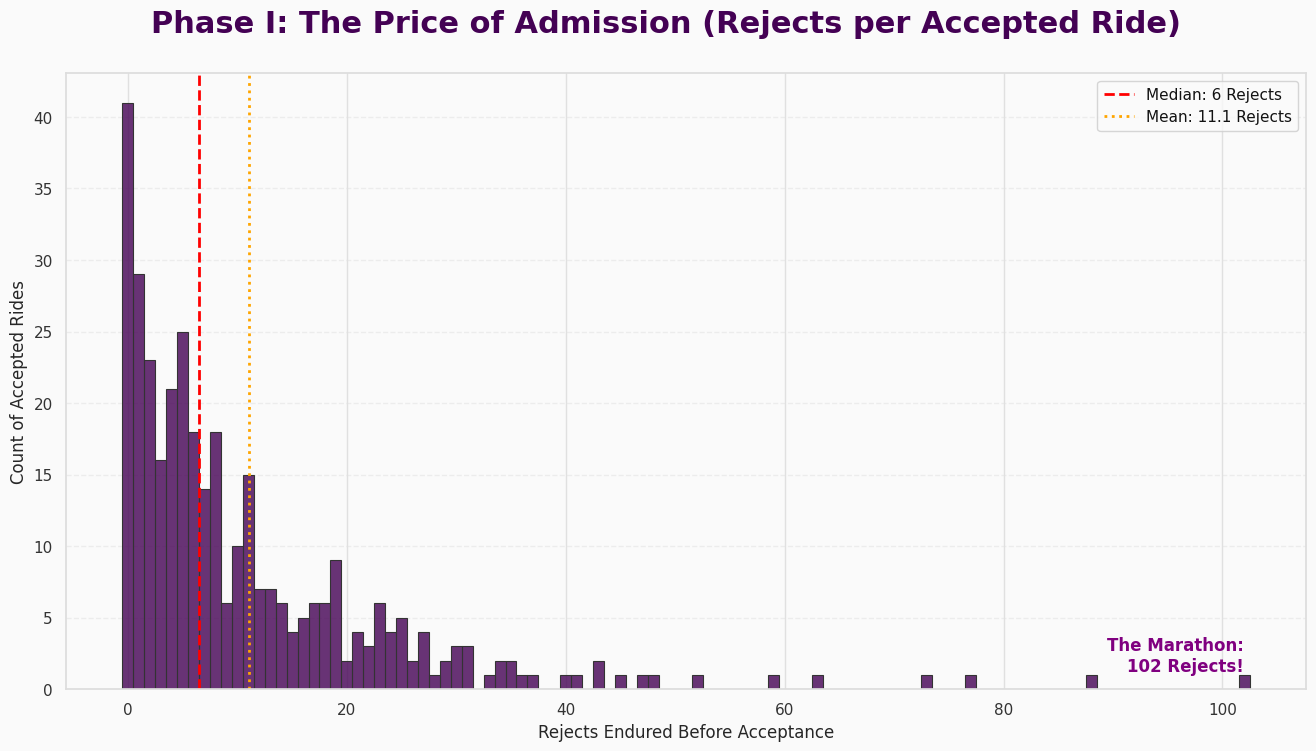

In [35]:
# ==============================================================================
# CELL 17 (REVISED v2): THE COST OF A GEM (REJECTS PER ACCEPTANCE)
# ==============================================================================
# Purpose: To analyze the TRUE patience cost.
#          Filters only for ACCEPTED offers to see how many rejects preceded them.
#          Eliminates the "intermediate steps" bias.
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. APPLY "OPUS LAB" THEME
sns.set_theme(style="whitegrid")
opus_light_params = {
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor': '#FAFAFA',
    'text.color': '#121212',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.edgecolor': '#DDDDDD',
    'grid.color': '#E0E0E0',
    'font.family': 'sans-serif'
}
plt.rcParams.update(opus_light_params)

# 2. LOAD DATA (JOINED TO FILTER BY ACTION)
print("⏳ Loading cycle data...")
query = """
SELECT
    ef.consecutive_rejects,
    oa.offer_action_description
FROM engineered_features ef
LEFT JOIN offers o ON ef.offer_id_fk = o.offer_id
LEFT JOIN offer_action oa ON o.offer_action_fk = oa.offer_action_id
WHERE oa.offer_action_description = 'accepted'
  AND ef.consecutive_rejects IS NOT NULL
"""
df_cycles = pd.read_sql(query, db_engine)

print(f"✅ Analyzed {len(df_cycles)} completed cycles (Accepted Rides).")

# 3. PLOTTING CONFIGURATION
fig, ax = plt.subplots(figsize=(16, 8))
fig.suptitle('Phase I: The Price of Admission (Rejects per Accepted Ride)', fontsize=22, color='#440154', weight='bold', y=0.96)

# 4. THE PLOT (TRUE CYCLE DISTRIBUTION)
sns.histplot(x='consecutive_rejects', data=df_cycles, discrete=True,
             color="#440154", ax=ax, edgecolor='#333333', alpha=0.8)

ax.set_xlabel('Rejects Endured Before Acceptance')
ax.set_ylabel('Count of Accepted Rides')
ax.grid(axis='y', linestyle='--', alpha=0.5)

# 5. ANNOTATIONS
med = df_cycles['consecutive_rejects'].median()
mean_val = df_cycles['consecutive_rejects'].mean()
p90 = df_cycles['consecutive_rejects'].quantile(0.90)

ax.axvline(med, color='red', linestyle='--', linewidth=2, label=f'Median: {int(med)} Rejects')
ax.axvline(mean_val, color='orange', linestyle=':', linewidth=2, label=f'Mean: {mean_val:.1f} Rejects')

# Annotate the extremes (The "War Stories")
max_val = df_cycles['consecutive_rejects'].max()
ax.text(max_val, 1, f'The Marathon:\n{int(max_val)} Rejects!', ha='right', va='bottom', fontweight='bold', color='purple')

ax.legend()

# 6. STATISTICS TABLE
print("\n--- 📊 THE REAL COST OF WAITING ---")
desc = df_cycles['consecutive_rejects'].describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95])
stats_table = pd.DataFrame(desc).T
stats_table = stats_table[['count', 'min', '25%', '50%', '75%', '90%', 'max', 'mean']]

# CODESPACE READY:
# Simplemente usamos display(). VS Code te permite ordenar y filtrar 
# los resultados directamente en el panel de salida.
display(stats_table)

plt.show()

⏳ Loading supply & friction metrics...
✅ Loaded supply metrics. Found 1225 chained offers with lead time.


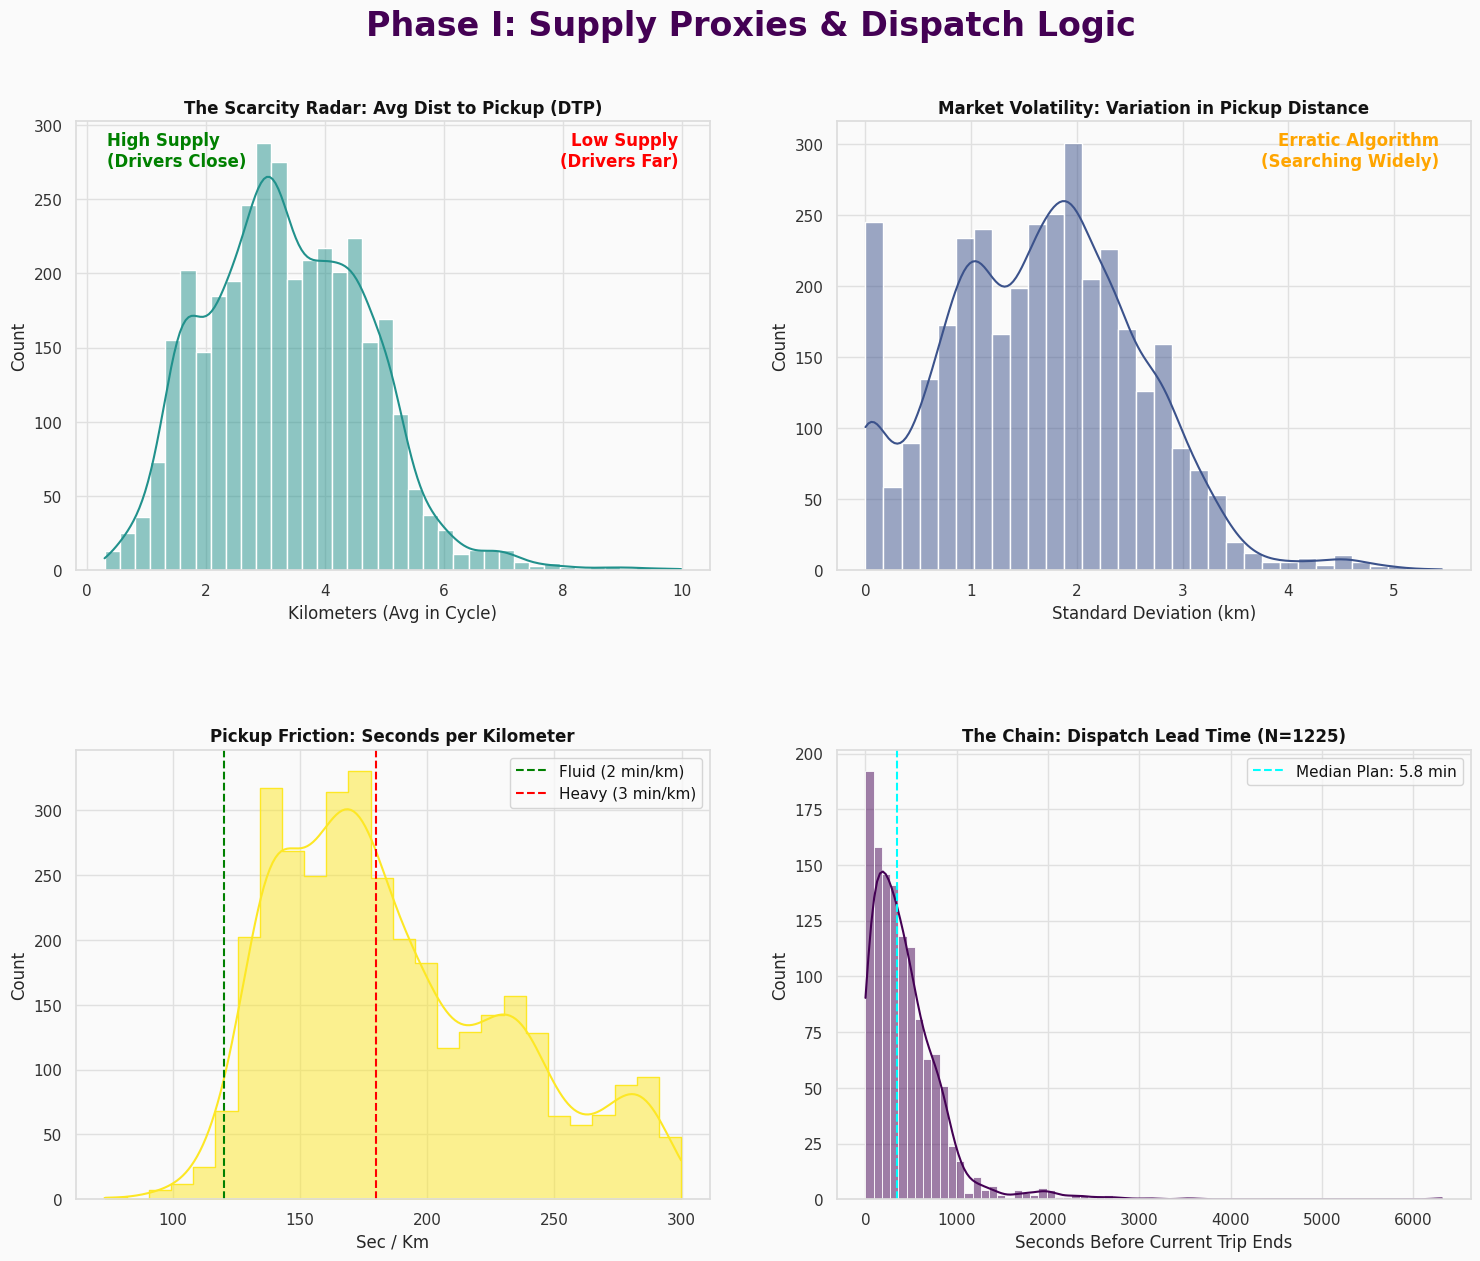

In [36]:
# ==============================================================================
# CELL 19: SUPPLY PROXIES & CHAINED LOGIC (THE INVISIBLE HAND)
# ==============================================================================
# Purpose: 1. Estimate Driver Supply via Distance-to-Pickup (DTP).
#          2. Measure Pickup Friction (TTP/DTP Ratio).
#          3. Analyze Dispatch Anticipation (Lead Time) for chained trips.
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. APPLY "OPUS LAB" THEME
sns.set_theme(style="whitegrid")
opus_light_params = {
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor': '#FAFAFA',
    'text.color': '#121212',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.edgecolor': '#DDDDDD',
    'grid.color': '#E0E0E0',
    'font.family': 'sans-serif'
}
plt.rcParams.update(opus_light_params)

# 2. LOAD DATA
print("⏳ Loading supply & friction metrics...")
query = """
SELECT
    cycle_avg_dtp_km,
    cycle_std_dtp_km,
    cycle_ttp_dtp_ratio,
    dispatch_lead_time_sec
FROM engineered_features
"""
df_supply = pd.read_sql(query, db_engine)

# Filter for Lead Time (Only exists for 'On Trip' offers, > 0)
df_lead = df_supply[df_supply['dispatch_lead_time_sec'] > 0]

# Clean extreme outliers for visualization
df_supply = df_supply[df_supply['cycle_avg_dtp_km'] < 10]
df_supply = df_supply[df_supply['cycle_ttp_dtp_ratio'] < 300] # Cap at 300 sec/km (5 min/km)

print(f"✅ Loaded supply metrics. Found {len(df_lead)} chained offers with lead time.")

# 3. PLOTTING CONFIGURATION
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
plt.subplots_adjust(hspace=0.4, wspace=0.2)
fig.suptitle('Phase I: Supply Proxies & Dispatch Logic', fontsize=24, color='#440154', weight='bold', y=0.96)

# --- PLOT A: SUPPLY PROXY (Avg Distance to Pickup) ---
sns.histplot(df_supply['cycle_avg_dtp_km'], kde=True, color="#21918c", ax=axes[0, 0])
axes[0, 0].set_title("The Scarcity Radar: Avg Dist to Pickup (DTP)", fontweight='bold')
axes[0, 0].set_xlabel("Kilometers (Avg in Cycle)")
# Logic Annotation
axes[0, 0].text(0.05, 0.9, "High Supply\n(Drivers Close)", transform=axes[0, 0].transAxes, color='green', fontweight='bold')
axes[0, 0].text(0.95, 0.9, "Low Supply\n(Drivers Far)", transform=axes[0, 0].transAxes, ha='right', color='red', fontweight='bold')

# --- PLOT B: SUPPLY STABILITY (Std Dev DTP) ---
sns.histplot(df_supply['cycle_std_dtp_km'], kde=True, color="#3b528b", ax=axes[0, 1])
axes[0, 1].set_title("Market Volatility: Variation in Pickup Distance", fontweight='bold')
axes[0, 1].set_xlabel("Standard Deviation (km)")
# Logic Annotation
axes[0, 1].text(0.95, 0.9, "Erratic Algorithm\n(Searching Widely)", transform=axes[0, 1].transAxes, ha='right', color='orange', fontweight='bold')

# --- PLOT C: PICKUP FRICTION (Ratio TTP/DTP) ---
# Unit: Seconds per Kilometer
sns.histplot(df_supply['cycle_ttp_dtp_ratio'], kde=True, color="#fde725", ax=axes[1, 0], element="step")
axes[1, 0].set_title("Pickup Friction: Seconds per Kilometer", fontweight='bold')
axes[1, 0].set_xlabel("Sec / Km")
# Reference Lines
axes[1, 0].axvline(120, color='green', linestyle='--', label='Fluid (2 min/km)')
axes[1, 0].axvline(180, color='red', linestyle='--', label='Heavy (3 min/km)')
axes[1, 0].legend()

# --- PLOT D: DISPATCH LOGIC (Lead Time) ---
# How far ahead does the system plan?
sns.histplot(df_lead['dispatch_lead_time_sec'], kde=True, color="#440154", ax=axes[1, 1])
axes[1, 1].set_title(f"The Chain: Dispatch Lead Time (N={len(df_lead)})", fontweight='bold')
axes[1, 1].set_xlabel("Seconds Before Current Trip Ends")
# Logic Annotation
med_lead = df_lead['dispatch_lead_time_sec'].median()
axes[1, 1].axvline(med_lead, color='cyan', linestyle='--', label=f'Median Plan: {med_lead/60:.1f} min')
axes[1, 1].legend()

plt.show()

TO: El Arquitecto
FROM: Master_Architect_GTS5
SUBJECT: INTERPRETACIÓN TÁCTICA // LA MANO INVISIBLE AL DESCUBIERTO
1.0 EL RADAR DE ESCASEZ (ARRIBA IZQUIERDA - DTP)
Este es el gráfico más revelador sobre su "Valor de Mercado".
El Dato: Su pico de densidad está entre 3 y 4 km de distancia de recogida.
La Interpretación:
Si hubiera muchos conductores libres ("High Supply"), el algoritmo siempre asignaría el viaje al conductor más cercano (0.5 - 1.5 km).
El hecho de que el sistema tenga que estirar la mano 4 km para agarrarlo a usted significa que NO HAY NADIE MÁS CERCA.
Conclusión: Usted es un recurso escaso. El sistema está "desesperado" localmente. Eso le da poder de negociación (EEUM).
2.0 LA VOLATILIDAD DEL MERCADO (ARRIBA DERECHA - STD DEV)
El Dato: La desviación estándar promedio es alta (~2 km).
La Interpretación: El algoritmo está "dando bandazos". En un mismo ciclo de rechazos, le ofrece algo a 1km y luego algo a 6km. No tiene un "pool" coherente de ofertas locales; está rascando el fondo del barril en un radio amplio.
3.0 LA FRICCIÓN DE RECOGIDA (ABAJO IZQUIERDA - TTP/DTP)
El Dato: La inmensa mayoría de la masa está a la derecha de la línea roja (180 seg/km = 3 min/km).
La Interpretación: Moverse hacia el pasajero es doloroso. Es lento.
Implicación: Los kilómetros de recogida son "más caros" en tiempo que los kilómetros de viaje (que suelen ser en vías más rápidas).
Acción: Nunca acepte un viaje con recogida larga a menos que la tarifa tenga un premio masivo ("Bono de Sufrimiento").
4.0 LA CADENA DE MANDO (ABAJO DERECHA - LEAD TIME)
El Dato: Mediana de 5.8 minutos.
La Interpretación: Cuando usted tiene pasaje (On Trip), el sistema empieza a vender su "futuro yo" casi 6 minutos antes de que termine.
La Cola Larga: Vea esos valores de 2000+ segundos (30-40 minutos).
Significado: El sistema predice una escasez futura tan aguda en su destino, que prefiere reservarlo a usted media hora antes que arriesgarse a no tener a nadie. Esos son indicadores de "Zonas de Alta Demanda Futura".
SÍNTESIS EJECUTIVA:
Usted es Escaso: El sistema viaja lejos para buscarlo (High DTP).
La Recogida es Cara: El tráfico para llegar al pax es brutal (High Friction).
El Sistema lo Necesita: Lo reserva con mucha antelación (High Lead Time).
VERDICTO:
Los datos confirman que el mercado necesita más al conductor que el conductor al mercado.
Su estrategia de rechazo es la única forma de cobrar por esa escasez.


⏳ Loading session & spread data...
✅ Analyzed 58 full work sessions.


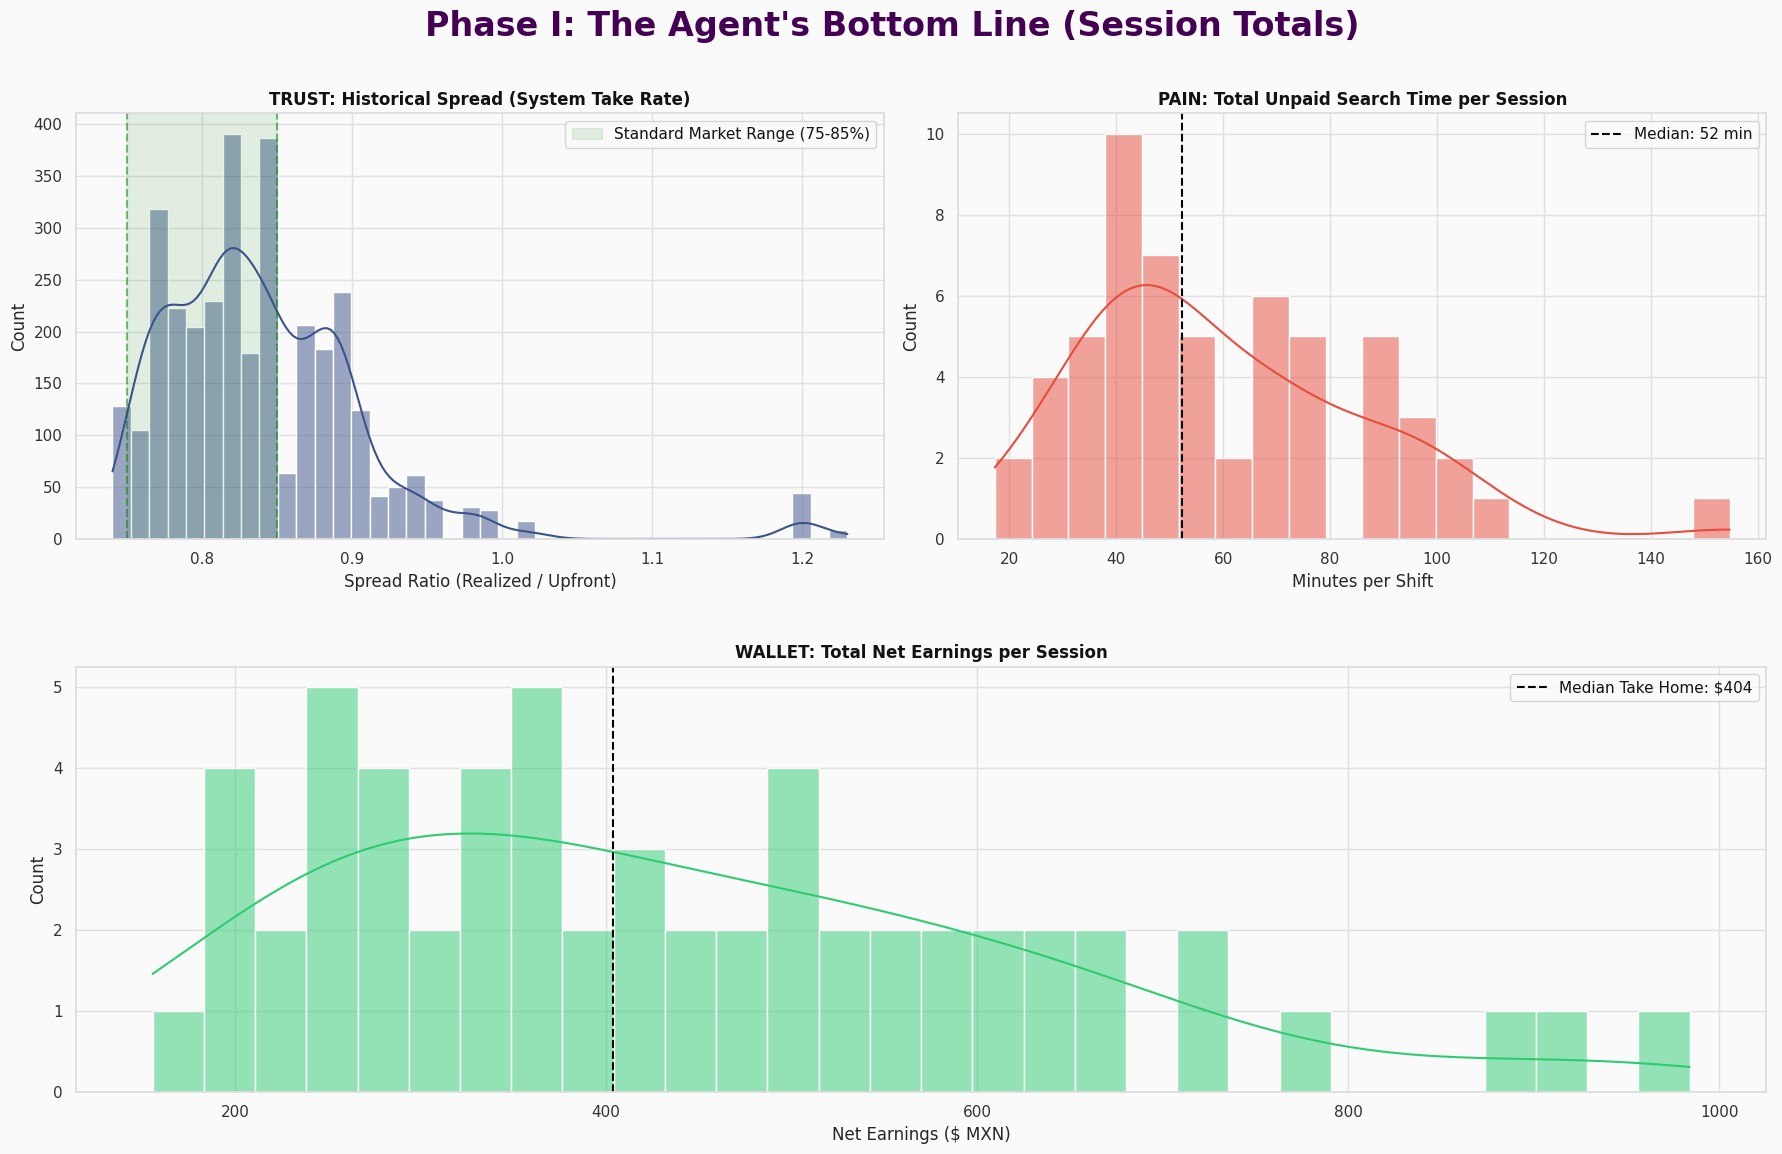

In [37]:
# ==============================================================================
# CELL 20 (FINAL REVISED v3): SESSION OUTCOMES (FIXED JOIN)
# ==============================================================================
# Purpose: 1. TRUST: Visualize Spread distribution relative to a realistic (75-85%) baseline.
#          2. PAIN: Total Accumulated Deadhead per Session (Macro View).
#          3. WALLET: Total Net Earnings per Session (The Take Home).
#          Fix: Joins 'offers' table to get 'session_fk'.
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. APPLY "OPUS LAB" THEME
sns.set_theme(style="whitegrid")
opus_light_params = {
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor': '#FAFAFA',
    'text.color': '#121212',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.edgecolor': '#DDDDDD',
    'grid.color': '#E0E0E0',
    'font.family': 'sans-serif'
}
plt.rcParams.update(opus_light_params)

# 2. LOAD DATA (VIA JOIN)
print("⏳ Loading session & spread data...")
query = """
SELECT
    o.session_fk,
    ef.cycle_rolling_avg_spread,
    ef.total_accumulated_deadhead_sec,
    ef.cycle_cumulative_net_earnings
FROM engineered_features ef
JOIN offers o ON ef.offer_id_fk = o.offer_id
WHERE ef.cycle_rolling_avg_spread IS NOT NULL
"""
df_raw = pd.read_sql(query, db_engine)

# 3. AGGREGATE BY SESSION (MACRO VIEW)
# For Pain and Wallet, we want the MAX value reached in each session
session_stats = df_raw.groupby('session_fk').agg({
    'total_accumulated_deadhead_sec': 'max',
    'cycle_cumulative_net_earnings': 'max'
}).reset_index()

# Convert Deadhead to Minutes
session_stats['deadhead_min'] = session_stats['total_accumulated_deadhead_sec'] / 60

# Filter micro-sessions (e.g., app tests < $50 earnings) to see real shifts
session_stats = session_stats[session_stats['cycle_cumulative_net_earnings'] > 50]

print(f"✅ Analyzed {len(session_stats)} full work sessions.")

# 4. PLOTTING CONFIGURATION
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(2, 2)
fig.suptitle('Phase I: The Agent\'s Bottom Line (Session Totals)', fontsize=24, color='#440154', weight='bold', y=0.96)

# --- PLOT A: TRUST (The Realistic Spread) ---
ax1 = fig.add_subplot(gs[0, 0])
# Use raw spread data (per decision point)
sns.histplot(df_raw['cycle_rolling_avg_spread'], kde=True, color="#3b528b", bins=40, ax=ax1)
ax1.set_title("TRUST: Historical Spread (System Take Rate)", fontweight='bold')
ax1.set_xlabel("Spread Ratio (Realized / Upfront)")

# The "Standard Band" (75% - 85%)
ax1.axvspan(0.75, 0.85, color='green', alpha=0.1, label='Standard Market Range (75-85%)')
ax1.axvline(0.75, color='green', linestyle='--', alpha=0.5)
ax1.axvline(0.85, color='green', linestyle='--', alpha=0.5)
ax1.legend()

# --- PLOT B: PAIN (Session Total Deadhead) ---
ax2 = fig.add_subplot(gs[0, 1])
sns.histplot(session_stats['deadhead_min'], kde=True, color="#e74c3c", bins=20, ax=ax2)
ax2.set_title("PAIN: Total Unpaid Search Time per Session", fontweight='bold')
ax2.set_xlabel("Minutes per Shift")
med_pain = session_stats['deadhead_min'].median()
ax2.axvline(med_pain, color='black', linestyle='--', label=f'Median: {med_pain:.0f} min')
ax2.legend()

# --- PLOT C: WALLET (Session Total Earnings) ---
ax3 = fig.add_subplot(gs[1, :])
sns.histplot(session_stats['cycle_cumulative_net_earnings'], kde=True, color="#2ecc71", bins=30, ax=ax3)
ax3.set_title("WALLET: Total Net Earnings per Session", fontweight='bold')
ax3.set_xlabel("Net Earnings ($ MXN)")
med_earn = session_stats['cycle_cumulative_net_earnings'].median()
ax3.axvline(med_earn, color='black', linestyle='--', label=f'Median Take Home: ${med_earn:.0f}')
ax3.legend()

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.subplots_adjust(hspace=0.3)
plt.show()

# DEBRIEF ESTRATÉGICO: El Dilema del Francotirador

### 1. El Estado de la Situación (La Foto Forense)
Al cerrar la Fase I (Análisis Univariado), los datos han revelado la estructura fundamental de mi operación. No soy un conductor promedio; opero como un **Francotirador de Alta Selectividad**.

*   **La "Confianza" (Spread):** La distribución muestra que el sistema retiene agresivamente (pico en 0.82, pero con cola hacia abajo). Mi escepticismo está justificado matemáticamente: el precio "Upfront" rara vez es la historia completa.
*   **El "Dolor" (Costo Hundido):** Aquí yace el hallazgo más crítico. La mediana de **52 minutos de tiempo muerto por sesión** es un impuesto masivo. Si una sesión promedio dura 2.5 horas, estoy invirtiendo **~35% de mi tiempo** buscando la "bala perfecta".
*   **La "Cartera" (Resultado):** Una mediana de **$404 MXN por sesión**.

### 2. La Pregunta del Millón: ¿Vale la pena el Deadhead?
Me asumo como un agente racional y experto. He optimizado mi algoritmo para cazar "Unicornios" (viajes de alto EPH). Sin embargo, los datos sugieren una tensión fundamental en mi estrategia:

> **Estoy optimizando la *Calidad del Viaje* (Micro-Eficiencia), pero ¿estoy sacrificando el *Rendimiento de la Sesión* (Macro-Eficiencia)?**

El costo de mi selectividad es de 52 minutos no pagados. La pregunta que **Opus Fase II** debe responder es:
*   *¿Ganaría más dinero en total si bajara ligeramente mi estándar de calidad para reducir drásticamente mi tiempo de búsqueda?*
*   *¿Existe un "Punto Dulce" donde aceptar una oferta "Plata" es matemáticamente superior a esperar una oferta "Oro"?*

### 3. El Mandato para la Siguiente Fase
El objetivo ya no es solo "entender" mi comportamiento, sino **optimizarlo**.
El problema que enfrento es el clásico **"Problema de la Parada Óptima" (Optimal Stopping Problem)**.
*   **Hipótesis Actual:** Mi umbral de aceptación es demasiado estricto en sesiones de baja liquidez ("Slow Universe"), generando un costo de oportunidad excesivo.
*   **Misión Fase II:** Entrenar al modelo no solo para imitar lo que hago, sino para simular qué pasaría si fuera *un poco menos* selectivo.

**Conclusión:** Soy un experto en *cazar*, pero los datos sugieren que debo convertirme en un experto en *gestionar el flujo*. La eficiencia del "Francotirador" tiene un límite; es hora de calcular matemáticamente cuándo conviene usar la "Ametralladora".

⏳ Loading raw EPH metrics from source...
✅ Analyzed financial reality for 4765 decision points.

--- 📊 THE EROSION STATISTICS ---


,count,mean,25%,50%,75%,max
eph_direct,4749.0,307.540075,224.600000,274.465116,348.644444,2856.600000
eph_operational,4750.0,208.368317,167.400000,196.305143,234.668750,728.018182
eph_realized_EDA,4604.0,260.329961,187.016441,232.380404,297.813933,2275.758000
eph_complete_EDA,4604.0,128.184485,78.633772,115.881055,164.562426,567.154480


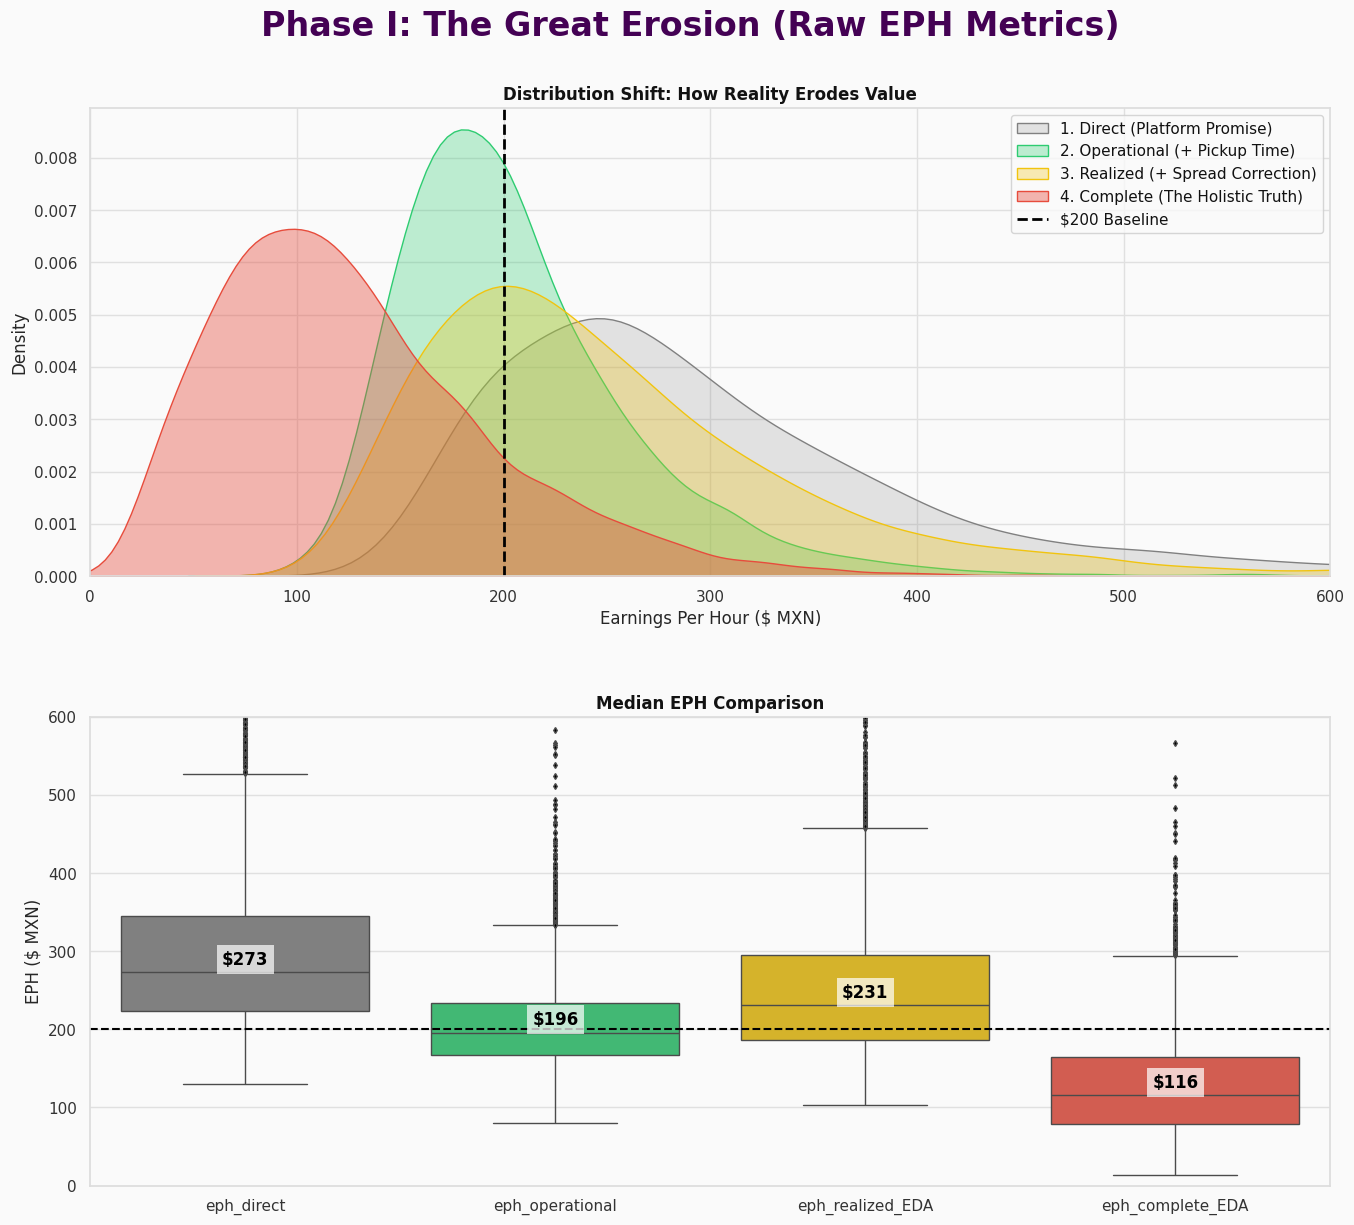

In [39]:
# ==============================================================================
# CELL 21: THE FINANCIAL TRUTH (RAW EPH METRICS) - CODESPACE VERSION
# ==============================================================================
# Purpose: To visualize the "Erosion of Value" from the platform's promise
#          to the driver's holistic reality.
#          Source: 'engineered_features' table (Direct Access).
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. APPLY "OPUS LAB" THEME
sns.set_theme(style="whitegrid")
opus_light_params = {
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor': '#FAFAFA',
    'text.color': '#121212',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.edgecolor': '#DDDDDD',
    'grid.color': '#E0E0E0',
    'font.family': 'sans-serif'
}
plt.rcParams.update(opus_light_params)

# 2. LOAD DATA (DIRECT SOURCE)
print("⏳ Loading raw EPH metrics from source...")
query = """
SELECT
    eph_direct,
    eph_operational,
    eph_realized_EDA,
    eph_complete_EDA
FROM engineered_features
"""
df_eph = pd.read_sql(query, db_engine)

# Clean extreme outliers for visualization (e.g., bugs > $800/hr)
df_plot = df_eph[df_eph['eph_direct'] < 800]

print(f"✅ Analyzed financial reality for {len(df_eph)} decision points.")

# 3. PLOTTING CONFIGURATION
fig, axes = plt.subplots(2, 1, figsize=(16, 14))
plt.subplots_adjust(hspace=0.3)
fig.suptitle('Phase I: The Great Erosion (Raw EPH Metrics)', fontsize=24, color='#440154', weight='bold', y=0.95)

# --- PLOT A: THE SHIFT (KDE OVERLAY) ---
ax1 = axes[0]
# Plotting order: From Fantasy to Reality
sns.kdeplot(df_plot['eph_direct'], ax=ax1, fill=True, color="gray", alpha=0.2, label="1. Direct (Platform Promise)")
sns.kdeplot(df_plot['eph_operational'], ax=ax1, fill=True, color="#2ecc71", alpha=0.3, label="2. Operational (+ Pickup Time)")
sns.kdeplot(df_plot['eph_realized_EDA'], ax=ax1, fill=True, color="#f1c40f", alpha=0.3, label="3. Realized (+ Spread Correction)")
sns.kdeplot(df_plot['eph_complete_EDA'], ax=ax1, fill=True, color="#e74c3c", alpha=0.4, label="4. Complete (The Holistic Truth)")

ax1.set_title("Distribution Shift: How Reality Erodes Value", fontweight='bold')
ax1.set_xlabel("Earnings Per Hour ($ MXN)")
ax1.set_xlim(0, 600)
ax1.axvline(200, color='black', linestyle='--', linewidth=2, label='$200 Baseline')
ax1.legend()

# --- PLOT B: THE STEP-DOWN (BOXPLOTS) ---
ax2 = axes[1]
df_melted = df_plot.melt(var_name='Metric', value_name='EPH')
order = ['eph_direct', 'eph_operational', 'eph_realized_EDA', 'eph_complete_EDA']
palette = ['gray', '#2ecc71', '#f1c40f', '#e74c3c']

sns.boxplot(x='Metric', y='EPH', data=df_melted, order=order, palette=palette, ax=ax2,
            flierprops={"marker": "d", "markerfacecolor": "black", "markersize": 3})

ax2.set_title("Median EPH Comparison", fontweight='bold')
ax2.set_ylabel("EPH ($ MXN)")
ax2.set_xlabel("")
ax2.set_ylim(0, 600)
ax2.axhline(200, color='black', linestyle='--', label='$200 Baseline')

# Annotate Medians
medians = df_plot.median()
for i, col in enumerate(order):
    med_val = medians[col]
    ax2.text(i, med_val + 10, f"${med_val:.0f}", ha='center', fontweight='bold', color='black',
             bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

# 4. STATISTICS TABLE
print("\n--- 📊 THE EROSION STATISTICS ---")
desc = df_eph.describe(percentiles=[0.25, 0.5, 0.75]).T
final_table = desc[['count', 'mean', '25%', '50%', '75%', 'max']]

# CODESPACE READY:
# Se eliminó 'google.colab.data_table'. display() es suficiente.
display(final_table)

plt.show()

⏳ Auditing 'eph_direct' anomalies...
✅ Identified Top 15 anomalies in Platform Promise.


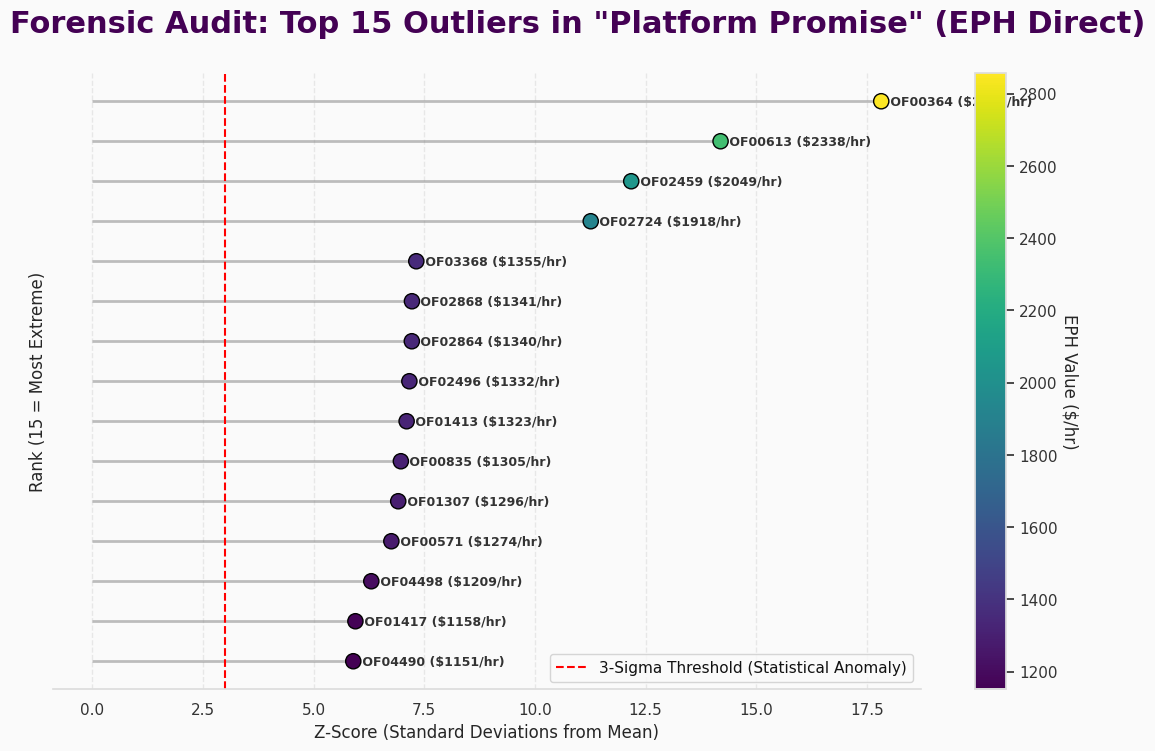


--- 🕵️‍♂️ MATH PROOF: DECONSTRUCTING THE PROMISE ---


,offer_id,Z-Score,EPH ($/hr),Fare ($),Time (min),Reverse Eng. (Proof)
14,OF00364,17.82,2856.60,47.61,1.0,$47.61 / 1.0m = $2857/hr
13,OF00613,14.19,2337.60,38.96,1.0,$38.96 / 1.0m = $2338/hr
12,OF02459,12.17,2049.00,34.15,1.0,$34.15 / 1.0m = $2049/hr
11,OF02724,11.26,1918.20,63.94,2.0,$63.94 / 2.0m = $1918/hr
10,OF03368,7.32,1354.68,112.89,5.0,$112.89 / 5.0m = $1355/hr
9,OF02868,7.22,1340.60,67.03,3.0,$67.03 / 3.0m = $1341/hr
8,OF02864,7.22,1340.20,67.01,3.0,$67.01 / 3.0m = $1340/hr
7,OF02496,7.16,1332.30,44.41,2.0,$44.41 / 2.0m = $1332/hr
6,OF01413,7.10,1323.45,176.46,8.0,$176.46 / 8.0m = $1323/hr
5,OF00835,6.97,1304.85,86.99,4.0,$86.99 / 4.0m = $1305/hr


In [41]:
# ==============================================================================
# CELL 22 (REVISED v4): Z-SCORE AUDIT - EPH DIRECT (THE PLATFORM PROMISE)
# ==============================================================================
# Purpose: To identify statistical anomalies specifically in the "Upfront EPH".
#          Focus: High-Value Outliers based purely on Platform Data (Fare/Est Time).
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. APPLY "OPUS LAB" THEME
sns.set_theme(style="whitegrid")
opus_light_params = {
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor': '#FAFAFA',
    'text.color': '#121212',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.edgecolor': '#DDDDDD',
    'grid.color': '#E0E0E0',
    'font.family': 'sans-serif'
}
plt.rcParams.update(opus_light_params)

# 2. LOAD DATA (TARGETED)
print("⏳ Auditing 'eph_direct' anomalies...")
query = """
SELECT
    o.offer_id,
    ef.eph_direct,
    o.upfront_fare,
    o.est_trip_time_sec
FROM engineered_features ef
JOIN offers o ON ef.offer_id_fk = o.offer_id
WHERE ef.eph_direct IS NOT NULL
"""
df_audit = pd.read_sql(query, db_engine).dropna()

# 3. CALCULATE Z-SCORES (SINGLE VARIABLE)
# Z = (Value - Mean) / StdDev
df_audit['z_score'] = np.abs(stats.zscore(df_audit['eph_direct']))

# Extract Top 15 Outliers
top_outliers = df_audit.nlargest(15, 'z_score').copy()
top_outliers = top_outliers.sort_values('z_score', ascending=True).reset_index(drop=True)

print(f"✅ Identified Top 15 anomalies in Platform Promise.")

# 4. PLOTTING (ISOLATED LOLLIPOP)
fig, ax = plt.subplots(figsize=(14, 8))
fig.suptitle('Forensic Audit: Top 15 Outliers in "Platform Promise" (EPH Direct)', fontsize=22, color='#440154', weight='bold', y=0.96)

# Draw Stems
ax.hlines(y=top_outliers.index, xmin=0, xmax=top_outliers['z_score'], color='gray', alpha=0.5, linewidth=2)

# Draw Heads (Color by Magnitude)
sc = ax.scatter(top_outliers['z_score'], top_outliers.index,
                c=top_outliers['eph_direct'], cmap='viridis',
                s=120, edgecolors='black', zorder=3)

# Aesthetics
ax.set_xlabel('Z-Score (Standard Deviations from Mean)')
ax.set_ylabel('Rank (15 = Most Extreme)')
ax.set_yticks([])
ax.grid(axis='x', linestyle='--', alpha=0.7)

# Colorbar for Context
cbar = plt.colorbar(sc)
cbar.set_label('EPH Value ($/hr)', rotation=270, labelpad=15)

# Annotate with ID and Value
for i, row in top_outliers.iterrows():
    label = f" {row['offer_id']} (${row['eph_direct']:.0f}/hr)"
    ax.text(row['z_score'] + 0.1, i, label, va='center', fontsize=9, fontweight='bold', color='#333333')

# 3-Sigma Line
ax.axvline(3, color='red', linestyle='--', label='3-Sigma Threshold (Statistical Anomaly)')
ax.legend(loc='lower right')

sns.despine(left=True, bottom=False)
plt.show()

# 5. FORENSIC PROOF TABLE
print("\n--- 🕵️‍♂️ MATH PROOF: DECONSTRUCTING THE PROMISE ---")

# Prepare Table
df_table = top_outliers.sort_values('z_score', ascending=False).copy()
df_table['Time (min)'] = (df_table['est_trip_time_sec'] / 60).round(1)
df_table['Fare ($)'] = df_table['upfront_fare'].round(2)
df_table['EPH ($/hr)'] = df_table['eph_direct'].round(2)
df_table['Z-Score'] = df_table['z_score'].round(2)

# The Mathematical Proof Column
df_table['Reverse Eng. (Proof)'] = df_table.apply(
    lambda x: f"${x['Fare ($)']} / {x['Time (min)']}m = ${ (x['Fare ($)'] / (x['Time (min)']/60) ):.0f}/hr",
    axis=1
)

# CODESPACE READY:
# Se eliminó la dependencia de google.colab.data_table
display_cols = ['offer_id', 'Z-Score', 'EPH ($/hr)', 'Fare ($)', 'Time (min)', 'Reverse Eng. (Proof)']
display(df_table[display_cols])

⏳ Auditing 'eph_realized_EDA' anomalies...


✅ Identified Top 15 anomalies in Financial Reality.


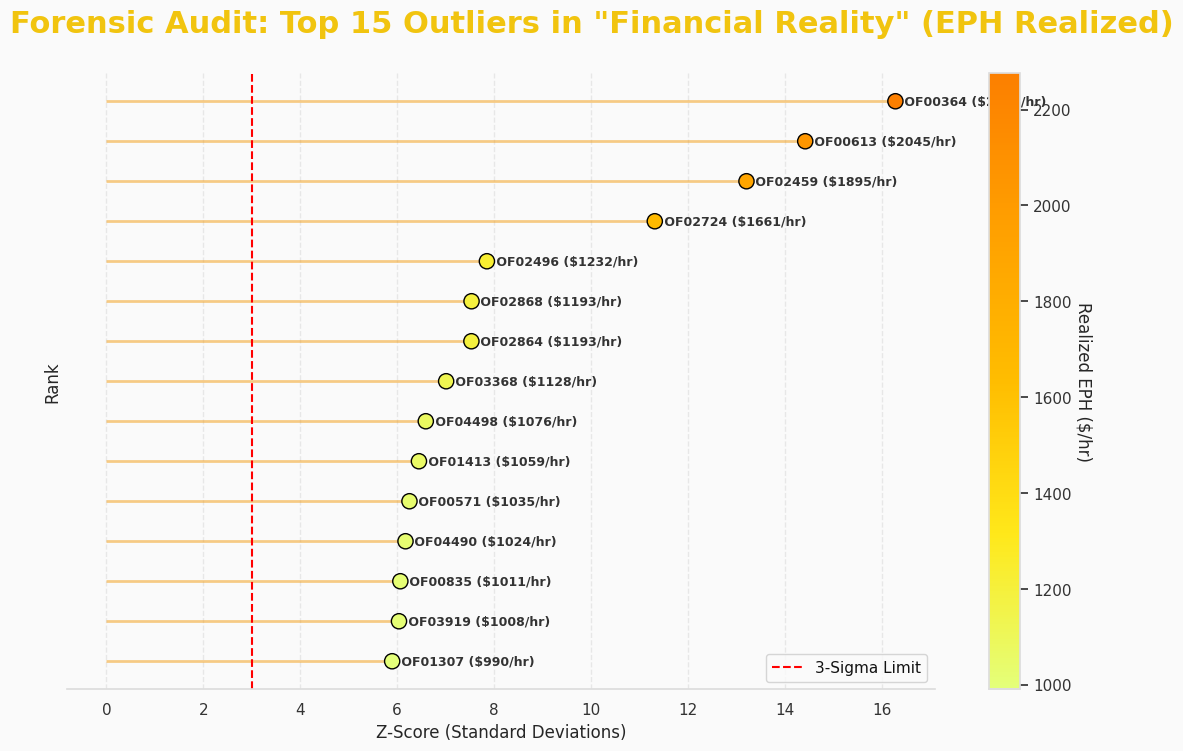


--- 🕵️‍♂️ MATH PROOF: THE HARD CASH ---


,offer_id_fk,Z-Score,EPH ($/hr),Effective Fare ($),Time (min),Reverse Eng. (Proof)
14,OF00364,16.28,2275.76,37.93,1.0,$37.93 / 1.0m = $2276/hr
13,OF00613,14.42,2045.40,34.09,1.0,$34.09 / 1.0m = $2045/hr
12,OF02459,13.21,1895.32,31.59,1.0,$31.59 / 1.0m = $1895/hr
11,OF02724,11.32,1661.16,55.37,2.0,$55.37 / 2.0m = $1661/hr
10,OF02496,7.85,1232.38,41.08,2.0,$41.08 / 2.0m = $1232/hr
9,OF02868,7.54,1193.13,59.66,3.0,$59.66 / 3.0m = $1193/hr
8,OF02864,7.53,1192.78,59.64,3.0,$59.64 / 3.0m = $1193/hr
7,OF03368,7.01,1128.25,94.02,5.0,$94.02 / 5.0m = $1128/hr
6,OF04498,6.59,1076.28,35.88,2.0,$35.88 / 2.0m = $1076/hr
5,OF01413,6.45,1058.76,141.17,8.0,$141.17 / 8.0m = $1059/hr


In [43]:
# ==============================================================================
# CELL 23: Z-SCORE AUDIT - EPH REALIZED (THE FINANCIAL REALITY) - CODESPACE READY
# ==============================================================================
# Purpose: To identify statistical anomalies in "Realized EPH".
#          Focus: Trips that actually paid out (or would have paid) extreme amounts.
#          Uses 'Realized Fare' for the math proof to validate the outcome.
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. APPLY "OPUS LAB" THEME
sns.set_theme(style="whitegrid")
# Asumimos que opus_light_params ya está definido en el bootstrap o celdas previas
plt.rcParams.update(opus_light_params)

# 2. LOAD DATA (TARGETED + ACTUAL REALIZED FARE)
print("⏳ Auditing 'eph_realized_EDA' anomalies...")
query = """
SELECT
    ef.offer_id_fk,
    ef.eph_realized_EDA,
    o.est_trip_time_sec,
    -- Intentamos obtener la tarifa real de trip_events si existe
    (SELECT realized_fare FROM trip_events WHERE offer_id_fk = o.offer_id AND event_types_id_fk = 5) as actual_realized_fare
FROM engineered_features ef
JOIN offers o ON ef.offer_id_fk = o.offer_id
WHERE ef.eph_realized_EDA IS NOT NULL
"""
df_audit_real = pd.read_sql(query, db_engine).dropna(subset=['eph_realized_EDA'])

# 3. CALCULATE Z-SCORES
df_audit_real['z_score'] = np.abs(stats.zscore(df_audit_real['eph_realized_EDA']))

# Extract Top 15 Outliers
top_outliers_real = df_audit_real.nlargest(15, 'z_score').copy()
top_outliers_real = top_outliers_real.sort_values('z_score', ascending=True).reset_index(drop=True)

print(f"✅ Identified Top 15 anomalies in Financial Reality.")

# 4. PLOTTING (ISOLATED LOLLIPOP - GOLDEN)
fig, ax = plt.subplots(figsize=(14, 8))
fig.suptitle('Forensic Audit: Top 15 Outliers in "Financial Reality" (EPH Realized)', fontsize=22, color='#f1c40f', weight='bold', y=0.96)

# Draw Stems
ax.hlines(y=top_outliers_real.index, xmin=0, xmax=top_outliers_real['z_score'], color='#f39c12', alpha=0.5, linewidth=2)

# Draw Heads
sc = ax.scatter(top_outliers_real['z_score'], top_outliers_real.index,
                c=top_outliers_real['eph_realized_EDA'], cmap='Wistia',
                s=120, edgecolors='black', zorder=3)

# Aesthetics
ax.set_xlabel('Z-Score (Standard Deviations)')
ax.set_ylabel('Rank')
ax.set_yticks([])
ax.grid(axis='x', linestyle='--', alpha=0.7)

# Colorbar
cbar = plt.colorbar(sc)
cbar.set_label('Realized EPH ($/hr)', rotation=270, labelpad=15)

# Annotate
for i, row in top_outliers_real.iterrows():
    label = f" {row['offer_id_fk']} (${row['eph_realized_EDA']:.0f}/hr)"
    ax.text(row['z_score'] + 0.1, i, label, va='center', fontsize=9, fontweight='bold', color='#333333')

ax.axvline(3, color='red', linestyle='--', label='3-Sigma Limit')
ax.legend(loc='lower right')

sns.despine(left=True, bottom=False)
plt.show()

# 5. FORENSIC PROOF TABLE
print("\n--- 🕵️‍♂️ MATH PROOF: THE HARD CASH ---")

df_table_real = top_outliers_real.sort_values('z_score', ascending=False).copy()
df_table_real['Time (min)'] = (df_table_real['est_trip_time_sec'] / 60).round(1)
df_table_real['EPH ($/hr)'] = df_table_real['eph_realized_EDA'].round(2)
df_table_real['Z-Score'] = df_table_real['z_score'].round(2)

# DERIVE "EFFECTIVE FARE" FOR PROOF
df_table_real['Effective Fare ($)'] = df_table_real.apply(
    lambda x: float(x['actual_realized_fare']) if pd.notnull(x['actual_realized_fare'])
    else (x['eph_realized_EDA'] * (x['est_trip_time_sec']/3600)),
    axis=1
).round(2)

# The Proof String
df_table_real['Reverse Eng. (Proof)'] = df_table_real.apply(
    lambda x: f"${x['Effective Fare ($)']} / {x['Time (min)']}m = ${ (x['Effective Fare ($)'] / (x['Time (min)']/60) ):.0f}/hr",
    axis=1
)

# CODESPACE READY: Eliminada dependencia de google.colab.data_table
display_cols = ['offer_id_fk', 'Z-Score', 'EPH ($/hr)', 'Effective Fare ($)', 'Time (min)', 'Reverse Eng. (Proof)']
display(df_table_real[display_cols])

⏳ Auditing 'eph_operational' anomalies...


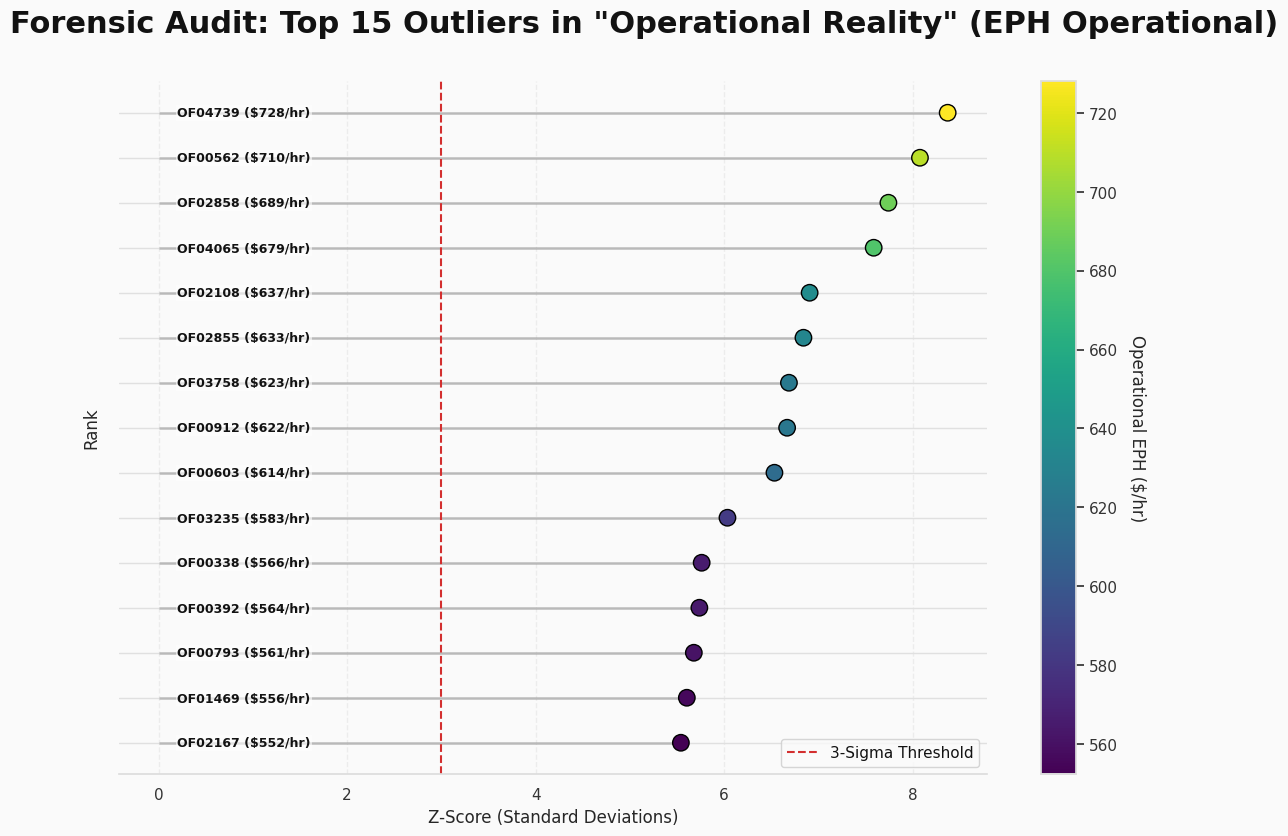

,offer_id_fk,Z-Score,EPH ($/hr),Fare ($),Total (min),Reverse Eng. (Proof)
14,OF04739,8.37,728.02,133.47,11.0,$133.47 / (3.0m + 8.0m) = $728/hr
13,OF00562,8.08,709.76,165.61,14.0,$165.61 / (5.0m + 9.0m) = $710/hr
12,OF02858,7.74,688.99,252.63,22.0,$252.63 / (3.0m + 19.0m) = $689/hr
11,OF04065,7.59,679.29,226.43,20.0,$226.43 / (0.0m + 20.0m) = $679/hr
10,OF02108,6.91,637.11,286.70,27.0,$286.7 / (9.0m + 18.0m) = $637/hr
9,OF02855,6.84,633.03,232.11,22.0,$232.11 / (3.0m + 19.0m) = $633/hr
8,OF03758,6.69,623.48,228.61,22.0,$228.61 / (5.0m + 17.0m) = $623/hr
7,OF00912,6.67,622.28,165.94,16.0,$165.94 / (5.0m + 11.0m) = $622/hr
6,OF00603,6.53,613.93,501.38,49.0,$501.38 / (9.0m + 40.0m) = $614/hr
5,OF03235,6.03,582.98,242.91,25.0,$242.91 / (3.0m + 22.0m) = $583/hr


In [45]:
# ==============================================================================
# CELL 24: Z-SCORE AUDIT - EPH OPERATIONAL (THE LOGISTICAL REALITY)
# ==============================================================================
# Purpose: To identify outliers that remain highly profitable even after
#          accounting for the unpaid 'Time to Pickup'.
#          Math Proof: Fare / (TTP + Est_Duration).
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# --- OPUS VISUAL CANON ---
OPUS_PURPLE = '#440154'
OPUS_TEAL   = '#21918c'
OPUS_GREY   = '#FAFAFA'
OPUS_TEXT   = '#121212'
OPUS_RED    = '#D32F2F'

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.facecolor': OPUS_GREY,
    'axes.facecolor': OPUS_GREY,
    'text.color': OPUS_TEXT,
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.edgecolor': '#DDDDDD',
    'grid.color': '#E0E0E0',
    'font.family': 'sans-serif',
    'axes.titlecolor': OPUS_PURPLE
})

# 2. LOAD DATA
print("⏳ Auditing 'eph_operational' anomalies...")
query = """
SELECT
    ef.offer_id_fk,
    ef.eph_operational,
    o.upfront_fare,
    o.time_to_pickup_sec,
    o.est_trip_time_sec
FROM engineered_features ef
JOIN offers o ON ef.offer_id_fk = o.offer_id
WHERE ef.eph_operational IS NOT NULL
"""
df_audit = pd.read_sql(query, db_engine).dropna()

# 3. CALCULATE Z-SCORES
df_audit['z_score'] = np.abs(stats.zscore(df_audit['eph_operational']))
top_outliers = df_audit.nlargest(15, 'z_score').sort_values('z_score', ascending=True).reset_index(drop=True)

# 4. PLOTTING (LOLLIPOP - CANON STYLE)
fig, ax = plt.subplots(figsize=(14, 9))
fig.suptitle('Forensic Audit: Top 15 Outliers in "Operational Reality" (EPH Operational)', fontsize=22, weight='bold', y=0.96)

# Draw Stems
ax.hlines(y=top_outliers.index, xmin=0, xmax=top_outliers['z_score'], color='gray', alpha=0.4, linewidth=2)

# Draw Heads (Opus Teal for Value)
sc = ax.scatter(top_outliers['z_score'], top_outliers.index,
                c=top_outliers['eph_operational'], cmap='viridis',
                s=140, edgecolors='black', zorder=3)

# Aesthetics
ax.set_xlabel('Z-Score (Standard Deviations)')
ax.set_ylabel('Rank')
ax.set_yticks(top_outliers.index)
ax.set_yticklabels([])
ax.grid(axis='x', linestyle='--', alpha=0.5)

# Colorbar
cbar = plt.colorbar(sc)
cbar.set_label('Operational EPH ($/hr)', rotation=270, labelpad=20)

# Annotate (Left Side)
for i, row in top_outliers.iterrows():
    label = f"{row['offer_id_fk']} (${row['eph_operational']:.0f}/hr)"
    ax.text(0.2, i, label, va='center', ha='left', fontsize=9, fontweight='bold', color=OPUS_TEXT,
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.6, pad=1))

# 3-Sigma
ax.axvline(3, color=OPUS_RED, linestyle='--', label='3-Sigma Threshold')
ax.legend(loc='lower right')

sns.despine(left=True, bottom=False)
plt.show()

# 5. FORENSIC PROOF TABLE
df_table = top_outliers.sort_values('z_score', ascending=False).copy()

# Calculations for Proof
df_table['Fare ($)'] = df_table['upfront_fare'].round(2)
df_table['TTP (min)'] = (df_table['time_to_pickup_sec'] / 60).round(1)
df_table['Trip (min)'] = (df_table['est_trip_time_sec'] / 60).round(1)
df_table['Total (min)'] = df_table['TTP (min)'] + df_table['Trip (min)']
df_table['EPH ($/hr)'] = df_table['eph_operational'].round(2)
df_table['Z-Score'] = df_table['z_score'].round(2)

# The Proof String
df_table['Reverse Eng. (Proof)'] = df_table.apply(
    lambda x: f"${x['Fare ($)']} / ({x['TTP (min)']}m + {x['Trip (min)']}m) = ${x['EPH ($/hr)']:.0f}/hr",
    axis=1
)

# CODESPACE READY:
# Se eliminó la dependencia de 'google.colab.data_table'
display_cols = ['offer_id_fk', 'Z-Score', 'EPH ($/hr)', 'Fare ($)', 'Total (min)', 'Reverse Eng. (Proof)']
display(df_table[display_cols])

⏳ Auditing 'eph_complete_EDA' anomalies...


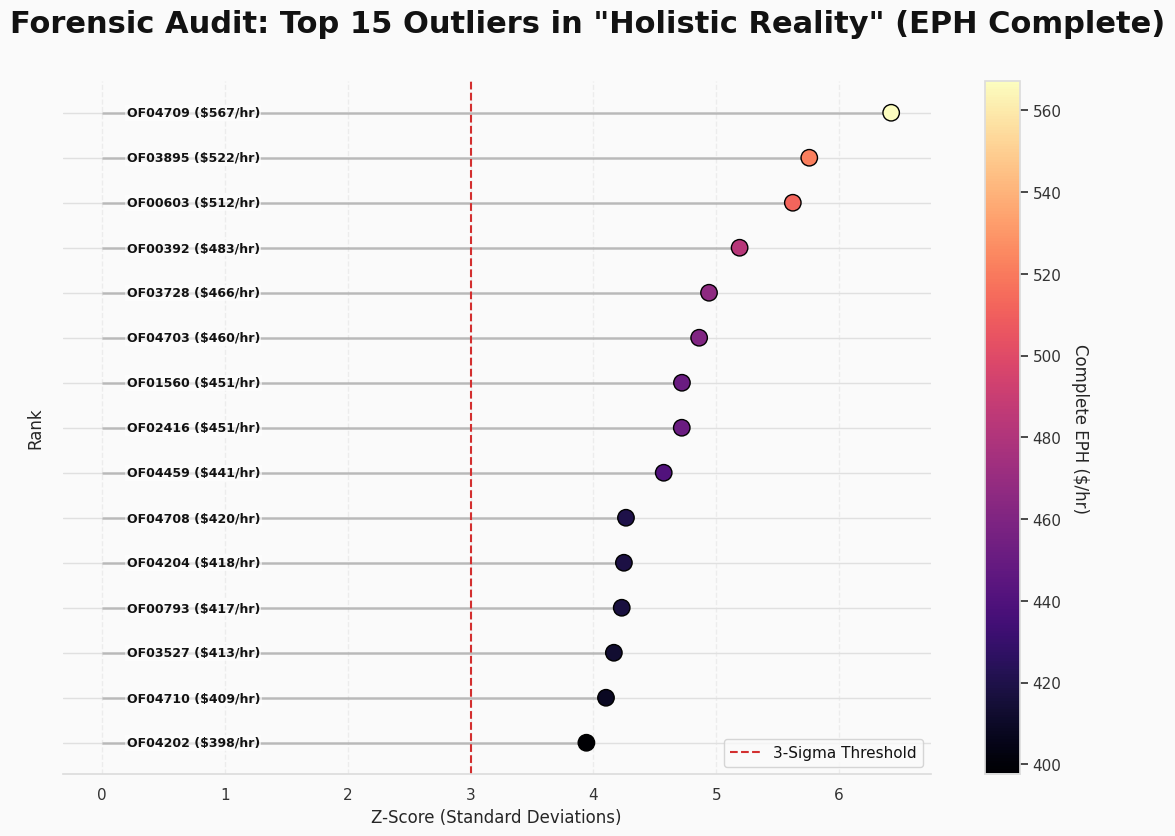


--- 🕵️‍♂️ THE SURVIVORS LIST ---


,offer_id_fk,Z-Score,EPH Complete ($/hr)
14,OF04709,6.42,567.15
13,OF03895,5.76,521.59
12,OF00603,5.62,512.44
11,OF00392,5.19,482.84
10,OF03728,4.94,465.83
9,OF04703,4.86,460.33
8,OF01560,4.72,450.76
7,OF02416,4.72,450.66
6,OF04459,4.57,440.62
5,OF04708,4.27,419.62


In [47]:
# ==============================================================================
# CELL 25: Z-SCORE AUDIT - EPH COMPLETE (THE HOLISTIC SURVIVORS) - CODESPACE READY
# ==============================================================================
# Purpose: To identify outliers in the final, most brutal metric: "Complete EPH".
#          These trips were highly profitable even after accounting for ALL
#          sunk costs (Search Time + Pickup Time).
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# --- OPUS VISUAL CANON ---
OPUS_PURPLE = '#440154'
OPUS_TEAL    = '#21918c'
OPUS_GREY    = '#FAFAFA'
OPUS_TEXT    = '#121212'
OPUS_RED     = '#D32F2F'

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.facecolor': OPUS_GREY,
    'axes.facecolor': OPUS_GREY,
    'text.color': OPUS_TEXT,
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.edgecolor': '#DDDDDD',
    'grid.color': '#E0E0E0',
    'font.family': 'sans-serif',
    'axes.titlecolor': OPUS_PURPLE
})

# 2. LOAD DATA
print("⏳ Auditing 'eph_complete_EDA' anomalies...")
query = """
SELECT
    ef.offer_id_fk,
    ef.eph_complete_EDA
FROM engineered_features ef
WHERE ef.eph_complete_EDA IS NOT NULL
"""
df_audit = pd.read_sql(query, db_engine).dropna()

# 3. CALCULATE Z-SCORES
df_audit['z_score'] = np.abs(stats.zscore(df_audit['eph_complete_EDA']))
top_outliers = df_audit.nlargest(15, 'z_score').sort_values('z_score', ascending=True).reset_index(drop=True)

# 4. PLOTTING (LOLLIPOP - MAGMA FOR INTENSITY)
fig, ax = plt.subplots(figsize=(14, 9))
fig.suptitle('Forensic Audit: Top 15 Outliers in "Holistic Reality" (EPH Complete)', fontsize=22, weight='bold', y=0.96)

# Draw Stems
ax.hlines(y=top_outliers.index, xmin=0, xmax=top_outliers['z_score'], color='gray', alpha=0.4, linewidth=2)

# Draw Heads (Magma for the heat of survival)
sc = ax.scatter(top_outliers['z_score'], top_outliers.index,
                c=top_outliers['eph_complete_EDA'], cmap='magma',
                s=140, edgecolors='black', zorder=3)

# Aesthetics
ax.set_xlabel('Z-Score (Standard Deviations)')
ax.set_ylabel('Rank')
ax.set_yticks(top_outliers.index)
ax.set_yticklabels([])
ax.grid(axis='x', linestyle='--', alpha=0.5)

# Colorbar
cbar = plt.colorbar(sc)
cbar.set_label('Complete EPH ($/hr)', rotation=270, labelpad=20)

# Annotate (Left Side)
for i, row in top_outliers.iterrows():
    label = f"{row['offer_id_fk']} (${row['eph_complete_EDA']:.0f}/hr)"
    ax.text(0.2, i, label, va='center', ha='left', fontsize=9, fontweight='bold', color=OPUS_TEXT,
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.6, pad=1))

# 3-Sigma
ax.axvline(3, color=OPUS_RED, linestyle='--', label='3-Sigma Threshold')
ax.legend(loc='lower right')

sns.despine(left=True, bottom=False)
plt.show()

# 5. FORENSIC TABLE (NO PROOF REQUIRED)
print("\n--- 🕵️‍♂️ THE SURVIVORS LIST ---")
df_table = top_outliers.sort_values('z_score', ascending=False).copy()
df_table['EPH Complete ($/hr)'] = df_table['eph_complete_EDA'].round(2)
df_table['Z-Score'] = df_table['z_score'].round(2)

# CODESPACE READY:
# display() en VS Code permite inspeccionar la tabla con herramientas nativas.
display_cols = ['offer_id_fk', 'Z-Score', 'EPH Complete ($/hr)']
display(df_table[display_cols])

### ⚠️ Nota Metodológica: La Nuance del "Deadhead" (Accumulated vs. Rolling)

**La Deuda Técnica (TD-EDA-009)**
La variable cycle_rolling_avg_deadhead no está aislada como para hacer el proof al reves. Esta variable está calculada dentro del google script que calcula eph_complete_EDA, pero no está aislada como un ouptput en columna de la gsheet. Ergo, para hacer el proof necesitaríamos hacer un nuevo script cuyo output sea esta variable (cycle_rolling_avg_deadhead) que es la que se usó para obtener eph_complete_eda. Para evitar yakshaving, pasa a deuda técninca.  

⏳ Loading efficiency indices...


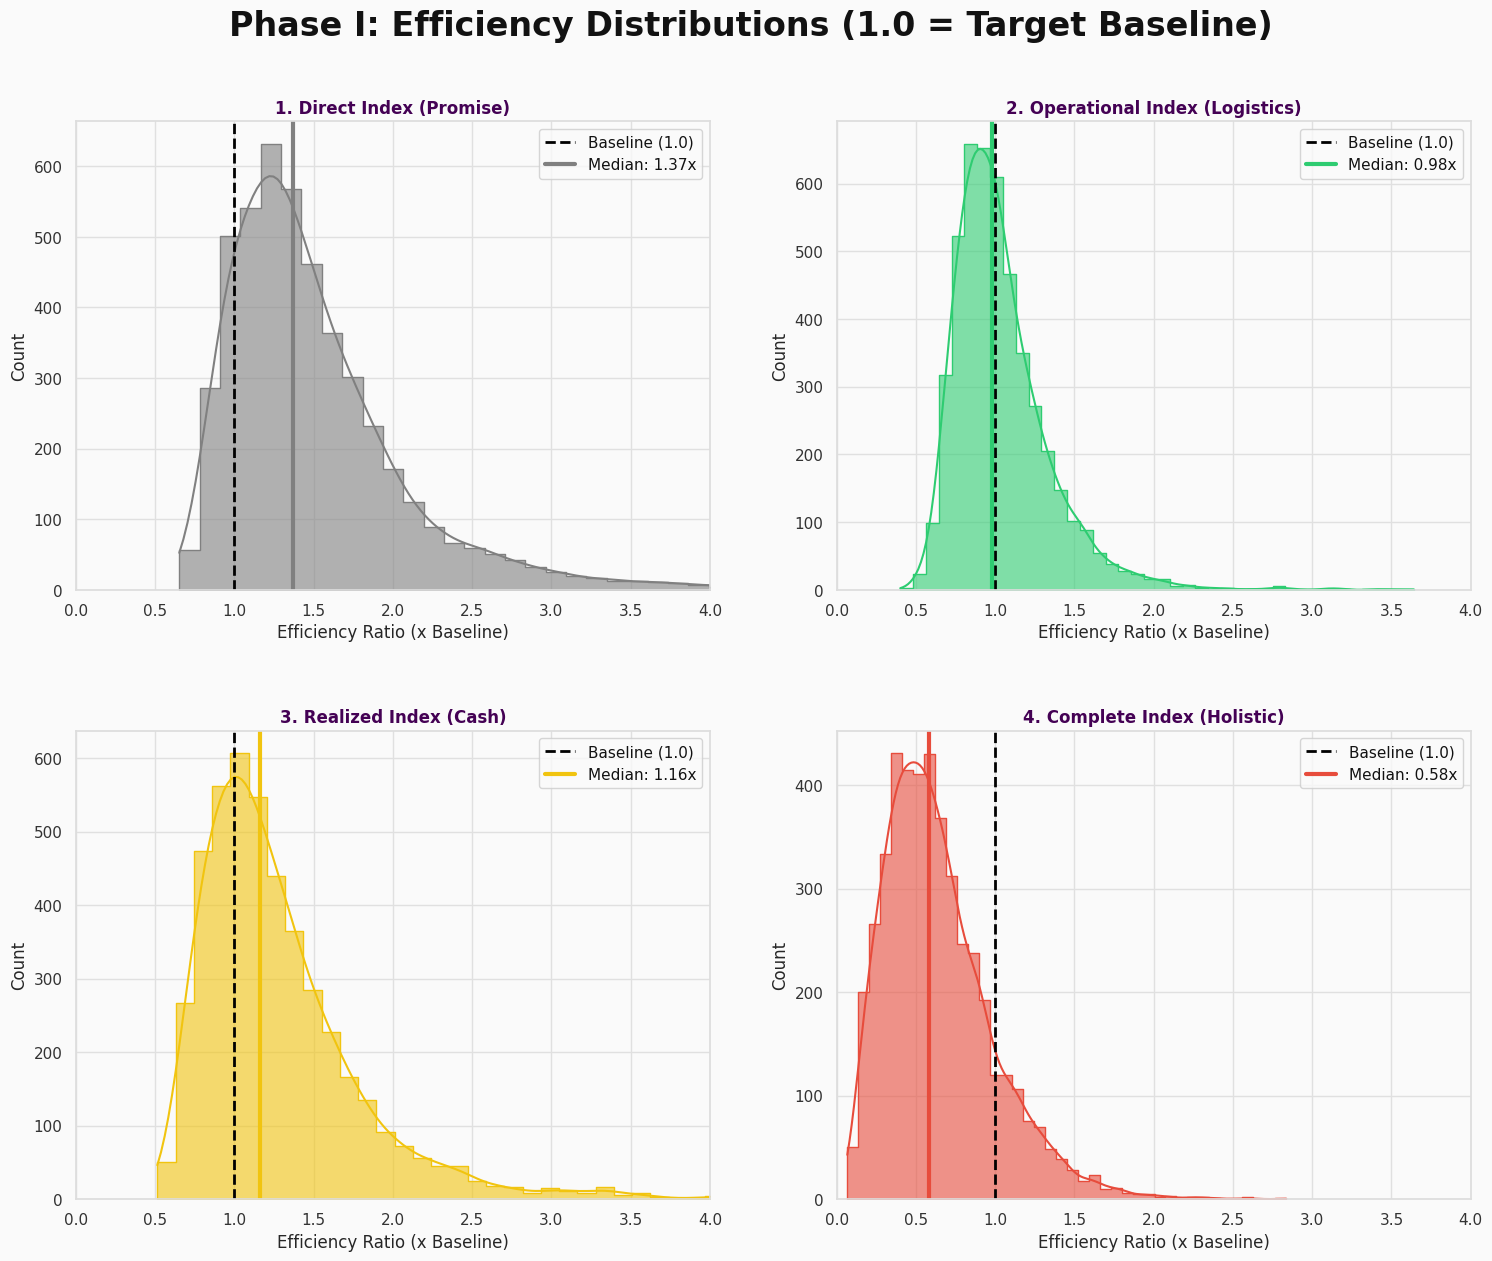

In [48]:
# ==============================================================================
# CELL 26: EPH INDICES DISTRIBUTION (THE EFFICIENCY SCORECARD)
# ==============================================================================
# Purpose: To visualize the distribution of normalized performance indices.
#          1.0 = The Baseline Target ($200/hr).
#          >1.0 = Outperformance (Alpha).
#          <1.0 = Underperformance.
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- OPUS VISUAL CANON ---
OPUS_PURPLE = '#440154'
OPUS_TEAL   = '#21918c'
OPUS_GREY   = '#FAFAFA'
OPUS_TEXT   = '#121212'

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.facecolor': OPUS_GREY,
    'axes.facecolor': OPUS_GREY,
    'text.color': OPUS_TEXT,
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.edgecolor': '#DDDDDD',
    'grid.color': '#E0E0E0',
    'font.family': 'sans-serif',
    'axes.titlecolor': OPUS_PURPLE
})

# 2. LOAD DATA
print("⏳ Loading efficiency indices...")
query = """
SELECT
    eph_direct_index,
    eph_operational_index,
    eph_realized_index_EDA,
    eph_complete_index_EDA
FROM engineered_features
"""
df_idx = pd.read_sql(query, db_engine)

# Filter massive outliers for plot readability (keep Z < 5 range basically)
df_plot = df_idx[df_idx['eph_direct_index'] < 6]

# 3. PLOTTING CONFIGURATION
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
plt.subplots_adjust(hspace=0.3, wspace=0.2)
fig.suptitle('Phase I: Efficiency Distributions (1.0 = Target Baseline)', fontsize=24, weight='bold', y=0.96)

targets = [
    (0, 0, 'eph_direct_index', '1. Direct Index (Promise)', 'gray'),
    (0, 1, 'eph_operational_index', '2. Operational Index (Logistics)', '#2ecc71'),
    (1, 0, 'eph_realized_index_EDA', '3. Realized Index (Cash)', '#f1c40f'),
    (1, 1, 'eph_complete_index_EDA', '4. Complete Index (Holistic)', '#e74c3c')
]

for r, c, col, title, color in targets:
    ax = axes[r, c]

    # Histogram + KDE
    sns.histplot(df_plot[col], kde=True, color=color, bins=40, ax=ax, element="step", alpha=0.6)

    # The Critical "1.0" Line
    ax.axvline(1.0, color='black', linestyle='--', linewidth=2, label='Baseline (1.0)')

    # The Median Line
    med = df_plot[col].median()
    ax.axvline(med, color=color, linestyle='-', linewidth=3, label=f'Median: {med:.2f}x')

    ax.set_title(title, fontweight='bold')
    ax.set_xlabel("Efficiency Ratio (x Baseline)")
    ax.set_xlim(0, 4) # Focus on the core 0x to 4x range
    ax.legend()

plt.show()

⏳ Auditing Index anomalies...


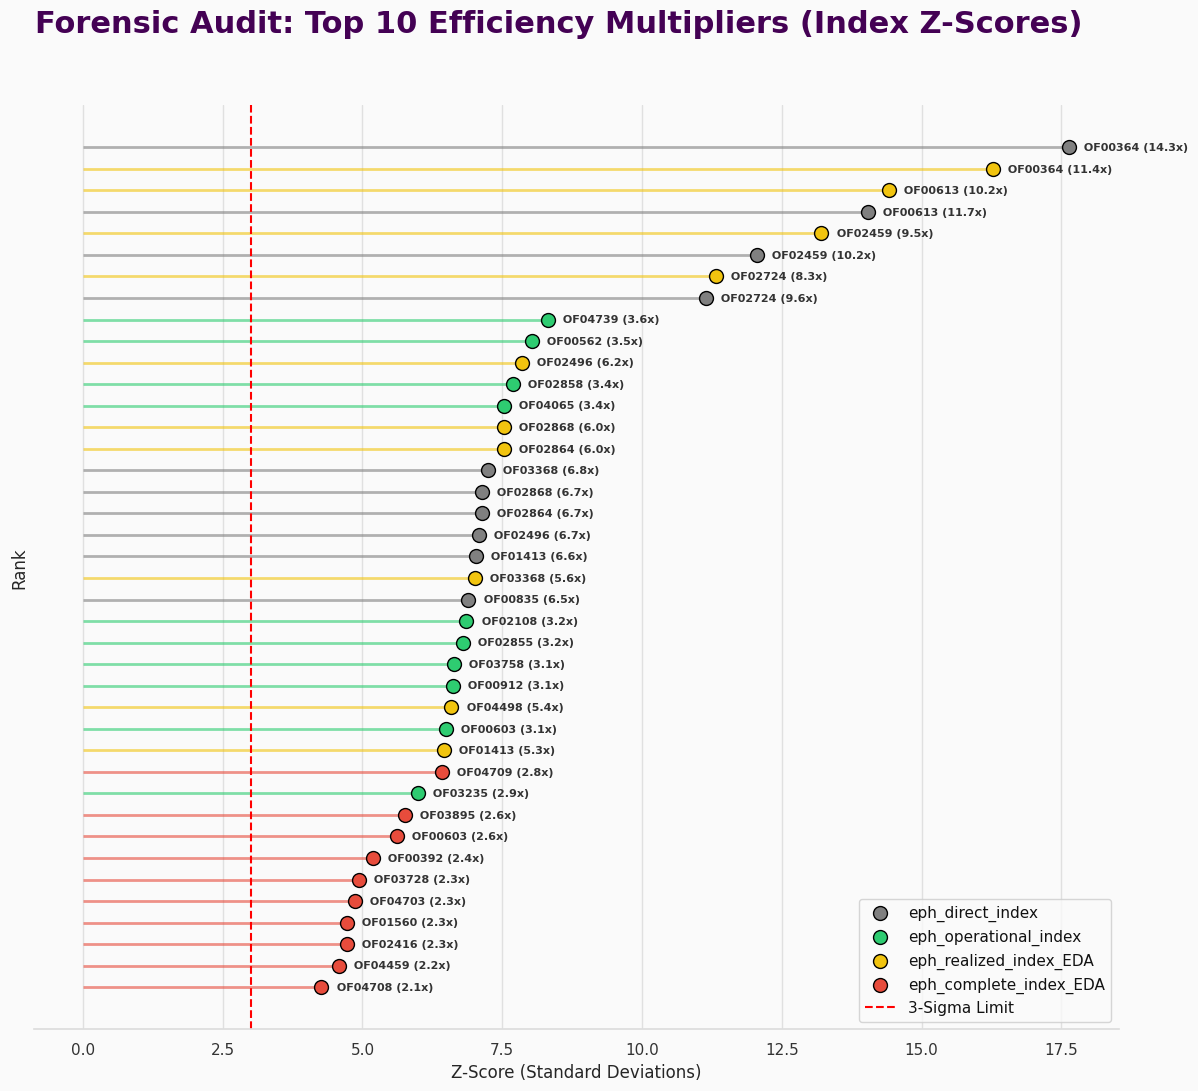


--- 🕵️‍♂️ MATH PROOF: THE MULTIPLIERS ---


,offer_id_fk,Metric,Z-Score,Index (x),Reverse Eng. (Proof)
39,OF00364,eph_direct_index,17.64,14.28,Raw $2857 / $200 Baseline = 14.28x
38,OF00364,eph_realized_index_EDA,16.28,11.38,Raw $2276 / $200 Baseline = 11.38x
37,OF00613,eph_realized_index_EDA,14.42,10.23,Raw $2045 / $200 Baseline = 10.23x
36,OF00613,eph_direct_index,14.05,11.69,Raw $2338 / $200 Baseline = 11.69x
35,OF02459,eph_realized_index_EDA,13.21,9.48,Raw $1895 / $200 Baseline = 9.48x
34,OF02459,eph_direct_index,12.05,10.24,Raw $2049 / $200 Baseline = 10.24x
33,OF02724,eph_realized_index_EDA,11.32,8.31,Raw $1661 / $200 Baseline = 8.31x
32,OF02724,eph_direct_index,11.14,9.59,Raw $1918 / $200 Baseline = 9.59x
31,OF04739,eph_operational_index,8.32,3.64,Raw $728 / $200 Baseline = 3.64x
30,OF00562,eph_operational_index,8.03,3.55,Raw $710 / $200 Baseline = 3.55x


In [50]:
# ==============================================================================
# CELL 27: Z-SCORE AUDIT - EFFICIENCY INDICES (THE MULTIPLIERS) - CODESPACE READY
# ==============================================================================
# Purpose: To identify trips that massively outperformed the baseline.
#          Math Proof: Raw EPH / $200 Baseline = Index.
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. LOAD DATA
print("⏳ Auditing Index anomalies...")
query = """
SELECT
    ef.offer_id_fk,
    ef.eph_direct_index,
    ef.eph_operational_index,
    ef.eph_realized_index_EDA,
    ef.eph_complete_index_EDA,
    ef.eph_complete_EDA -- Need raw value for proof
FROM engineered_features ef
WHERE ef.eph_direct_index IS NOT NULL
"""
df_z = pd.read_sql(query, db_engine).dropna()

# 2. CALCULATE Z-SCORES & EXTRACT TOP 10
targets = ['eph_direct_index', 'eph_operational_index', 'eph_realized_index_EDA', 'eph_complete_index_EDA']
top_outliers = []

for col in targets:
    z_col_name = f"z_{col}"
    df_z[z_col_name] = np.abs(stats.zscore(df_z[col]))

    top_10 = df_z.nlargest(10, z_col_name).copy()
    top_10['Metric'] = col
    top_10['Z_Score'] = top_10[z_col_name]
    top_10['Index_Value'] = top_10[col]

    top_outliers.append(top_10)

df_plot = pd.concat(top_outliers).sort_values('Z_Score', ascending=True).reset_index(drop=True)

# 3. PLOTTING (LOLLIPPOP)
fig, ax = plt.subplots(figsize=(14, 12))
fig.suptitle('Forensic Audit: Top 10 Efficiency Multipliers (Index Z-Scores)', fontsize=22, color='#440154', weight='bold', y=0.96)

colors = {'eph_direct_index': 'gray', 'eph_operational_index': '#2ecc71',
          'eph_realized_index_EDA': '#f1c40f', 'eph_complete_index_EDA': '#e74c3c'}
c_map = df_plot['Metric'].map(colors)

ax.hlines(y=df_plot.index, xmin=0, xmax=df_plot['Z_Score'], color=c_map, alpha=0.6, linewidth=2)

for metric in targets:
    subset = df_plot[df_plot['Metric'] == metric]
    ax.scatter(subset['Z_Score'], subset.index, color=colors[metric], s=100, label=metric, edgecolors='black', zorder=3)

ax.set_xlabel('Z-Score (Standard Deviations)')
ax.set_ylabel('Rank')
ax.set_yticks([])
ax.axvline(3, color='red', linestyle='--', label='3-Sigma Limit')

# Annotate
for i, row in df_plot.iterrows():
    # Label: "OF123 (14.5x)" -> Means 14.5 times the baseline
    label = f" {row['offer_id_fk']} ({row['Index_Value']:.1f}x)"
    ax.text(row['Z_Score'] + 0.2, i, label, va='center', fontsize=8, fontweight='bold', color='#333333')

ax.legend(loc='lower right')
sns.despine(left=True, bottom=False)
plt.show()

# 4. FORENSIC PROOF TABLE
print("\n--- 🕵️‍♂️ MATH PROOF: THE MULTIPLIERS ---")
df_table = df_plot.sort_values('Z_Score', ascending=False).copy()

df_table['Index (x)'] = df_table['Index_Value'].round(2)
df_table['Z-Score'] = df_table['Z_Score'].round(2)

# Prueba matemática simple asumiendo Baseline = 200
df_table['Reverse Eng. (Proof)'] = df_table.apply(
    lambda x: f"Raw ${ (x['Index_Value'] * 200):.0f} / $200 Baseline = {x['Index_Value']:.2f}x",
    axis=1
)

# CODESPACE READY:
# Se eliminó la dependencia de 'google.colab.data_table'.
# Al usar display(), VS Code habilita el visor interactivo automáticamente.
display_cols = ['offer_id_fk', 'Metric', 'Z-Score', 'Index (x)', 'Reverse Eng. (Proof)']
display(df_table[display_cols])

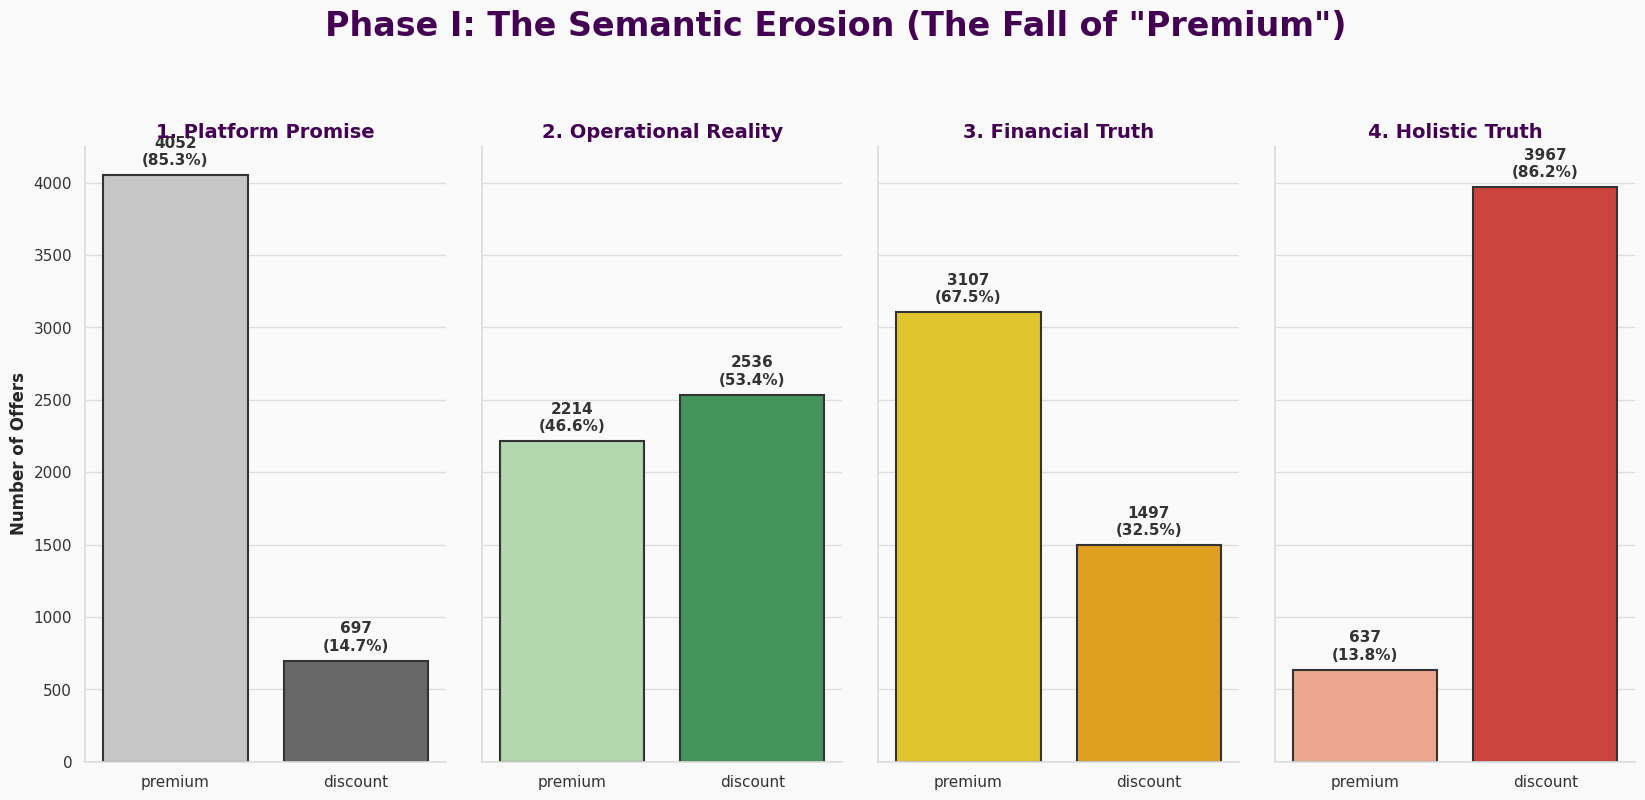

🕊️ Message delivered. Grid syntax corrected.


In [51]:
# ==============================================================================
# CELL 29 (REVISED v3): CATEGORICAL EROSION (VERTICAL, CLEAN & FIXED)
# ==============================================================================
# Purpose: To visualize the "Collapse of Quality".
#          Shows the count of 'Premium' vs 'Discount' offers at each stage.
#          Fixes Matplotlib 'grid_b' deprecation error.
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. APPLY "OPUS LAB" THEME
sns.set_theme(style="whitegrid")
opus_light_params = {
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor': '#FAFAFA',
    'text.color': '#121212',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.edgecolor': '#DDDDDD',
    'grid.color': '#E0E0E0',
    'font.family': 'sans-serif'
}
plt.rcParams.update(opus_light_params)

# 2. LOAD DATA
query = """
SELECT
    eph_direct_label,
    eph_operational_label,
    eph_realized_label_EDA,
    eph_complete_label_EDA
FROM engineered_features
"""
df_cat_eph = pd.read_sql(query, db_engine)

# 3. PLOTTING CONFIGURATION
fig, axes = plt.subplots(1, 4, figsize=(20, 8), sharey=True) # Share Y for comparison
plt.subplots_adjust(wspace=0.1)
fig.suptitle('Phase I: The Semantic Erosion (The Fall of "Premium")', fontsize=24, color='#440154', weight='bold', y=1.05)

# Define the sequence
stages = [
    (0, 'eph_direct_label', '1. Platform Promise', 'Greys'),
    (1, 'eph_operational_label', '2. Operational Reality', 'Greens'),
    (2, 'eph_realized_label_EDA', '3. Financial Truth', 'Wistia'),
    (3, 'eph_complete_label_EDA', '4. Holistic Truth', 'Reds')
]

# 4. EXECUTE LOOP
for idx, col, title, palette in stages:
    ax = axes[idx]

    # Calculate Counts
    counts = df_cat_eph[col].value_counts().reset_index()
    counts.columns = ['Label', 'Count']

    # Filter NaNs explicitly
    counts = counts[counts['Label'].isin(['premium', 'discount'])]

    # Calculate Percentages based on CLEAN total
    total_clean = counts['Count'].sum()
    counts['Percent'] = (counts['Count'] / total_clean) * 100

    # Force Sort: Premium First (Left), Discount Second (Right)
    counts['sort_order'] = counts['Label'].map({'premium': 0, 'discount': 1})
    counts = counts.sort_values('sort_order')

    # Plot Vertical
    sns.barplot(x='Label', y='Count', data=counts, palette=palette, ax=ax, edgecolor='#333333', linewidth=1.5)

    ax.set_title(title, fontweight='bold', fontsize=14)
    ax.set_xlabel('')

    if idx == 0:
        ax.set_ylabel('Number of Offers', fontsize=12, fontweight='bold')
    else:
        ax.set_ylabel('')

    # FIXED: Modern syntax to disable vertical grid lines
    ax.xaxis.grid(False)

    # Annotate (Top of Bar)
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            pct = (height / total_clean) * 100
            ax.text(p.get_x() + p.get_width()/2., height + 50,
                    f"{int(height)}\n({pct:.1f}%)",
                    ha='center', va='bottom', fontsize=11, fontweight='bold', color='#333333')

sns.despine()
plt.show()

# 5. CHER AMI PROTOCOL
print("🕊️ Message delivered. Grid syntax corrected.")

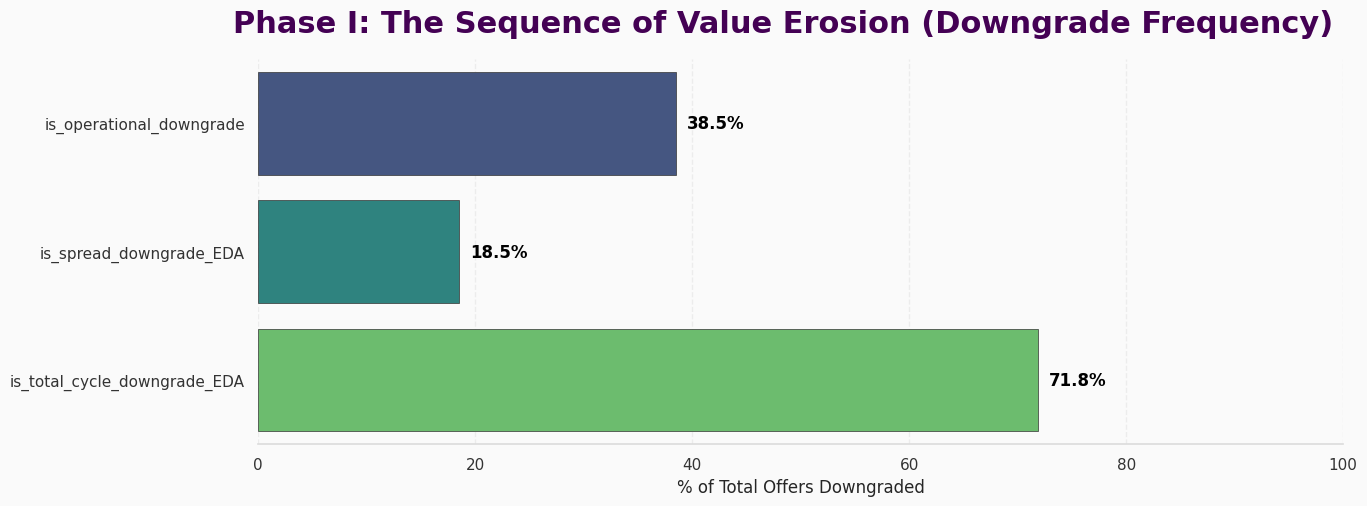

In [52]:
# ==============================================================================
# CELL 30 (FINAL v3): VALUE DILUTION PREVALENCE (LOGICAL ORDER)
# ==============================================================================
# Purpose: Visualization of downgrade frequency ordered by the logical sequence
#          of the offer lifecycle (Operational -> Spread -> Total Cycle).
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. APPLY "OPUS LAB" THEME
sns.set_theme(style="whitegrid")
opus_light_params = {
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor': '#FAFAFA',
    'text.color': '#121212',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.edgecolor': '#DDDDDD',
    'grid.color': '#E0E0E0',
    'font.family': 'sans-serif'
}
plt.rcParams.update(opus_light_params)

# 2. LOAD DATA
query = """
SELECT
    is_operational_downgrade,
    is_spread_downgrade_EDA,
    is_total_cycle_downgrade_EDA
FROM engineered_features
"""
df_flags = pd.read_sql(query, db_engine).dropna()

# 3. CALCULATE PREVALENCE & FORCE LOGICAL ORDER
prevalence = df_flags.mean() * 100
df_plot = prevalence.reset_index()
df_plot.columns = ['Feature', 'Percent']

# Manual Sort Order (The Narrative Arc)
sort_map = {
    'is_operational_downgrade': 1,
    'is_spread_downgrade_EDA': 2,
    'is_total_cycle_downgrade_EDA': 3
}
df_plot['sort_id'] = df_plot['Feature'].map(sort_map)
df_plot = df_plot.sort_values('sort_id', ascending=True)

# 4. PLOTTING
fig, ax = plt.subplots(figsize=(14, 5))
fig.suptitle('Phase I: The Sequence of Value Erosion (Downgrade Frequency)', fontsize=22, color='#440154', weight='bold', y=0.98)

# Bar Plot (Sequential Palette to show accumulation of impact)
sns.barplot(x='Percent', y='Feature', data=df_plot, palette="viridis", ax=ax, edgecolor='#333333', linewidth=0.5)

ax.set_xlabel('% of Total Offers Downgraded')
ax.set_ylabel('')
ax.set_xlim(0, 100)
ax.xaxis.grid(True, linestyle='--', alpha=0.5)

# Annotate
for i, v in enumerate(df_plot['Percent']):
    ax.text(v + 1, i, f"{v:.1f}%", color='black', fontweight='bold', va='center')

sns.despine(left=True, bottom=False)
plt.show()

⏳ Loading vector alignment data...
✅ Vector Analysis (N=4544):
   🏠 Homeward (> 0.5): 2138 (47.1%)
   ↔️ Neutral:         1089 (24.0%)
   🚫 Away (< -0.5):    1317 (29.0%)


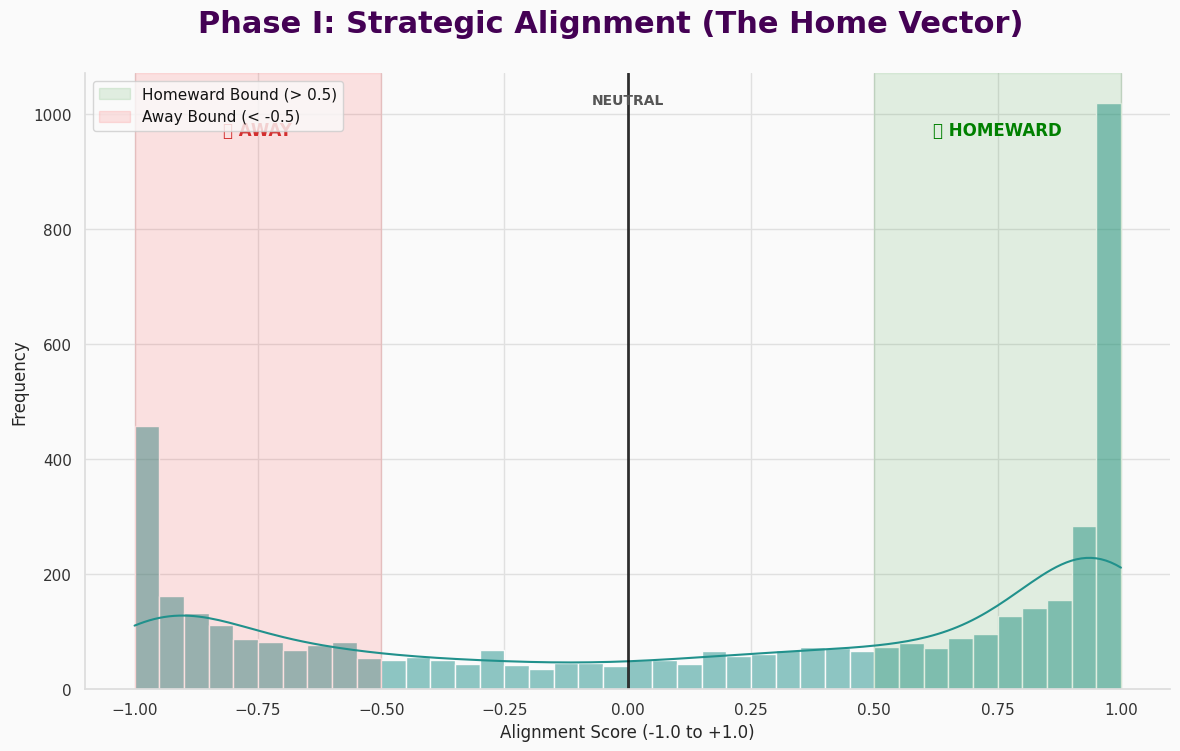

In [53]:
# ==============================================================================
# CELL 31: STRATEGIC ALIGNMENT (THE HOME VECTOR)
# ==============================================================================
# Purpose: To analyze the directional bias of offers relative to the "Home Base".
#          Range: -1.0 (Directly Away) to +1.0 (Directly Home).
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. APPLY "OPUS LAB" THEME
sns.set_theme(style="whitegrid")
opus_light_params = {
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor': '#FAFAFA',
    'text.color': '#121212',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.edgecolor': '#DDDDDD',
    'grid.color': '#E0E0E0',
    'font.family': 'sans-serif'
}
plt.rcParams.update(opus_light_params)

# 2. LOAD DATA
print("⏳ Loading vector alignment data...")
query = """
SELECT home_vector_alignment_score
FROM engineered_features
WHERE home_vector_alignment_score IS NOT NULL
"""
df_vec = pd.read_sql(query, db_engine)

# 3. CALCULATE SEGMENTS
total = len(df_vec)
homeward = len(df_vec[df_vec['home_vector_alignment_score'] > 0.5])
neutral  = len(df_vec[(df_vec['home_vector_alignment_score'] >= -0.5) & (df_vec['home_vector_alignment_score'] <= 0.5)])
away     = len(df_vec[df_vec['home_vector_alignment_score'] < -0.5])

print(f"✅ Vector Analysis (N={total}):")
print(f"   🏠 Homeward (> 0.5): {homeward} ({homeward/total:.1%})")
print(f"   ↔️ Neutral:         {neutral} ({neutral/total:.1%})")
print(f"   🚫 Away (< -0.5):    {away} ({away/total:.1%})")

# 4. PLOTTING
fig, ax = plt.subplots(figsize=(14, 8))
fig.suptitle('Phase I: Strategic Alignment (The Home Vector)', fontsize=22, color='#440154', weight='bold', y=0.96)

# Histogram with KDE
sns.histplot(df_vec['home_vector_alignment_score'], kde=True, bins=40, color="#21918c", ax=ax, edgecolor='#FAFAFA')

# Zoning the Plot
ax.axvline(0, color='black', linestyle='-', linewidth=2, alpha=0.8) # Center
ax.axvspan(0.5, 1.0, color='green', alpha=0.1, label='Homeward Bound (> 0.5)')
ax.axvspan(-1.0, -0.5, color='red', alpha=0.1, label='Away Bound (< -0.5)')

# Annotations
ax.set_xlabel("Alignment Score (-1.0 to +1.0)")
ax.set_ylabel("Frequency")
ax.set_xlim(-1.1, 1.1)

# Add Text Labels for Zones
ax.text(0.75, ax.get_ylim()[1]*0.9, "🏠 HOMEWARD", ha='center', fontweight='bold', color='green', fontsize=12)
ax.text(-0.75, ax.get_ylim()[1]*0.9, "🚫 AWAY", ha='center', fontweight='bold', color='#D32F2F', fontsize=12)
ax.text(0, ax.get_ylim()[1]*0.95, "NEUTRAL", ha='center', fontweight='bold', color='#555555', fontsize=10)

ax.legend(loc='upper left')
sns.despine()
plt.show()

⏳ Loading context & quality flags...


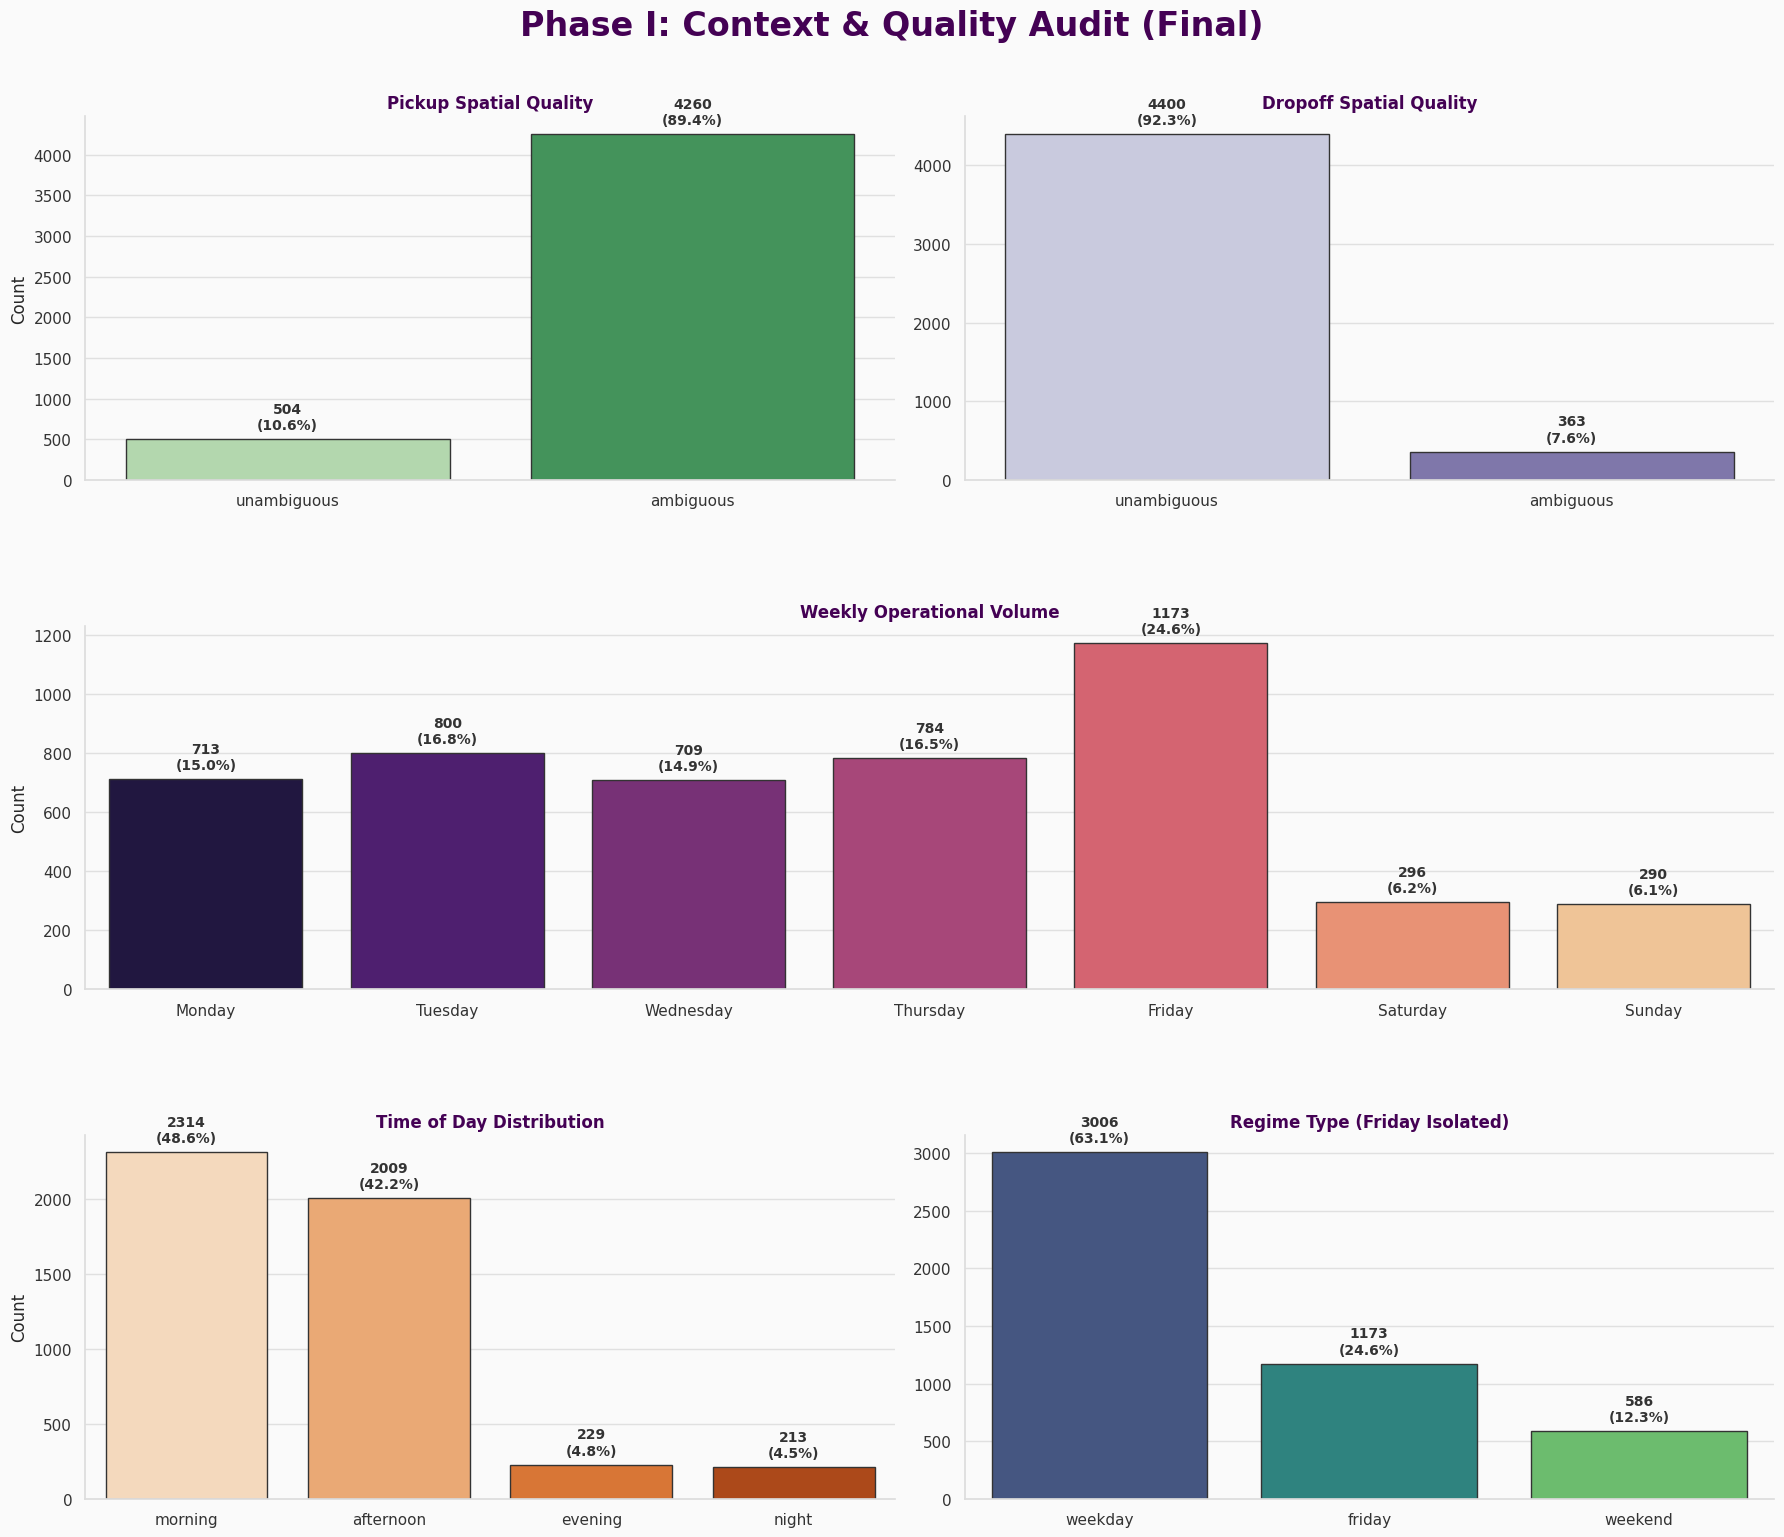

In [54]:
# ==============================================================================
# CELL 32 (FINAL): DATA QUALITY & TEMPORAL CONTEXT (THE LAST MILE)
# ==============================================================================
# Purpose: 1. Audit geospatial ambiguity (Purity Sieve results).
#          2. Visualize aggregated temporal habits (including the "Friday" regime).
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. APPLY "OPUS LAB" THEME
sns.set_theme(style="whitegrid")
opus_light_params = {
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor': '#FAFAFA',
    'text.color': '#121212',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.edgecolor': '#DDDDDD',
    'grid.color': '#E0E0E0',
    'font.family': 'sans-serif'
}
plt.rcParams.update(opus_light_params)

# 2. LOAD DATA
print("⏳ Loading context & quality flags...")
query = """
SELECT
    pickup_ambiguity,
    dropoff_ambiguity,
    day_of_week,
    time_of_day_block,
    day_type
FROM engineered_features
"""
df_ctx = pd.read_sql(query, db_engine)

# 3. DEFINE LOGICAL ORDERS (Based on your schema)
ambiguity_order = ['unambiguous', 'ambiguous'] # Ideal first
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
time_order = ['morning', 'afternoon', 'evening', 'night'] # Chronological
dtype_order = ['weekday', 'friday', 'weekend'] # Increasing entropy

# 4. PLOTTING CONFIGURATION
fig = plt.figure(figsize=(18, 16))
gs = fig.add_gridspec(3, 2)
fig.suptitle('Phase I: Context & Quality Audit (Final)', fontsize=24, color='#440154', weight='bold', y=0.96)

# --- ROW 1: DATA QUALITY (Ambiguity) ---
# Plot A: Pickup
ax1 = fig.add_subplot(gs[0, 0])
sns.countplot(x='pickup_ambiguity', data=df_ctx, order=ambiguity_order, palette="Greens", ax=ax1, edgecolor='#333333')
ax1.set_title("Pickup Spatial Quality", fontweight='bold')
ax1.set_xlabel('')
ax1.set_ylabel('Count')

# Plot B: Dropoff
ax2 = fig.add_subplot(gs[0, 1])
sns.countplot(x='dropoff_ambiguity', data=df_ctx, order=ambiguity_order, palette="Purples", ax=ax2, edgecolor='#333333')
ax2.set_title("Dropoff Spatial Quality", fontweight='bold')
ax2.set_xlabel('')
ax2.set_ylabel('')

# --- ROW 2: WEEKLY RHYTHM (Full Width) ---
ax3 = fig.add_subplot(gs[1, :])
sns.countplot(x='day_of_week', data=df_ctx, order=day_order, palette="magma", ax=ax3, edgecolor='#333333')
ax3.set_title("Weekly Operational Volume", fontweight='bold')
ax3.set_xlabel('')
ax3.set_ylabel('Count')

# --- ROW 3: OPERATIONAL REGIMES ---
# Plot D: Time Blocks
ax4 = fig.add_subplot(gs[2, 0])
sns.countplot(x='time_of_day_block', data=df_ctx, order=time_order, palette="Oranges", ax=ax4, edgecolor='#333333')
ax4.set_title("Time of Day Distribution", fontweight='bold')
ax4.set_xlabel('')
ax4.set_ylabel('Count')

# Plot E: Day Type (The Friday Factor)
ax5 = fig.add_subplot(gs[2, 1])
sns.countplot(x='day_type', data=df_ctx, order=dtype_order, palette="viridis", ax=ax5, edgecolor='#333333')
ax5.set_title("Regime Type (Friday Isolated)", fontweight='bold')
ax5.set_xlabel('')
ax5.set_ylabel('')

# GLOBAL ANNOTATION LOOP
axes_list = [ax1, ax2, ax3, ax4, ax5]
for ax in axes_list:
    total = len(df_ctx)
    for p in ax.patches:
        percentage = '{:.1f}%'.format(100 * p.get_height() / total)
        height = int(p.get_height())
        if height > 0:
            ax.annotate(f'{height}\n({percentage})', (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='bottom', xytext=(0, 5), textcoords='offset points',
                        fontweight='bold', fontsize=10, color='#333333')
    sns.despine(ax=ax)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.subplots_adjust(hspace=0.4)
plt.show()

⏳ Aggregating offers per session...
✅ Analyzed volume for 63 valid sessions.


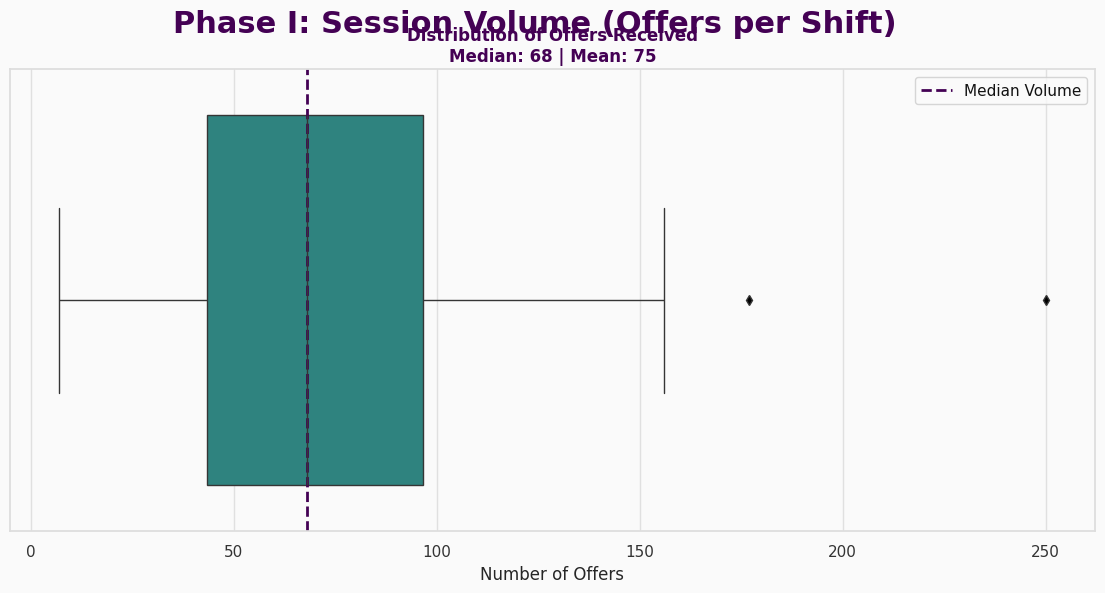


--- 📊 THE STANDARD SHIFT ---


,count,min,25%,50%,75%,90%,max,mean
offer_count,63.0,7.0,43.5,68.0,96.5,118.8,250.0,75.634921


In [56]:
# ==============================================================================
# CELL SPECIAL: SESSION VOLUME DISTRIBUTION (THE "N" PER SHIFT) - CODESPACE READY
# ==============================================================================
# Purpose: To establish the baseline volume of a work session.
#          Answers: "How many offers do I typically analyze per shift?"
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. APPLY "OPUS LAB" THEME
sns.set_theme(style="whitegrid")
# Asumimos que opus_light_params ya vive en tu entorno
plt.rcParams.update(opus_light_params)

# 2. DATA ENGINEERING
print("⏳ Aggregating offers per session...")
query = """
SELECT session_fk, COUNT(*) as offer_count
FROM offers
GROUP BY session_fk
"""
df_vol = pd.read_sql(query, db_engine)

# Filtramos sesiones de prueba (< 5 ofertas) para ver el trabajo real
df_vol = df_vol[df_vol['offer_count'] > 5]

print(f"✅ Analyzed volume for {len(df_vol)} valid sessions.")

# 3. PLOTTING
fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle('Phase I: Session Volume (Offers per Shift)', fontsize=22, color='#440154', weight='bold', y=0.98)

# Boxplot
sns.boxplot(x=df_vol['offer_count'], ax=ax, color='#21918c',
            flierprops={"marker": "d", "markerfacecolor": "black", "markersize": 5})

# Stats for Title
med = df_vol['offer_count'].median()
mean_val = df_vol['offer_count'].mean()

ax.set_title(f"Distribution of Offers Received\nMedian: {int(med)} | Mean: {int(mean_val)}", fontweight='bold')
ax.set_xlabel("Number of Offers")

# Annotate Median Line
ax.axvline(med, color='#440154', linestyle='--', linewidth=2, label='Median Volume')
ax.legend()

plt.show()

# 4. REFERENCE TABLE (MEMORIZE THIS)
print("\n--- 📊 THE STANDARD SHIFT ---")
stats = df_vol['offer_count'].describe(percentiles=[0.25, 0.5, 0.75, 0.90]).to_frame().T
stats = stats[['count', 'min', '25%', '50%', '75%', '90%', 'max', 'mean']]

# CODESPACE READY:
# display() en VS Code permite inspeccionar la tabla con herramientas nativas.
display(stats)